# 01a — Chợ Tốt: Data Inspection

> Notebook này thực hiện kiểm tra toàn diện dataset Chợ Tốt ở trạng thái raw.  
> Mục tiêu **không phải** là làm sạch dữ liệu mà là **hiểu rõ bản chất, chất lượng và các vấn đề tiềm ẩn** để làm cơ sở cho `02a_chotot_cleaning.ipynb`.

**Nguồn:** `data/raw/chotot_laptop_data.csv`  
**Kích thước raw:** 5,866 rows × 15 columns  
**Đặc điểm nổi bật:** Tất cả cột đều là `object` — dữ liệu do người bán tự điền, không có schema chuẩn.

## Table of Contents

1. [Setup & Load](#1-setup--load)
2. [Shape & Schema](#2-shape--schema)
3. [Duplicate Inspection](#3-duplicate-inspection)
4. [Missing Value Analysis](#4-missing-value-analysis)
5. [Column: `price`](#5-column-price)
6. [Column: `title`](#6-column-title)
7. [Column: `Hãng`](#7-column-hãng)
8. [Column: `Dòng máy`](#8-column-dòng-máy)
9. [Column: `Tình trạng`](#9-column-tình-trạng)
10. [Column: `Chính sách bảo hành`](#10-column-chính-sách-bảo-hành)
11. [Column: `Kích cỡ màn hình`](#11-column-kích-cỡ-màn-hình)
12. [Column: `Bộ vi xử lý`](#12-column-bộ-vi-xử-lý)
13. [Column: `RAM`](#13-column-ram)
14. [Column: `Card màn hình`](#14-column-card-màn-hình)
15. [Column: `Ổ cứng` & `Loại ổ cứng`](#15-column-ổ-cứng--loại-ổ-cứng)
16. [Column: `Xuất xứ` & `Thông tin sử dụng`](#16-column-xuất-xứ--thông-tin-sử-dụng)
17. [Cross-column Consistency](#17-cross-column-consistency)
18. [Issues Summary](#18-issues-summary)


## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
ACCENT = "#4C72B0"
COLORS = sns.color_palette("muted", 10)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

PATH = r"../../data/raw/chotot_laptop_data.csv"
df = pd.read_csv(PATH)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: 5,866 rows × 15 columns


In [2]:
# ── Shared helpers — dùng xuyên suốt notebook ─────────────────────────────────
def parse_price(series):
    """Parse price string → int (VNĐ). Returns NaN nếu không parse được."""
    return pd.to_numeric(series.str.replace(r'[^\d]', '', regex=True), errors='coerce')

def parse_storage_gb(val):
    """Convert storage string (256 GB / 1 TB) → float GB."""
    if pd.isna(val): return np.nan
    v = str(val).upper()
    if 'TB' in v:
        nums = re.findall(r'[\d\.]+', v)
        return float(nums[0]) * 1024 if nums else np.nan
    nums = re.findall(r'[\d\.]+', v)
    return float(nums[0]) if nums else np.nan

# _price tồn tại xuyên suốt notebook — chỉ drop một lần ở cuối cell cuối cùng
df['_price'] = parse_price(df['price'])
print(f"_price ready: {df['_price'].notna().sum():,} valid rows")

_price ready: 5,865 valid rows


Chỉ có 1 dòng mang giá trị NaN, ta kiểm tra dòng đó

In [3]:
row = df[df['_price'].isna()].iloc[0]
print(row)

url                    https://www.chotot.com/mua-ban-quan-long-bien-ha-noi/131924823.htm
price                                                                                 NaN
title                                             TẶNG MIẾNG VÀNG 24K CHO NGƯỜI HỮU DUYÊN
Hãng                                                                                 Dell
Dòng máy                                                                      Inspiron 15
Tình trạng                                                     Đã sử dụng (chưa sửa chữa)
Chính sách bảo hành                                                         Bảo hành hãng
Kích cỡ màn hình                                                                      NaN
Bộ vi xử lý                                                                           NaN
RAM                                                                                   NaN
Card màn hình                                                                         NaN
Ổ cứng    

Quá nhiều giá trị NaN cho một dòng dữ liệu, cột còn lại cũng không cho thấy dấu hiệu có thẻ được khai thác thêm. Ta loại dòng này.

## 2. Shape & Schema

In [4]:
print("=== dtypes ===")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== dtypes ===
url                     object
price                   object
title                   object
Hãng                    object
Dòng máy                object
Tình trạng              object
Chính sách bảo hành     object
Kích cỡ màn hình        object
Bộ vi xử lý             object
RAM                     object
Card màn hình           object
Ổ cứng                  object
Xuất xứ                 object
Loại ổ cứng             object
Thông tin sử dụng       object
_price                 float64
dtype: object

Memory usage: 6.33 MB


## Data Types Overview

Quan sát ban đầu cho thấy hầu hết các cột trong dataset có kiểu dữ liệu `object`, ngoại trừ biến mục tiêu `_price` đã được chuyển đổi thành `float`. Tuy nhiên, kiểu `object` ở đây không đồng nhất về mặt ngữ nghĩa mà bao gồm nhiều dạng dữ liệu khác nhau:

- **Categorical features**: `Hãng`, `Dòng máy`, `Tình trạng`, `Xuất xứ`
- **Semi-structured text**: `RAM`, `Ổ cứng`, `Bộ vi xử lý`, `Card màn hình`
- **Free-text fields**: `title`, `Thông tin sử dụng`

Điều này cho thấy cần áp dụng các chiến lược tiền xử lý khác nhau thay vì xử lý đồng nhất toàn bộ các cột `object`.

---

## Identifier Column

Cột `url` đóng vai trò là **unique identifier** cho mỗi mẫu dữ liệu. Cột này không mang ý nghĩa dự đoán (**no predictive value**) và sẽ được loại bỏ khỏi tập feature khi huấn luyện mô hình, nhưng có thể giữ lại để **traceability** khi cần đối chiếu.

---

## Feature Characteristics

### 1. Hardware-related features (quan trọng nhất)

Các cột như:
- `RAM`
- `Ổ cứng`
- `Bộ vi xử lý`
- `Card màn hình`

hiện đang ở dạng chuỗi nhưng thực chất chứa thông tin định lượng. Ví dụ:

- `"8 GB DDR4"`
- `"512GB SSD"`
- `"Intel Core i5-1135G7"`

Các cột này cần được **feature engineering** để chuyển về dạng số:
- RAM → GB
- Storage → GB
- CPU → generation / series

---

### 2. Categorical features

Một số cột có dạng phân loại rõ ràng:
- `Hãng` → low cardinality
- `Dòng máy` → high cardinality

---

### 3. Free-text features

Các cột:
- `title`
- `Thông tin sử dụng`

thuộc dạng **unstructured text**. Có một số hướng ta có thể xử lý:
- Loại bỏ trong baseline model
- Cố gắn trích xuất thêm đặt trưng nếu chúng tuân theo 1 pattern với mọi dòng ta thấy được và có giá trị
- Hoặc áp dụng **basic NLP techniques** (optional)

In [5]:
df.head(5)

,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng,_price
0,https://www.chotot.com/mua-ban-quan-tan-binh-tp-ho-chi-minh/121607693.htm,9.990.000 đ,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Dell,Latitude,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core i7,16 GB,Onboard,256 GB,Mỹ,SSD,In trên bao bì,9990000.0
1,https://www.chotot.com/mua-ban-thanh-pho-thu-dau-mot-binh-duong/130109389.htm,4.500.000 đ,Acer Aspire A315-58 i3-1115G4,Acer,Aspire A3,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i3,8 GB,Onboard,< 128 GB,Đang cập nhật,SSD,In trên bao bì,4500000.0
2,https://www.chotot.com/mua-ban-quan-ha-dong-ha-noi/132012438.htm,3.500.000 đ,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,HP,Elite X2,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,11 - 12.9 inch,Intel Core i7,8 GB,Onboard,512 GB,Đang cập nhật,SSD,In trên bao bì,3500000.0
3,https://www.chotot.com/mua-ban-quan-7-tp-ho-chi-minh/131544483.htm,37.500.000 đ,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB,Dell,Pro Rugged 14,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core Ultra,32 GB,Onboard,512 GB,Mỹ,SSD,In trên bao bì,37500000.0
4,https://www.chotot.com/mua-ban-quan-12-tp-ho-chi-minh/122814284.htm,7.990.000 đ,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ,HP,Spectre,Đã sử dụng (chưa sửa chữa),3 tháng,13 - 14.9 inch,NaN,16 GB,Onboard,256 GB,Đang cập nhật,SSD,In trên bao bì,7990000.0


In [6]:
df.tail(3)

,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng,_price
5863,https://www.chotot.com/mua-ban-quan-binh-tan-tp-ho-chi-minh/131907078.htm,26.500.000 đ,Dell XPS 15 9530 i7-13700H 16GB/1TB RTX 4050,Dell,XPS 15,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i7,16 GB,NVIDIA,1 TB,Đang cập nhật,SSD,In trên bao bì,26500000.0
5864,https://www.chotot.com/mua-ban-thanh-pho-phan-thiet-binh-thuan/131985064.htm,8.800.000 đ,Dell Latitude 5511 I7-10850H 15.6 inch,Dell,Dòng Khác,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i7,16 GB,NVIDIA,256 GB,Đang cập nhật,SSD,In trên bao bì,8800000.0
5865,https://www.chotot.com/mua-ban-quan-tan-phu-tp-ho-chi-minh/132070964.htm,3.000.000 đ,Panasonic RZ6 i5 4GB 128gb Bạc,Panasonic,Dòng Khác,Đã sử dụng (chưa sửa chữa),Hết bảo hành,9 - 10.9 inch,Intel Core i5,4 GB,NaN,NaN,Nhật Bản,SSD,In trên bao bì,3000000.0


## 3. Duplicate Inspection

Chợ Tốt là marketplace — cùng một người bán có thể đăng lại nhiều lần, hoặc cùng một listing bị crawl trùng.  
Kiểm tra 3 mức độ: duplicate theo `url`, theo nội dung (`title+price+Hãng`), và toàn bộ cột.


In [7]:
dup_url     = df.duplicated(subset='url', keep=False)
dup_content = df.duplicated(subset=['title', 'price', 'Hãng'], keep=False)
dup_full    = df.duplicated(keep=False)

summary = pd.DataFrame({
    'Loại duplicate': ['Theo URL (crawl trùng)', 'Theo title+price+Hãng', 'Toàn bộ cột giống nhau'],
    'Số dòng': [dup_url.sum(), dup_content.sum(), dup_full.sum()],
    'Tỷ lệ (%)': [f"{v/len(df)*100:.2f}%" for v in [dup_url.sum(), dup_content.sum(), dup_full.sum()]]
})
display(summary)

,Loại duplicate,Số dòng,Tỷ lệ (%)
0,Theo URL (crawl trùng),0,0.00%
1,Theo title+price+Hãng,42,0.72%
2,Toàn bộ cột giống nhau,0,0.00%


### Duplicate Analysis

Kết quả kiểm tra cho thấy không có bản ghi nào bị trùng theo `url`, điều này cho thấy quá trình crawl dữ liệu hoạt động ổn định và không tạo ra duplicate ở mức hệ thống.

Ngoài ra, việc không tồn tại các dòng trùng hoàn toàn trên toàn bộ cột cũng là hợp lý, do dữ liệu được thu thập từ một marketplace — nơi mỗi listing thường có một số khác biệt nhất định (mô tả, tình trạng, cấu hình, v.v.).

Tuy nhiên, khi kiểm tra theo tổ hợp `title + price + Hãng`, phát hiện khoảng **0.72%** các bản ghi có khả năng trùng lặp về nội dung. Mặc dù tỷ lệ này tương đối nhỏ, nhưng vẫn phản ánh đặc trưng của dữ liệu marketplace, nơi người bán có thể đăng lại sản phẩm tương tự hoặc nhiều người bán đăng cùng một loại sản phẩm.

Điều này cho thấy duplicate trong dataset chủ yếu là **semantic duplicate** thay vì **exact duplicate**.

In [8]:
if dup_url.sum() > 0:
    print("\n=== Sample duplicate URL ===")
    display(df[dup_url].sort_values('url')[['url', 'title', 'price', 'Hãng']].head(6))

In [9]:
if dup_content.sum() > 0:
    print("\n=== Sample duplicate content ===")
    display(df[dup_content].sort_values('title')[['title', 'price', 'Hãng', 'url']].head(6))


=== Sample duplicate content ===


,title,price,Hãng,url
3959,ASUS ROG Zephyrus G14 Ryzen 9 16GB/512GB,28.890.000 đ,Asus,https://www.chotot.com/mua-ban-thanh-pho-thu-duc-tp-ho-chi-minh/131997692.htm
818,ASUS ROG Zephyrus G14 Ryzen 9 16GB/512GB,28.890.000 đ,Asus,https://www.chotot.com/mua-ban-quan-binh-thanh-tp-ho-chi-minh/132002417.htm
2497,ASUS TUF Dash F15 i5-11300H 15.6 inch 8GB/512GB,11.500.000 đ,Asus,https://www.chotot.com/mua-ban-thanh-pho-bien-hoa-dong-nai/132036284.htm
624,ASUS TUF Dash F15 i5-11300H 15.6 inch 8GB/512GB,11.500.000 đ,Asus,https://www.chotot.com/mua-ban-thanh-pho-bien-hoa-dong-nai/132035362.htm
964,Apple MacBook Pro i5 13.3 inch 8GB/256GB,6.500.000 đ,Apple,https://www.chotot.com/mua-ban-quan-cam-le-da-nang/131959125.htm
871,Apple MacBook Pro i5 13.3 inch 8GB/256GB,6.500.000 đ,Apple,https://www.chotot.com/mua-ban-quan-hoang-mai-ha-noi/132048063.htm


## 4. Missing Value Analysis

Phân tích missing ở hai tầng:
1. **Tổng quan** — bao nhiêu missing, cột nào nặng nhất
2. **Pattern** — các cột có missing cùng nhau không (MNAR vs MAR)?


In [10]:
miss    = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = (pd.DataFrame({'Missing': miss, 'Missing %': miss_pct})
           .sort_values('Missing', ascending=False)
           .query('Missing > 0'))
display(miss_df)

,Missing,Missing %
Card màn hình,1421,24.22
Kích cỡ màn hình,1037,17.68
Loại ổ cứng,726,12.38
Ổ cứng,470,8.01
Bộ vi xử lý,249,4.24
RAM,239,4.07
_price,1,0.02
price,1,0.02


### Missing Values Analysis

Kết quả kiểm tra cho thấy một số cột có tỷ lệ thiếu dữ liệu đáng kể, đặc biệt tập trung ở các thuộc tính liên quan đến cấu hình phần cứng.

Cụ thể:

- `Card màn hình`: 24.22%
- `Kích cỡ màn hình`: 17.68%
- `Loại ổ cứng`: 12.38%
- `Ổ cứng`: 8.01%
- `Bộ vi xử lý`: 4.24%
- `RAM`: 4.07%

Trong khi đó, biến mục tiêu `_price` gần như không bị thiếu (chỉ 0.02% mà ta đã quyết định loại nó đi ở phần đầu), do đó không ảnh hưởng đến quá trình huấn luyện.

---

### Observations

- Các cột có tỷ lệ missing cao chủ yếu là **hardware-related features**, cho thấy dữ liệu từ marketplace thường không đầy đủ hoặc người bán không cung cấp toàn bộ thông tin kỹ thuật.
- Mức thiếu dữ liệu không đồng đều giữa các cột (**non-uniform missingness**), do đó không thể áp dụng một chiến lược xử lý duy nhất cho toàn bộ dataset.

---

### Handling Strategy

Dựa trên tỷ lệ thiếu, có thể chia thành các nhóm:

- **High missing (>15%)**:
  `Card màn hình`, `Kích cỡ màn hình`
  → Cân nhắc:
  - giữ lại và gán giá trị `"Unknown"` (categorical imputation)
  - hoặc loại bỏ nếu không đóng vai trò quan trọng

- **Medium missing (5–15%)**:
  `Loại ổ cứng`, `Ổ cứng`
  → Có thể:
  - suy luận từ các cột liên quan (feature inference)
  - hoặc impute giá trị phổ biến

- **Low missing (<5%)**:
  `Bộ vi xử lý`, `RAM`
  → Có thể:
  - giữ lại và impute (mode hoặc forward logic)

---

### Conclusion

Missing values trong dataset phản ánh đúng đặc trưng của dữ liệu marketplace (thiếu thông tin không đồng nhất). Do đó, cần áp dụng **feature-specific imputation strategies** thay vì xử lý đồng loạt.

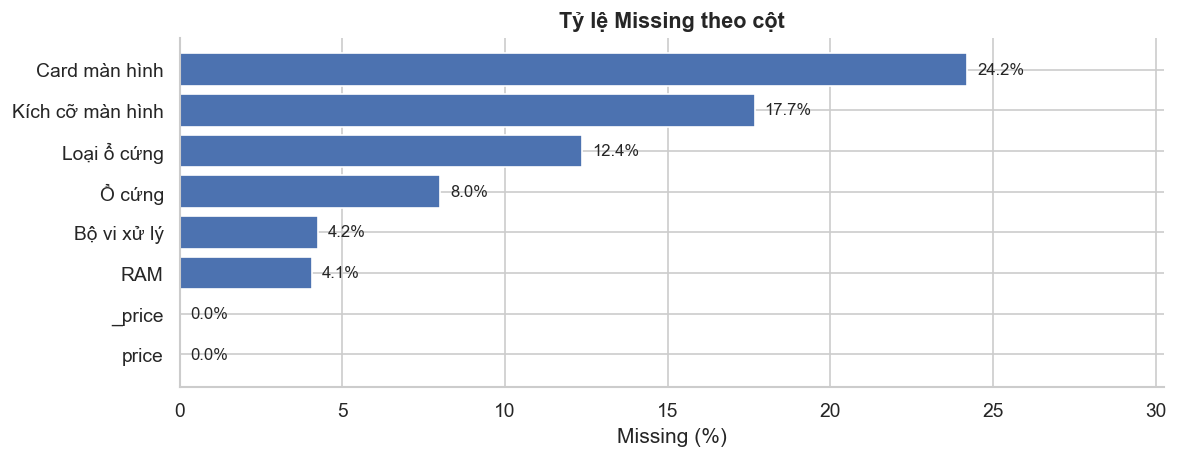

In [11]:
# ── Bar chart missing % ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
cols  = miss_df.index.tolist()
vals  = miss_df['Missing %'].values
bars  = ax.barh(cols[::-1], vals[::-1], color=ACCENT, edgecolor='white')

for bar, v in zip(bars, vals[::-1]):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}%", va='center', fontsize=10)

ax.set_xlabel("Missing (%)")
ax.set_title("Tỷ lệ Missing theo cột")
ax.set_xlim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()


<Axes: >

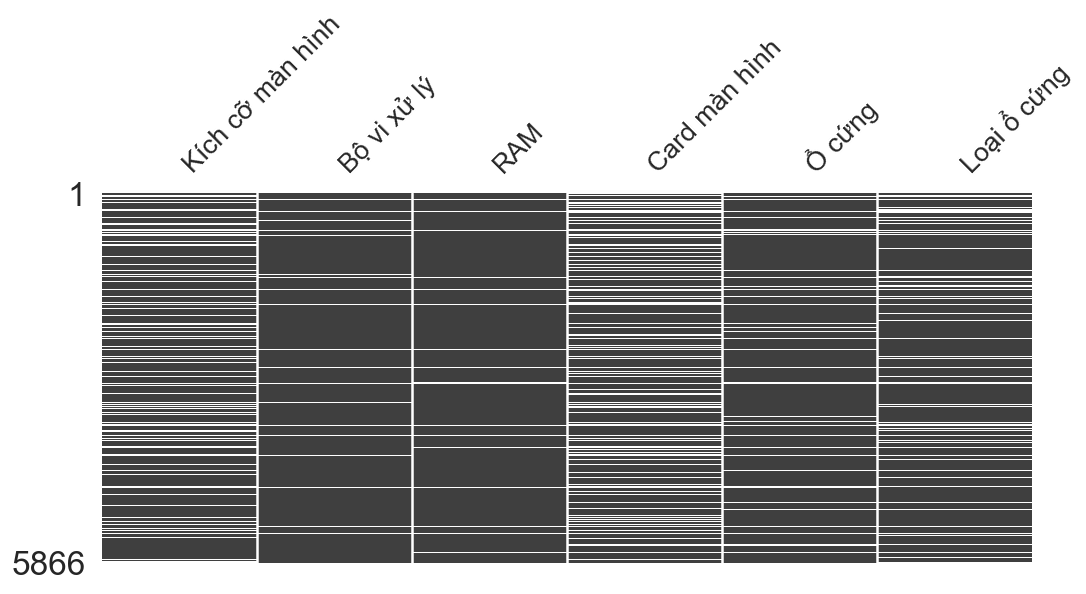

In [12]:
# ── Missing cùng lúc nhiều cột spec ───────────────────────────────────────────
spec_cols = ['Kích cỡ màn hình', 'Bộ vi xử lý', 'RAM',
             'Card màn hình', 'Ổ cứng', 'Loại ổ cứng']
msno.matrix(df[spec_cols], figsize=(10, 4), sparkline=False)

Biểu đồ cho thấy missing values phân bố không đồng đều giữa các cột và các bản ghi (**non-random missingness**). Các thuộc tính phần cứng như `Card màn hình`, `Kích cỡ màn hình`, và `Ổ cứng` thường thiếu cùng nhau, cho thấy người bán có xu hướng không cung cấp đầy đủ thông tin kỹ thuật.

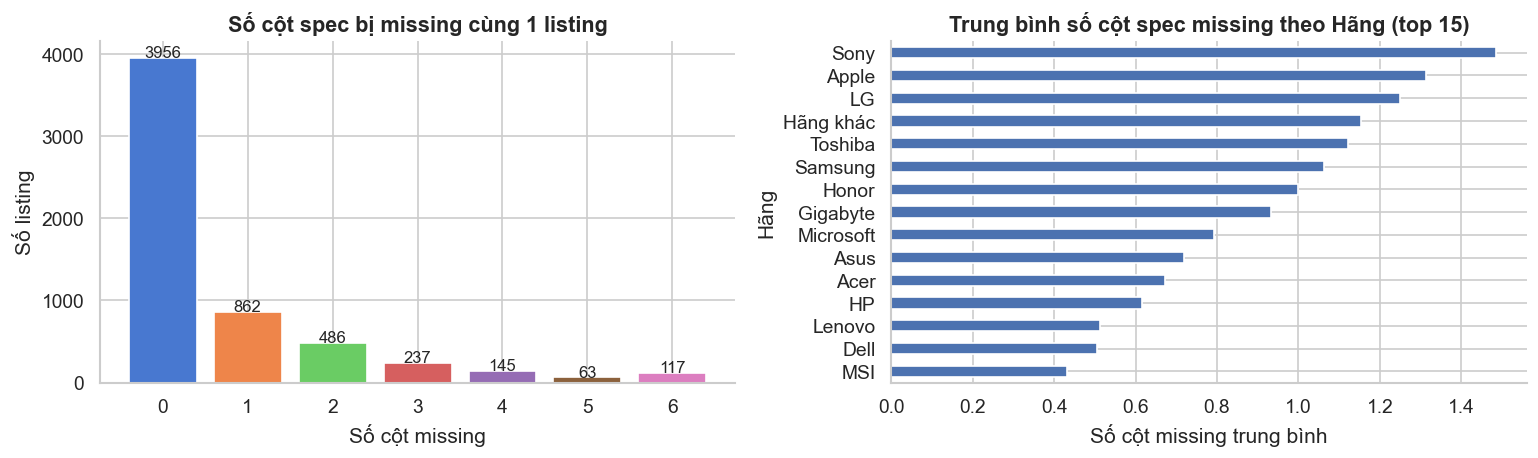


Listing missing 0 cột spec: 3,956 (67.4%)
Listing missing ≥ 3 cột spec: 562 (9.6%)


In [13]:
n_miss_spec = df[spec_cols].isnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = n_miss_spec.value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=COLORS[:len(vc)], edgecolor='white')
axes[0].set_title("Số cột spec bị missing cùng 1 listing")
axes[0].set_xlabel("Số cột missing")
axes[0].set_ylabel("Số listing")
for i, (x, y) in enumerate(zip(vc.index.astype(str), vc.values)):
    axes[0].text(i, y + 5, str(y), ha='center', fontsize=10)

brand_miss = df.copy()
brand_miss['n_miss_spec'] = n_miss_spec
brand_miss = brand_miss.groupby('Hãng')['n_miss_spec'].mean().sort_values(ascending=False).head(15)
brand_miss.sort_values().plot(kind='barh', ax=axes[1], color=ACCENT)
axes[1].set_title("Trung bình số cột spec missing theo Hãng (top 15)")
axes[1].set_xlabel("Số cột missing trung bình")
plt.tight_layout()
plt.show()

print(f"\nListing missing 0 cột spec: {(n_miss_spec == 0).sum():,} ({(n_miss_spec==0).mean()*100:.1f}%)")
print(f"Listing missing ≥ 3 cột spec: {(n_miss_spec >= 3).sum():,} ({(n_miss_spec>=3).mean()*100:.1f}%)")

### Missing per Listing & Brand

Phần lớn listing có dữ liệu khá đầy đủ, với khoảng **67.4%** không thiếu cột spec nào. Tuy nhiên, vẫn có khoảng **9.6%** listing thiếu từ 3 cột trở lên, cho thấy một phần dữ liệu có chất lượng thấp hơn.

Xét theo từng hãng, mức độ thiếu thông tin không đồng đều (**brand-dependent missingness**). Một số hãng như Sony, Apple có xu hướng thiếu nhiều thông tin hơn, trong khi các hãng như MSI, Dell, Lenovo có dữ liệu đầy đủ hơn.

Điều này cho thấy chất lượng dữ liệu phụ thuộc vào nguồn đăng tin và cần được xử lý cẩn thận trong preprocessing.

<Axes: >

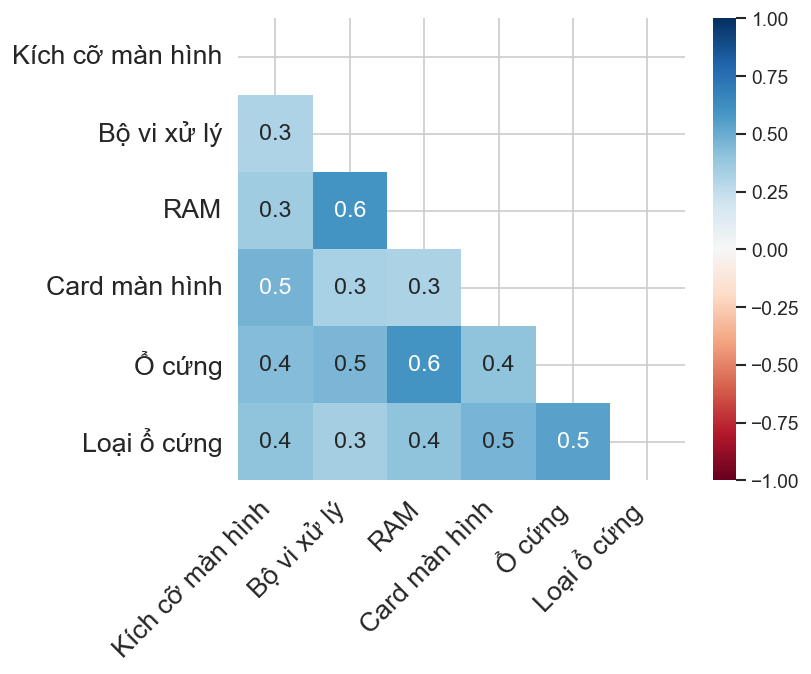

In [14]:
msno.heatmap(df[spec_cols], figsize=(6, 5))

### Missing Correlation

Heatmap cho thấy tồn tại **mối tương quan dương (positive correlation)** giữa các cột spec khi bị missing. Đặc biệt:

- `RAM` và `Ổ cứng` có tương quan cao (~0.6)
- `Ổ cứng` và `Loại ổ cứng` cũng có tương quan đáng kể (~0.5)

Điều này cho thấy missing values không xảy ra ngẫu nhiên (**not missing completely at random**), mà thường xuất hiện theo cụm giữa các thuộc tính phần cứng liên quan.

> Có thể tận dụng mối quan hệ này trong preprocessing, ví dụ **feature inference** (suy luận giá trị thiếu từ các cột liên quan) thay vì chỉ đơn thuần impute độc lập.

<Axes: >

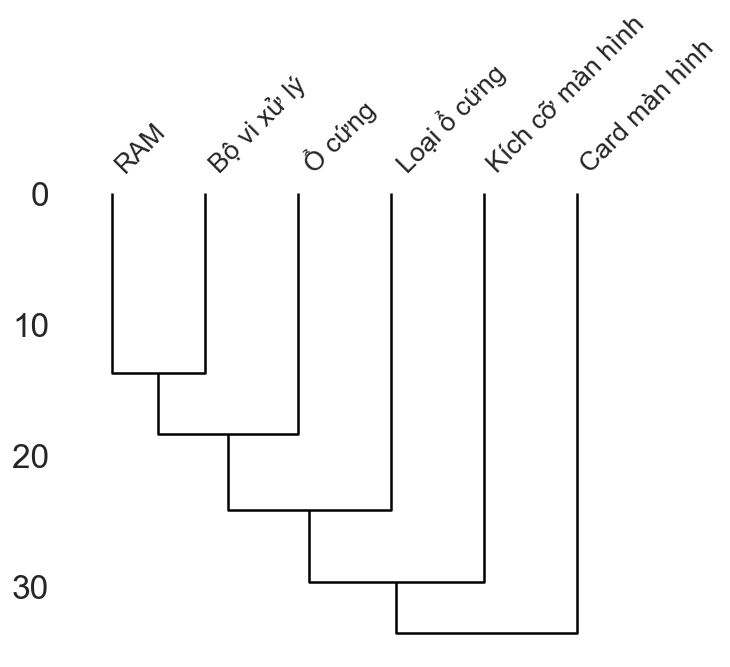

In [15]:
msno.dendrogram(df[spec_cols], figsize=(6, 5))

### Missing Structure (Dendrogram)

Biểu đồ dendrogram cho thấy các cột spec có xu hướng được nhóm lại theo mức độ missing tương tự nhau.

- `RAM` và `Bộ vi xử lý` nằm cùng cụm → thường missing cùng nhau
- `Ổ cứng` và `Loại ổ cứng` cũng có liên kết chặt chẽ
- `Card màn hình` và `Kích cỡ màn hình` tách biệt hơn → pattern missing khác

Kết quả này nhất quán với heatmap trước đó, cho thấy tương quan missing cao. Điều này xác nhận rằng missing values có cấu trúc (**structured & correlated missingness**), không phải ngẫu nhiên.

### Implications

- Có thể áp dụng **feature inference** giữa các cột cùng cụm (ví dụ: suy luận `Loại ổ cứng` từ `Ổ cứng`)
- Không nên impute độc lập từng cột, vì sẽ làm mất mối quan hệ giữa các feature
- Các cụm này có thể được dùng để thiết kế **group-wise imputation strategy**

Nhìn chung, dendrogram giúp củng cố và trực quan hóa lại các mối quan hệ đã quan sát từ heatmap, làm rõ rằng việc xử lý missing cần dựa trên cấu trúc dữ liệu thay vì áp dụng một phương pháp chung cho toàn bộ dataset.

## 5. Column: `price`

Giá ở dạng string `"X.XXX.XXX đ"` — cần parse. Các trường hợp cần lường trước:
- Format chuẩn: `"9.990.000 đ"`
- `"Thỏa thuận"` — người bán không muốn ghi cố định
- 1 dòng đã biết missing từ overview
- Outlier cực thấp/cao (nhập sai đơn vị, listing lạ)


In [16]:
# ── Các format giá xuất hiện ────────────────────────────────────────────────────
non_numeric = df['price'].dropna()[~df['price'].dropna().str.contains(r'\d', na=False)]
print(f"Giá không chứa số: {len(non_numeric)}")
print(non_numeric.value_counts().to_string())
print(f"\nGiá bị NaN (missing): {df['price'].isna().sum()}")


Giá không chứa số: 0
Series([], )

Giá bị NaN (missing): 1


In [17]:
# ── Parse & validate ────────────────────────────────────────────────────────────
price_clean = df['_price'].dropna()
price_mil   = price_clean / 1e6
desc = price_mil.describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).round(2)

display(desc.to_frame(name="Giá (triệu đồng)").T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Giá (triệu đồng),5865.0,9.92,8.36,0.01,0.6,1.5,4.5,7.6,12.99,25.97,39.64,99.9


### Price Descriptive Statistics (Laptop Dataset)

Dữ liệu giá laptop có **right-skewed distribution** khi mean (9.92) lớn hơn median (7.6), cho thấy sự tồn tại của các **outliers** ở phân khúc giá cao. Đồng thời, **high variability** (std = 8.36 gần bằng mean) phản ánh mức độ phân tán lớn, nghĩa là dữ liệu trải rộng trên nhiều **price segments** khác nhau.

Khoảng giá rất rộng, từ 0.01 đến 99.9 triệu, cho thấy dataset nhiều khả năng bao gồm cả **used** và **new laptops**. Tuy nhiên, phần lớn dữ liệu tập trung ở phân khúc thấp–trung (**low–mid segment concentration**), với median chỉ khoảng 7.6 triệu, tức đa số laptop có giá dưới ~10 triệu. Bên cạnh đó, sự chênh lệch lớn giữa 95th percentile (25.97) và max (99.9) cho thấy có một số **high-end outliers** như các dòng **premium, gaming hoặc workstation**, kéo giá trung bình tăng lên.

**Kết luận (Conclusion):** Dataset thể hiện một thị trường **mixed segments (used + new)**, trong đó phần lớn thuộc phân khúc **low–mid range**, nhưng bị ảnh hưởng bởi một số ít **high-end outliers**, dẫn đến phân phối lệch phải và độ phân tán cao.

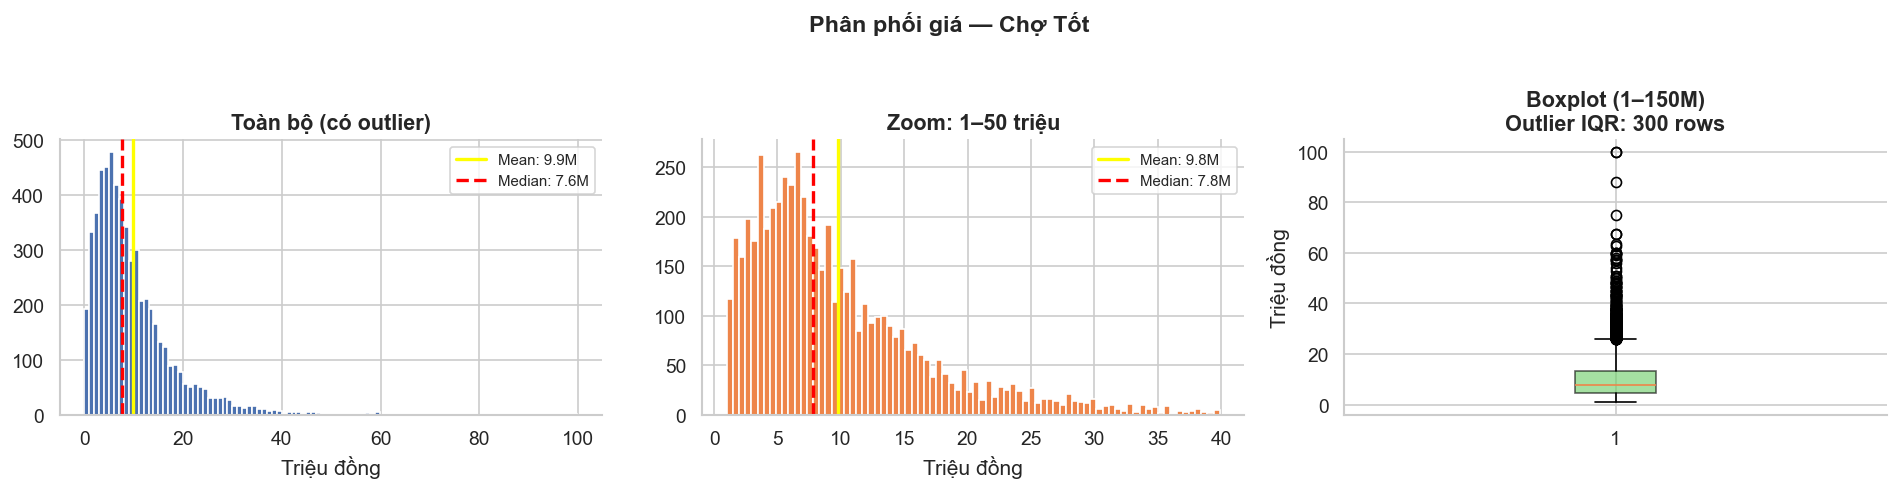

In [18]:
# ── Phân phối giá ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ===== Full range =====
axes[0].hist(price_mil, bins=100, color=ACCENT, edgecolor='white')

mean_full = price_mil.mean()
median_full = price_mil.median()

axes[0].axvline(mean_full, color='yellow', linestyle='-', linewidth=2,
                label=f'Mean: {mean_full:.1f}M')
axes[0].axvline(median_full, color='red', linestyle='--', linewidth=2,
                label=f'Median: {median_full:.1f}M')

axes[0].legend(fontsize=9)
axes[0].set_title("Toàn bộ (có outlier)")
axes[0].set_xlabel("Triệu đồng")


# ===== 1–40 triệu =====
p1_100 = price_mil[(price_mil >= 1) & (price_mil <= 40)]
axes[1].hist(p1_100, bins=80, color=COLORS[1], edgecolor='white')

mean_zoom = p1_100.mean()
median_zoom = p1_100.median()

axes[1].axvline(mean_zoom, color='yellow', linestyle='-', linewidth=2,
                label=f'Mean: {mean_zoom:.1f}M')
axes[1].axvline(median_zoom, color='red', linestyle='--', linewidth=2,
                label=f'Median: {median_zoom:.1f}M')

axes[1].legend(fontsize=9)
axes[1].set_title("Zoom: 1–50 triệu")
axes[1].set_xlabel("Triệu đồng")


# ===== Box & outlier detection =====
Q1, Q3 = price_mil.quantile(.25), price_mil.quantile(.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
n_outlier = ((price_mil < lo) | (price_mil > hi)).sum()

axes[2].boxplot(price_mil[(price_mil >= 1) & (price_mil <= 150)],
                vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLORS[2], alpha=0.6))

axes[2].set_title(f"Boxplot (1–150M)\nOutlier IQR: {n_outlier} rows")
axes[2].set_ylabel("Triệu đồng")


# ===== Style =====
for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("Phân phối giá — Chợ Tốt", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Price Distribution Insight (with Mean & Median)

Biểu đồ cho thấy rõ **right-skewed distribution** khi đường **mean (~9.9M)** luôn nằm bên phải **median (~7.6–7.8M)** ở cả hai histogram. Điều này xác nhận rằng một số **high-end outliers** đang kéo giá trung bình lên.

Ở biểu đồ full range, phần lớn dữ liệu vẫn tập trung mạnh ở khoảng <15 triệu, nhưng có đuôi dài đến ~100 triệu. Khi zoom vào 1–40 triệu, cấu trúc phân phối rõ hơn: đỉnh mật độ nằm quanh ~5–10 triệu, phản ánh phân khúc **low–mid range** chiếm đa số.

Boxplot củng cố điều này khi IQR nằm thấp (~4–12 triệu) nhưng xuất hiện rất nhiều điểm vượt whiskers, cho thấy số lượng lớn **outliers** phía trên.

**Kết luận:** Mean > Median + đuôi dài bên phải ⇒ dữ liệu lệch phải rõ rệt, thị trường gồm nhiều laptop giá rẻ–trung và một số ít máy cao cấp kéo phân phối.

In [19]:
# ── Giá bất thường ──────────────────────────────────────────────────────────────
print("=== Giá thấp bất thường (< 1.000,000 đ) ===")
display(df[df['_price'] <1_000_000][['url', 'title', 'price', '_price']].head(10))

print("\n=== Giá cao (> 60 triệu) ===")
display(df[df['_price'] > 60_000_000][['url', 'title', 'price', '_price']].head(10))

PRICE_LO, PRICE_HI = 1_000_000, 60_000_000
n_invalid = ((df['_price'] < PRICE_LO) | (df['_price'] > PRICE_HI)).sum()
print(f"\nGiá ngoài ngưỡng [{PRICE_LO/1e6:.0f}M – {PRICE_HI/1e6:.0f}M]: {n_invalid} rows")

=== Giá thấp bất thường (< 1.000,000 đ) ===


,url,title,price,_price
51,https://www.chotot.com/mua-ban-quan-binh-tan-tp-ho-chi-minh/132019136.htm,💥 LAPTOP Dell i5 XÀI TỐT CÓ CAMERA MÁY ZIN TEM,990.000 đ,990000.0
72,https://www.chotot.com/mua-ban-quan-ninh-kieu-can-tho/131938722.htm,(Đọc kỹ mô tả)Sạc laptop HP 90W đã qua sử dụng,120.000 đ,120000.0
78,https://www.chotot.com/mua-ban-quan-12-tp-ho-chi-minh/131968912.htm,lap top samsung,550.000 đ,550000.0
154,https://www.chotot.com/mua-ban-thanh-pho-thuan-an-binh-duong/132073283.htm,Acer Intel Core i3 4GB/500GB 95% mới,899.000 đ,899000.0
164,https://www.chotot.com/mua-ban-quan-binh-tan-tp-ho-chi-minh/131955581.htm,Bán laptop IBM T60 Đen,600.000 đ,600000.0
246,https://www.chotot.com/mua-ban-huyen-bac-tan-uyen-binh-duong/132006127.htm,"Bộ máy tính NEC i5 màn 16"", tặng Loa, Phím, Chuột",850.000 đ,850000.0
254,https://www.chotot.com/mua-ban-thi-xa-phuoc-long-binh-phuoc/131978007.htm,Laptop I7 giá xác,400.000 đ,400000.0
256,https://www.chotot.com/mua-ban-quan-8-tp-ho-chi-minh/131253248.htm,"Laptop HP Stream 13, model 13-c010nr",650.000 đ,650000.0
279,https://www.chotot.com/mua-ban-thanh-pho-thu-dau-mot-binh-duong/132076341.htm,Máy tính xách tay Dell màu Đen,750.000 đ,750000.0
304,https://www.chotot.com/mua-ban-quan-6-tp-ho-chi-minh/132034257.htm,Acer Laptop i5 14 inch 6GB/320GB,950.000 đ,950000.0



=== Giá cao (> 60 triệu) ===


,url,title,price,_price
340,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/132035969.htm,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu,74.900.000 đ,74900000.0
638,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131958179.htm,ASUS ROG STRIX SCAR 16 Ultra 9 32/8TB New Fullbox,99.900.000 đ,99900000.0
1367,https://www.chotot.com/mua-ban-quan-3-tp-ho-chi-minh/131779673.htm,MB Pro 16” M4 Pro 48Gb/1Tb - Cấu hình khủng,63.500.000 đ,63500000.0
1708,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131999886.htm,Macbook M3 MAX 16' Spaceblack Ram 36GB / Ssd 1TB,62.900.000 đ,62900000.0
2689,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131979010.htm,Razer Blade 18 2025 Ultra 9 275HX RTX5080 4K 240Hz,88.000.000 đ,88000000.0
3212,https://www.chotot.com/mua-ban-quan-phu-nhuan-tp-ho-chi-minh/131981076.htm,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,67.500.000 đ,67500000.0
4838,https://www.chotot.com/mua-ban-quan-10-tp-ho-chi-minh/131935353.htm,ASUS ROG Strix SCAR 16 Ultra 9 32GB/8TB RTX 5090,99.900.000 đ,99900000.0
5651,https://www.chotot.com/mua-ban-quan-tan-binh-tp-ho-chi-minh/132015723.htm,MacBook Pro 16 inch M5 Pro 24/1TB Black LL Newseal,67.500.000 đ,67500000.0



Giá ngoài ngưỡng [1M – 60M]: 167 rows


### Outlier Inspection (Extreme Price Cases)

Quan sát các mẫu **giá thấp bất thường (< 1M)** cho thấy nhiều bản ghi không thực sự là laptop hoàn chỉnh, mà là **phụ kiện (sạc, linh kiện)**, **máy lỗi**, hoặc **bán xác / giá tượng trưng** (ví dụ: “giá xác”, “đọc kỹ mô tả”). Điều này cho thấy presence của **invalid samples / noise** trong dữ liệu, không phù hợp nếu mục tiêu là modeling giá laptop thực.

Ở phía ngược lại, các mẫu **giá cao (> 60M)** chủ yếu thuộc phân khúc **premium / gaming / workstation**, như MacBook Pro cấu hình cao, ASUS ROG, Razer Blade. Đây là các **valid high-end samples**, nhưng số lượng rất ít, tạo thành **high-end outliers** và góp phần làm phân phối bị lệch phải.

**Kết luận (Conclusion):**
- Nhóm giá thấp: phần lớn là **noise / non-standard listings** → nên **lọc bỏ hoặc xử lý riêng**.
- Nhóm giá cao: là **valid but rare samples** → có thể giữ lại nhưng cân nhắc **log-transform** hoặc **robust scaling** khi modeling.
- Tổng thể: cần **data cleaning** để đảm bảo mô hình học đúng phân phối thực của giá laptop.

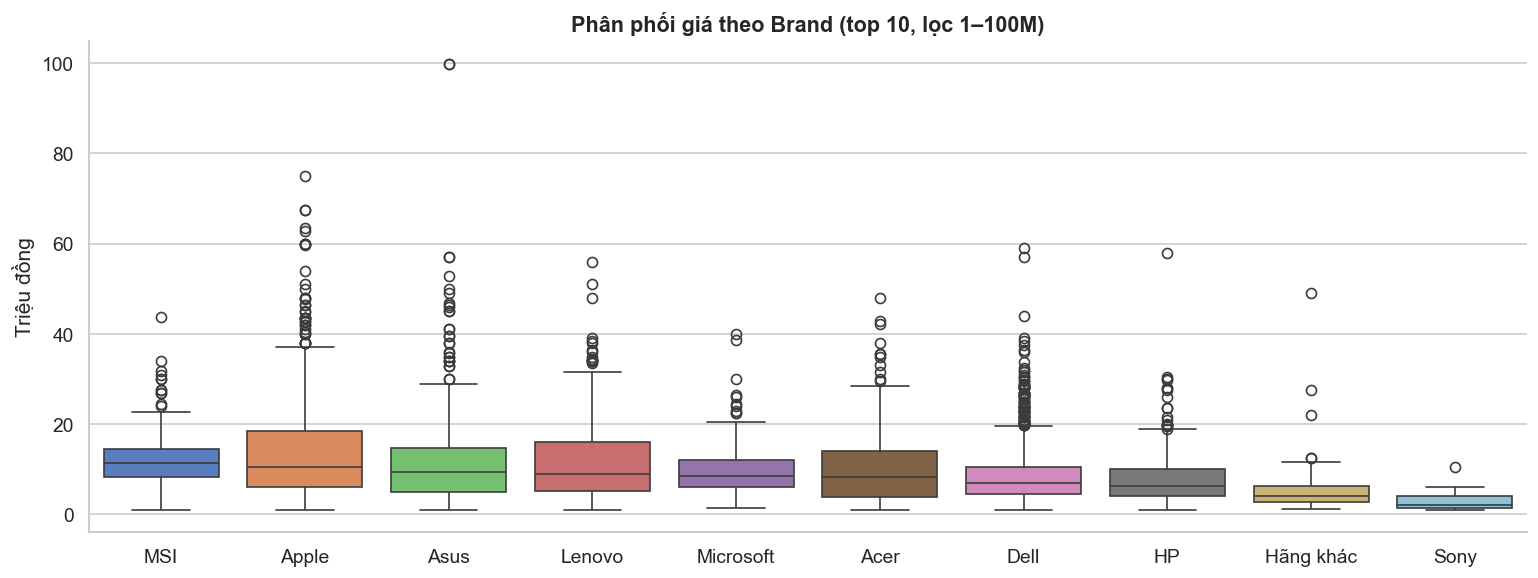

In [20]:
# ── Boxplot phân phối giá theo top-10 brand ────────────────────────────────────
top10_brands = df['Hãng'].value_counts().head(10).index
plot_brand = (df[df['Hãng'].isin(top10_brands) & df['_price'].between(1e6, 100e6)]
              .assign(price_mil=lambda x: x['_price']/1e6))
brand_order = plot_brand.groupby('Hãng')['price_mil'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=plot_brand, x='Hãng', y='price_mil', order=brand_order, palette='muted', ax=ax)
ax.set_title("Phân phối giá theo Brand (top 10, lọc 1–100M)")
ax.set_ylabel("Triệu đồng")
ax.set_xlabel("")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### Price Distribution by Brand (Top 10)

Biểu đồ boxplot theo **brand** cho thấy sự khác biệt rõ rệt về **price distribution** giữa các hãng. Nhìn chung, hầu hết các brand đều có **median** nằm trong khoảng ~7–12 triệu, phản ánh phân khúc **low–mid range** chiếm chủ đạo trên thị trường.

Tuy nhiên, một số brand như **Apple, ASUS, Dell, MSI** có **upper range** và số lượng **high-end outliers** vượt trội, với nhiều điểm giá >40–60 triệu. Đặc biệt, Apple có độ phân tán lớn và xuất hiện các giá trị rất cao (~70–100 triệu), cho thấy tập trung nhiều ở phân khúc **premium**. ASUS và MSI cũng có đuôi phải dài, phù hợp với các dòng **gaming laptops**.

Ngược lại, các brand như **Sony, “Hãng khác”** có **median thấp** và phân phối hẹp hơn, chủ yếu nằm ở phân khúc giá rẻ–trung. Điều này cho thấy sự khác biệt về **product positioning** giữa các hãng.

Ngoài ra, số lượng **outliers ngoài ngưỡng [1M–60M] (~167 rows)** vẫn xuất hiện rải rác ở nhiều brand, tiếp tục khẳng định dữ liệu có **high variance** và **right-skewed distribution**.

**Kết luận (Conclusion):** Dù phần lớn laptop thuộc phân khúc **low–mid range**, một số brand (đặc biệt Apple, ASUS, MSI) đóng góp đáng kể vào **high-end segment**, tạo ra sự lệch phải và độ phân tán lớn trong phân phối giá.

In [21]:
# ===== Quick numeric features (temporary for EDA) =====
def parse_ram(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    return float(nums[0]) if nums else np.nan

def parse_storage(val):
    if pd.isna(val): return np.nan
    v = str(val).upper()
    nums = re.findall(r'[\d\.]+', v)
    if not nums: return np.nan
    val = float(nums[0])
    return val * 1024 if 'TB' in v else val

df['_ram_gb'] = df['RAM'].apply(parse_ram)
df['_storage_gb'] = df['Ổ cứng'].apply(parse_storage)
df['_value_simple'] = df['_ram_gb'] / (df['_price'] / 1e6)

In [22]:
df_clean = df[
    (df['_price'] > 1_000_000) &
    (df['_ram_gb'].between(2, 64)) &
    (df['_value_simple'] < df['_value_simple'].quantile(0.995))
]

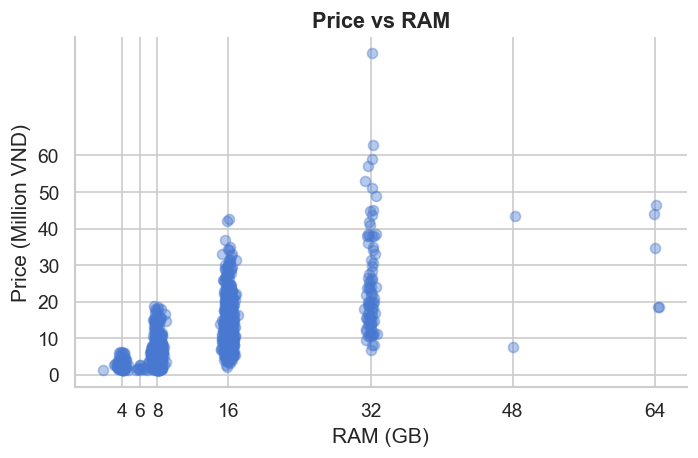

In [23]:
fig, ax = plt.subplots(figsize=(6,4))

sample = df_clean.dropna(subset=['_price', '_ram_gb']).sample(1500, random_state=42)

x = sample['_ram_gb'] + np.random.normal(0, 0.3, size=len(sample))

ax.scatter(x, sample['_price']/1e6, alpha=0.4)

ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Price (Million VND)")
ax.set_title("Price vs RAM")

ax.set_xticks([4, 6, 8, 16, 32, 48, 64])
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])

plt.tight_layout()
plt.show()

### Price vs RAM — Trade-off Analysis

Biểu đồ scatter giữa **price và RAM** cho thấy các điểm dữ liệu không phân bố liên tục mà tập trung thành các cụm dọc tại các mức RAM phổ biến như 4GB, 8GB, 16GB và 32GB. Điều này phản ánh bản chất của RAM là một **discrete feature**, không phải biến liên tục.

Quan sát quan trọng hơn là trong cùng một mức RAM, giá có độ phân tán rất lớn. Ví dụ, với **16GB RAM**, giá có thể dao động từ khoảng 5 triệu đến hơn 40 triệu VND. Điều này cho thấy RAM **không phải là yếu tố quyết định chính của price**. Nói cách khác, cùng một cấu hình RAM nhưng giá có thể khác nhau rất nhiều do ảnh hưởng của các yếu tố khác như CPU, GPU, build quality, brand hoặc dòng sản phẩm.

Ngoài ra, xu hướng tổng thể vẫn tồn tại: RAM cao hơn thường đi kèm với mức giá trung bình cao hơn. Tuy nhiên, mối quan hệ này **không tuyến tính và có độ nhiễu lớn**, cho thấy price là kết quả của nhiều yếu tố kết hợp chứ không phụ thuộc vào một feature đơn lẻ.

Từ góc độ xây dựng, insight quan trọng rút ra là:

* Không thể sử dụng RAM như một proxy trực tiếp cho performance hoặc value
* Cần kết hợp nhiều feature (CPU, GPU, storage, brand, v.v.) để đánh giá đúng giá trị của một laptop
* Price nên được xem như một biến trade-off thay vì target đơn giản

Kết luận, biểu đồ này nhấn mạnh rằng bài toán không phải là “RAM cao → giá cao”, mà là **“với cùng mức price, laptop nào có cấu hình tốt hơn”**, đây chính là nền tảng cho các bước value analysis và ranking phía sau.


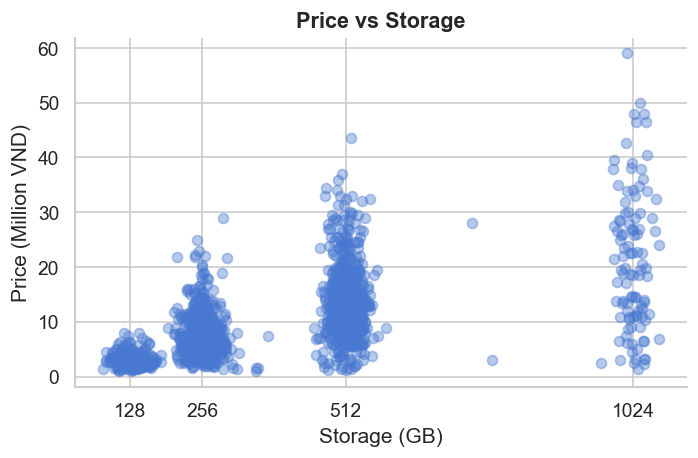

In [24]:
# ===== Price vs Storage (clean + improved) =====
fig, ax = plt.subplots(figsize=(6,4))

sample = df_clean.dropna(subset=['_price', '_storage_gb']).copy()

# lọc storage hợp lý (EDA-level)
sample = sample[
    (sample['_storage_gb'] >= 64) &
    (sample['_storage_gb'] <= 2048)
]

sample = sample.sample(1500, random_state=42)

# jitter để tránh chồng điểm
x = sample['_storage_gb'] + np.random.normal(0, 20, size=len(sample))

ax.scatter(x, sample['_price']/1e6, alpha=0.4)

ax.set_xlabel("Storage (GB)")
ax.set_ylabel("Price (Million VND)")
ax.set_title("Price vs Storage")

# ticks theo mốc phổ biến
ax.set_xticks([128, 256, 512, 1024])
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])

plt.tight_layout()
plt.show()

### Price vs Storage — Trade-off Analysis

Biểu đồ **Price vs Storage** cho thấy dữ liệu tiếp tục phân bố theo các cụm dọc rõ ràng tại các mức dung lượng phổ biến như **128GB, 256GB, 512GB và 1024GB (1TB)**. Điều này phản ánh storage cũng là một **discrete feature**, tương tự như RAM, và không phân bố liên tục.

Quan sát quan trọng là mặc dù dung lượng ổ cứng tăng, giá trung bình có xu hướng tăng theo, nhưng mức độ ảnh hưởng là **không mạnh và không ổn định**. Ví dụ, tại mức **512GB**, giá có thể dao động rất rộng từ khoảng 5 triệu đến hơn 40 triệu VND. Tương tự, các laptop **1TB** cũng trải dài từ phân khúc trung đến cao cấp, thay vì tập trung ở một khoảng giá cụ thể.

So với RAM, storage có vẻ là một yếu tố **ít quyết định hơn đối với price**. Điều này hợp lý về mặt thực tế, vì chi phí nâng cấp ổ cứng thường thấp hơn nhiều so với CPU hoặc GPU. Do đó, sự khác biệt về giá giữa các laptop có cùng dung lượng storage chủ yếu đến từ các yếu tố khác như hiệu năng xử lý, card đồ họa, thương hiệu hoặc phân khúc sản phẩm.

Ngoài ra, có thể nhận thấy một số điểm giá cao xuất hiện ở các mức storage lớn (512GB–1TB), nhưng đây không phải là quy luật cứng mà chỉ phản ánh việc các dòng laptop cao cấp thường đi kèm dung lượng lưu trữ lớn hơn.

Ta rút ra một số nhận xét:

* Storage không nên được sử dụng như một chỉ báo chính cho value hoặc performance
* Cần kết hợp với các feature khác (đặc biệt là CPU và GPU) để đánh giá đúng giá trị thực
* Price cần được phân tích dưới dạng **trade-off đa chiều**, thay vì gắn trực tiếp với một feature riêng lẻ

Kết luận, tương tự như RAM, biểu đồ này cho thấy bài toán không phải là “storage lớn → giá cao”, mà là **“trong cùng một mức giá, dung lượng và cấu hình tổng thể có cân đối hay không”**, từ đó phục vụ cho các bước value analysis và ranking phía sau.


In [25]:
# ===== Overpriced candidates (improved with brand) =====

# Binning
df_clean['_ram_bin'] = pd.cut(df_clean['_ram_gb'], [0, 8, 16, 32, 64])
df_clean['_storage_bin'] = pd.cut(df_clean['_storage_gb'], [0, 256, 512, 1024, 2048])

# Group theo RAM + Storage + Brand
group_median = df_clean.groupby(
    ['Hãng', '_ram_bin', '_storage_bin']
)['_price'].median()

# Map expected price
df_clean['_expected_price'] = df_clean.set_index(
    ['Hãng', '_ram_bin', '_storage_bin']
).index.map(group_median)

# Price gap
df_clean['_price_gap'] = df_clean['_price'] - df_clean['_expected_price']

# % gap
df_clean['_price_gap_pct'] = df_clean['_price_gap'] / df_clean['_expected_price']

# Top overpriced
df_clean.sort_values('_price_gap_pct', ascending=False)[
    ['title', 'Hãng', '_ram_gb', '_storage_gb', '_price', '_expected_price', '_price_gap_pct']
].head(10)

,title,Hãng,_ram_gb,_storage_gb,_price,_expected_price,_price_gap_pct
3212,Apple MacBook Pro 16 inch M5 Pro 24GB/1TB,Apple,16.0,1024.0,67500000.0,16300000.0,3.141104
5651,MacBook Pro 16 inch M5 Pro 24/1TB Black LL Newseal,Apple,16.0,1024.0,67500000.0,16300000.0,3.141104
2056,DELL Precision 7670-I7-12850HX–R 32G-RTX A3000-12G,Dell,16.0,256.0,33800000.0,8500000.0,2.976471
695,Dell Precision 7550 i7-10750H/16GB/512GB/RTX 3000,Dell,8.0,256.0,16000000.0,5000000.0,2.200000
316,HP Victus 15 i5-13420H RTX 3050 6GB Newseal,HP,8.0,512.0,18800000.0,5974500.0,2.146707
5783,"Macbook Pro 2017 i5 8G 1TB\SSD 13"" inch BH 6 tháng",Apple,8.0,1024.0,9500000.0,3069950.0,2.094513
3614,Dell xps 9640 ultra 9 185h/64/2T/rtx4070/4k oled,Dell,32.0,1024.0,59000000.0,19245000.0,2.065731
5423,Lenovo Ideapad Duet màn 2.5k keng rẻ sài ít giờ,Hãng khác,8.0,250.0,11000000.0,3650000.0,2.013699
3546,Sony VAIO PRO i7-5500U 13.3 inch 8GB/256GB,Sony,8.0,256.0,6000000.0,2000000.0,2.000000
1953,"HP VICTUS 15 i5-13420H/8GB/512G/3050/15.6"" 144Hz",HP,8.0,512.0,17900000.0,5974500.0,1.996067


### Baseline Price Gap Analysis (RAM + Storage + Brand)

Trong bước này, một phương pháp heuristic đơn giản được sử dụng để ước lượng **expected price** cho mỗi laptop dựa trên các cấu hình tương tự. Cụ thể, dữ liệu được nhóm theo **brand, RAM và storage (đã được binning)**, sau đó lấy **median price** của mỗi nhóm làm giá tham chiếu.

- `_expected_price`: giá trung vị của các laptop có cấu hình tương tự
- `_price_gap`: chênh lệch giữa giá thực tế và giá kỳ vọng
- `_price_gap_pct`: chênh lệch theo tỷ lệ, giúp so sánh công bằng giữa các mức giá khác nhau

Kết quả cho thấy nhiều laptop, đặc biệt là các dòng cao cấp như MacBook hoặc workstation/gaming, có `_price_gap_pct` rất cao. Tuy nhiên, điều này **không có nghĩa là các sản phẩm này bị overpriced**, mà phản ánh rằng mô hình hiện tại chưa capture được các yếu tố quan trọng như CPU, GPU và phân khúc sản phẩm.

Nói cách khác, phương pháp này cho thấy **RAM, storage và brand vẫn chưa đủ để giải thích sự biến động của price**. Đây là một bước kiểm tra hữu ích để đánh giá giới hạn của feature hiện tại, và làm cơ sở để bổ sung các feature mạnh hơn trong các bước tiếp theo.

In [26]:
df['_value_simple'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

count    5627.000000
mean        2.287086
std        22.202958
min         0.013351
50%         1.454545
90%         3.076923
95%         4.000000
99%         7.272727
99.9%      57.582851
max      1230.769231
Name: _value_simple, dtype: float64

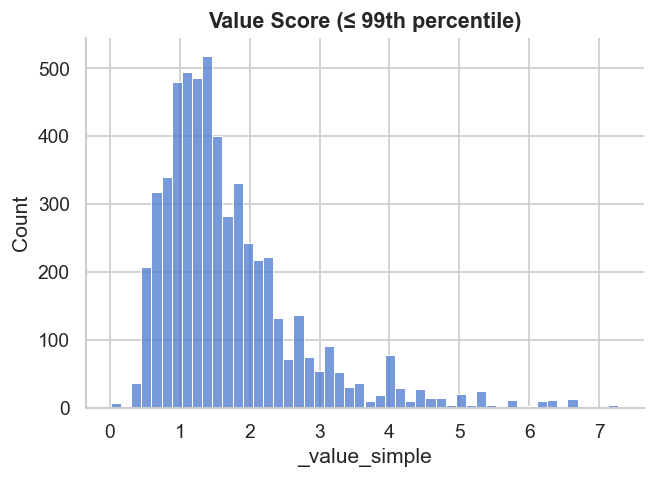

In [27]:
val = df['_value_simple'].dropna()

upper = val.quantile(0.99)   # hoặc 0.995 1 số outlier cực lớn phá distribution sẽ xử l sau tạm thời dùng 0.99
val_cut = val[val <= upper]

plt.figure(figsize=(6,4))
sns.histplot(val_cut, bins=50)
plt.title("Value Score (≤ 99th percentile)")
plt.show()

### Value Score Analysis (RAM / Price)

Giá trị `_value_simple` được định nghĩa là:

$$
\text{value\_simple} = \frac{\text{RAM (GB)}}{\text{price (million VND)}}
$$

Tức là đo lường **số GB RAM trên mỗi triệu VND**, nhằm đánh giá mức độ “bang-for-buck” cơ bản của laptop.

Sau khi loại bỏ các outlier (trên 99th percentile), phân phối value score cho thấy:

- Phần lớn laptop tập trung trong khoảng **1 → 2**
- Một số ít đạt **3 → 5**, được xem là các lựa chọn có value cao
- Đuôi phải (tail) vẫn tồn tại nhưng đã được kiểm soát, phản ánh các trường hợp giá thấp hoặc cấu hình tương đối tốt

Insight quan trọng:

- Giá trị value cao thường đến từ:
  - laptop giá rẻ nhưng RAM tương đối lớn
  - hoặc các cấu hình cân đối trong phân khúc tầm trung
- Ngược lại, các laptop cao cấp (MacBook, gaming high-end) thường có value thấp hơn vì giá bị chi phối bởi CPU, GPU và build quality, không chỉ RAM

Tuy nhiên, cần lưu ý:

- Metric này **rất đơn giản và chưa đầy đủ**, vì chỉ dựa trên RAM
- Không phản ánh hiệu năng tổng thể (CPU, GPU)
- Không phù hợp để dùng trực tiếp cho recommender

Do đó, `_value_simple` chỉ nên được xem là **baseline metric**, giúp hiểu sơ bộ về trade-off giữa RAM và price, trước khi xây dựng các value score phức tạp hơn.

In [28]:
df_clean.sort_values('_value_simple', ascending=False)[
    ['title', '_ram_gb', '_price', '_value_simple']
].head(15)

,title,_ram_gb,_price,_value_simple
1146,Toshiba Dynabook T554/45LR i3-4005U 15.6 inch 12GB,16.0,1800000.0,8.888889
4214,Apple MacBook Pro i5 10GB/500GB Bạc,16.0,2000000.0,8.000000
1464,Dell M4600 i7-2720QM 12GB/120GB,16.0,2000000.0,8.000000
1635,HP i3 12GB Đen,16.0,2000000.0,8.000000
2836,Laptop Dell E4310 i5 8GB SSD128GB Win11pro HDMI-TV,8.0,1090000.0,7.339450
3417,Dell Latitude E6430 i7 16GB Pin chai,16.0,2200000.0,7.272727
2102,Apple MacBook Pro Bạc Retina,8.0,1100000.0,7.272727
3381,Dell,8.0,1200000.0,6.666667
4792,Acer Corei5 -7200U / ddr4 8gb / ổ ssd M2 WD 250gb,8.0,1200000.0,6.666667
734,Lenovo Thinkpad T440p i5-4310m 8GB/500GB HDD,8.0,1200000.0,6.666667


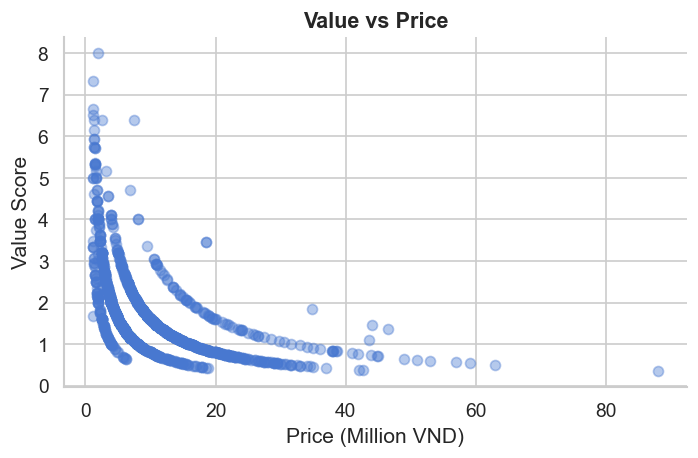

In [29]:
fig, ax = plt.subplots(figsize=(6,4))

sample = df_clean.dropna(subset=['_value_simple', '_price']).sample(1500, random_state=42)

ax.scatter(sample['_price']/1e6, sample['_value_simple'], alpha=0.4)
ax.set_xlabel("Price (Million VND)")
ax.set_ylabel("Value Score")
ax.set_title("Value vs Price")

plt.tight_layout()
plt.show()

### Value vs Price — Trade-off Analysis

Biểu đồ **Value vs Price** cho thấy mối quan hệ rất rõ giữa giá và value score (RAM / price). Cụ thể, tồn tại một xu hướng giảm mạnh: khi **price tăng**, value score có xu hướng **giảm nhanh theo dạng phi tuyến**.

Điều này là hợp lý về mặt định nghĩa, vì value score có price ở mẫu số. Tuy nhiên, biểu đồ vẫn mang lại một số insight quan trọng:

- Ở phân khúc giá thấp (dưới ~10 triệu), value score phân bố rộng và có nhiều điểm đạt giá trị cao (3–8), cho thấy đây là khu vực có nhiều “bang-for-buck” tốt.
- Khi giá tăng (20–40 triệu), value score bắt đầu co lại, chủ yếu nằm trong khoảng 0.5–2, phản ánh việc chi phí tăng nhưng RAM không tăng tương ứng.
- Ở phân khúc cao cấp (>40 triệu), value score rất thấp (<1), cho thấy giá không còn tỷ lệ thuận với RAM mà bị chi phối bởi các yếu tố khác như CPU, GPU, build quality và thương hiệu.

Một đặc điểm đáng chú ý là các đường cong (curves) xuất hiện trong biểu đồ. Đây thực chất là các mức RAM cố định (8GB, 16GB, 32GB…), vì với mỗi mức RAM, value score sẽ giảm theo dạng:

$$
value = \frac{\text{RAM}}{\text{price}}
$$

Do đó, mỗi “curve” tương ứng với một cấu hình RAM cụ thể.

Từ góc độ recommender system, insight chính là:

- Value cao không đồng nghĩa với laptop tốt hơn, mà chỉ phản ánh hiệu quả chi phí theo một chiều (RAM)
- Các laptop giá cao có value thấp nhưng vẫn đáng mua trong các use-case như gaming, development hoặc thiết kế
- Cần xây dựng value score đa chiều (CPU, GPU, RAM…) thay vì chỉ dựa trên RAM

Kết luận, biểu đồ này nhấn mạnh rằng bài toán không phải là “giá thấp → tốt hơn”, mà là **“giá đó mang lại hiệu năng tổng thể gì”**, từ đó dẫn tới việc xây dựng các scoring function phức tạp hơn ở các bước sau.

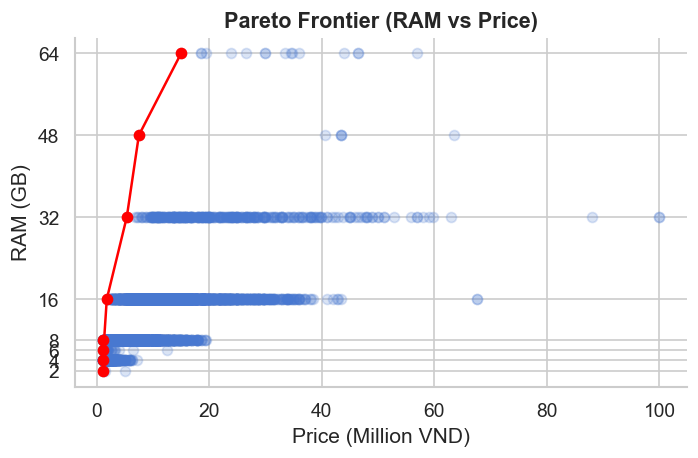

In [30]:
# ===== Pareto frontier (fixed RAM levels) =====

ram_levels = [2, 4, 6, 8, 16, 32, 48, 64]

# 1. Filter dữ liệu hợp lệ
df_pf = df_clean.dropna(subset=['_ram_gb', '_price']).copy()

# 2. Giữ các RAM gần nhất trong levels
df_pf = df_pf[df_pf['_ram_gb'].isin(ram_levels)]

# 3. Với mỗi RAM, lấy laptop rẻ nhất (best price)
pareto_df = (
    df_pf.groupby('_ram_gb')
    .apply(lambda x: x.loc[x['_price'].idxmin()])
    .reset_index(drop=True)
)

# 4. Sort theo price để vẽ đường frontier
pareto_df = pareto_df.sort_values('_price')

# ===== Plot =====
plt.figure(figsize=(6,4))

plt.scatter(df_pf['_price']/1e6, df_pf['_ram_gb'], alpha=0.2)

plt.plot(
    pareto_df['_price']/1e6,
    pareto_df['_ram_gb'],
    marker='o',
    color='red'
)

plt.xlabel("Price (Million VND)")
plt.ylabel("RAM (GB)")
plt.title("Pareto Frontier (RAM vs Price)")

plt.yticks(ram_levels)

plt.tight_layout()
plt.show()

### Pareto Frontier (RAM vs Price) — Analysis

Biểu đồ Pareto Frontier thể hiện **mức giá thấp nhất cần trả để đạt được từng mức RAM**, từ đó mô tả trade-off giữa chi phí và cấu hình.

Một số quan sát quan trọng:

- Đường Pareto (màu đỏ) có dạng **tăng dần rõ rệt**, cho thấy để đạt RAM cao hơn, người dùng phải trả mức giá tối thiểu ngày càng lớn.
- Từ **2GB → 8GB**, mức tăng giá là tương đối nhỏ, cho thấy đây là phân khúc phổ thông với chi phí nâng cấp thấp.
- Từ **8GB → 16GB**, bắt đầu xuất hiện bước nhảy đáng kể về giá, phản ánh sự chuyển dịch sang phân khúc tầm trung.
- Từ **16GB → 32GB**, chi phí tăng mạnh hơn, cho thấy đây là ngưỡng quan trọng về hiệu năng.
- Từ **32GB → 48GB → 64GB**, giá tăng rất nhanh, thể hiện hiện tượng **diminishing returns** — chi phí tăng nhiều nhưng lợi ích (RAM) không tăng tương ứng.

Ngoài ra, phần scatter cho thấy:
- Nhiều laptop có cùng mức RAM nhưng giá cao hơn đáng kể so với Pareto frontier → các sản phẩm này không tối ưu về mặt chi phí/RAM.
- Pareto frontier đại diện cho các lựa chọn “tối ưu nhất” nếu chỉ xét RAM và price.

Tuy nhiên, cần lưu ý:

- Phân tích này chỉ dựa trên RAM, nên chưa phản ánh đầy đủ hiệu năng thực tế (CPU, GPU, build quality).
- Các laptop nằm ngoài frontier không hẳn là lựa chọn kém, mà có thể cung cấp giá trị ở các khía cạnh khác.

Kết luận:

Pareto frontier cho thấy rõ trade-off giữa RAM và price, đồng thời giúp xác định các cấu hình có hiệu quả chi phí tốt nhất. Tuy nhiên, để xây dựng recommender system chính xác, cần mở rộng sang các dimension khác như CPU và GPU.

## 6. Column: `title`

Tiêu đề listing tự do — noisy nhưng có tiềm năng extract thêm thông tin cho các cột spec bị missing.


count    5866.0
mean       41.7
std         8.1
min         2.0
25%        37.0
50%        44.0
75%        48.0
max        50.0


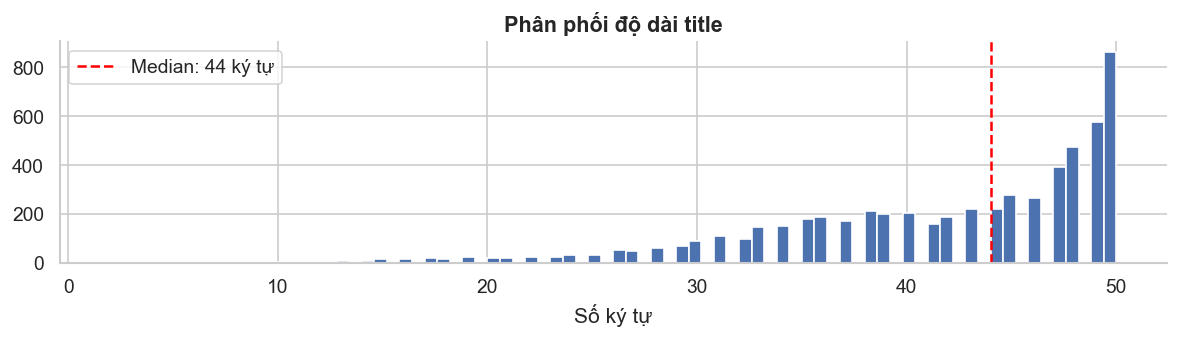

In [31]:
# ── Phân phối độ dài title ─────────────────────────────────────────────────────
title_len = df['title'].str.len()
print(title_len.describe().round(1).rename("Độ dài title (ký tự)").to_string())

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(title_len.dropna(), bins=80, color=ACCENT, edgecolor='white')
ax.axvline(title_len.median(), color='red', linestyle='--',
           label=f'Median: {title_len.median():.0f} ký tự')
ax.set_title("Phân phối độ dài title")
ax.set_xlabel("Số ký tự")
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
# ── Title basic quality ────────────────────────────────────────────────────────
title_s = df['title'].fillna('').astype(str)

title_quality = pd.DataFrame({
    'Metric': [
        'Missing title',
        'Empty after strip',
        'Duplicate title',
        'Unique title',
        'Avg chars',
        'Median chars',
        'Avg words',
        'Median words'
    ],
    'Value': [
        df['title'].isna().sum(),
        title_s.str.strip().eq('').sum(),
        df['title'].duplicated(keep=False).sum(),
        df['title'].nunique(),
        round(title_s.str.len().mean(), 1),
        round(title_s.str.len().median(), 1),
        round(title_s.str.split().str.len().mean(), 1),
        round(title_s.str.split().str.len().median(), 1),
    ]
})

display(title_quality)

,Metric,Value
0,Missing title,0.0
1,Empty after strip,0.0
2,Duplicate title,211.0
3,Unique title,5749.0
4,Avg chars,41.7
5,Median chars,44.0
6,Avg words,7.3
7,Median words,7.0


### Title Quality Analysis

Kết quả kiểm tra cho thấy cột `title` có chất lượng dữ liệu rất tốt về mức độ đầy đủ. Không có giá trị bị thiếu và cũng không tồn tại trường hợp chuỗi rỗng sau khi loại bỏ khoảng trắng. Điều này cho thấy tất cả các listing đều có tiêu đề hợp lệ, và `title` có thể được sử dụng xuyên suốt trong các bước phân tích mà không cần xử lý missing.

Bên cạnh đó, số lượng title unique chiếm gần như toàn bộ dataset (khoảng 98%), trong khi số lượng duplicate chỉ chiếm một tỷ lệ nhỏ. Điều này phản ánh đúng đặc trưng của dữ liệu marketplace, nơi mỗi listing thường được viết riêng biệt, nhưng vẫn tồn tại một số trường hợp trùng lặp về nội dung do nhiều người bán đăng cùng một sản phẩm hoặc đăng lại nhiều lần.

Xét về độ dài, title có trung bình khoảng 7 từ và khoảng 42 ký tự. Đây là mức độ dài tương đối hợp lý: không quá ngắn để thiếu thông tin, nhưng cũng không quá dài để trở nên nhiễu. Điều này cho thấy phần lớn title có cấu trúc cô đọng, thường bao gồm các thành phần chính như brand, model và một số thông tin cấu hình cơ bản.

Từ những đặc điểm trên, có thể nhận định rằng `title` khá đầy đủ. Tuy nhiên, do đây là dữ liệu do người bán tự nhập nên vẫn có khả năng chứa các yếu tố không chuẩn hóa hoặc mang tính quảng cáo. Vì vậy, trong các bước tiếp theo, `title` nên được sử dụng theo hướng trích xuất thông tin có cấu trúc (như CPU, RAM, storage) kết hợp với việc xử lý hoặc lọc các yếu tố nhiễu nếu cần thiết.

In [33]:
# ── Information coverage in title ──────────────────────────────────────────────
title_lower = df['title'].fillna('').str.lower()

patterns = {
    'Brand mentioned': r'\b(dell|hp|asus|acer|lenovo|apple|macbook|msi|lg|microsoft|surface|toshiba|sony|samsung|panasonic|razer|gigabyte)\b',
    'CPU mentioned': r'\b(i[3579][-\s]?\d{3,5}[a-z]{0,2}|intel core i[3579]|ryzen\s?[3579]|m[12345](\s?(pro|max|ultra))?|core ultra\s?[579])\b',
    'RAM mentioned': r'\b(4|8|12|16|24|32|36|48|64|96|128)\s?gb\b',
    'Storage mentioned': r'\b(128|256|512|1000|1024|1tb|2tb|500)\s?(gb|tb)?\b',
    'Screen mentioned': r'\b(10|11|12|13|13\.3|14|15|15\.6|16|17|17\.3)\s?(inch|inches|")\b',
    'GPU mentioned': r'\b(rtx|gtx|nvidia|quadro|mx\d+|radeon|iris xe|arc)\b',
    'Condition / promo words': r'\b(new|newseal|zin|đẹp|keng|like new|fullbox|bh|bảo hành|xách tay|thanh lý)\b',
}

coverage = []
for name, pat in patterns.items():
    mask = title_lower.str.contains(pat, regex=True, na=False)
    coverage.append({
        'Feature group': name,
        'Count': mask.sum(),
        'Percent (%)': round(mask.mean() * 100, 1)
    })

coverage_df = pd.DataFrame(coverage).sort_values('Percent (%)', ascending=False)
display(coverage_df)

,Feature group,Count,Percent (%)
0,Brand mentioned,5364,91.4
2,RAM mentioned,3348,57.1
3,Storage mentioned,3219,54.9
1,CPU mentioned,2636,44.9
4,Screen mentioned,1359,23.2
6,Condition / promo words,649,11.1
5,GPU mentioned,352,6.0


### Information Coverage in `title`

**Brand**, xuất hiện trong hơn 90% các title. Điều này cho thấy người bán gần như luôn đề cập đến hãng sản xuất, và do đó `title` có thể được xem là một nguồn đáng tin cậy để xác định brand trong trường hợp cột structured bị thiếu hoặc không chuẩn hóa.

Các thông tin về cấu hình phần cứng như **RAM** và **storage** cũng xuất hiện với tần suất khá cao, lần lượt khoảng 57% và 55%. Điều này cho thấy hơn một nửa các listing có đề cập trực tiếp đến dung lượng bộ nhớ và ổ cứng trong title. Tuy nhiên, mức coverage này vẫn chưa đủ để thay thế hoàn toàn các cột structured, mà chỉ nên được sử dụng như nguồn bổ sung.

Đối với **CPU**, tỷ lệ xuất hiện thấp hơn, khoảng 45%. Thông tin về **kích thước màn hình** xuất hiện khá hạn chế (khoảng 23%), cho thấy đây không phải là yếu tố thường xuyên được nhấn mạnh trong title. Tương tự, các thông tin về **GPU** chỉ xuất hiện trong khoảng 6% các trường hợp, chủ yếu tập trung ở các dòng máy gaming hoặc workstation

Ngoài ra, các từ khóa liên quan đến **tình trạng hoặc quảng cáo** như "new", "zin", "like new", "bảo hành" xuất hiện trong khoảng 11% title. Những từ này không mang ý nghĩa cấu hình nhưng có thể phản ánh tình trạng sản phẩm hoặc chiến lược bán hàng, và có thể được encode thành các feature dạng binary trong các mô hình.

Do mức độ coverage không đồng đều và tồn tại khả năng nhiễu, `title` nên được sử dụng một cách chọn lọc, ưu tiên cho feature extraction và hỗ trợ xử lý missing, thay vì thay thế hoàn toàn các cột structured.

In [34]:
cpu_pat_str = r'''(?ix)
\b(
    i[3579][-\s]?\d{4,5}[A-Z]{0,2} |
    Ryzen\s?[3579]\s?\d{3,5}[A-Z]{0,2} |
    Ryzen\s?[3579] |
    M[1-4]\s?(Pro|Max|Ultra)? |
    N\d{3,5} |
    Celeron | Pentium | Athlon | Core\s?Ultra
)\b
'''

ram_pat_str = r'(?i)\b(4|8|12|16|24|32|64|128)\s?GB\b'

# ── Mask missing ──────────────────────────────────────────────────────────────
missing_cpu_mask = df['Bộ vi xử lý'].isna()
missing_ram_mask = df['RAM'].isna()

# ── Detect trong title (Sử dụng string pattern trực tiếp) ──────────────────────
# Lưu ý: Không dùng case=False khi pattern đã có (?i)
title_has_cpu = df['title'].str.contains(cpu_pat_str, na=False, regex=True)
title_has_ram = df['title'].str.contains(ram_pat_str, na=False, regex=True)

# ── Tính đúng % trên subset missing ────────────────────────────────────────────
cpu_hits = (missing_cpu_mask & title_has_cpu).sum()
ram_hits = (missing_ram_mask & title_has_ram).sum()

cpu_total = missing_cpu_mask.sum()
ram_total = missing_ram_mask.sum()

cpu_rate = (cpu_hits / cpu_total * 100) if cpu_total > 0 else 0
ram_rate = (ram_hits / ram_total * 100) if ram_total > 0 else 0

# ── Output ─────────────────────────────────────────────────────────────────────
print(f"Dòng thiếu 'Bộ vi xử lý': {cpu_total}")
print(f"  → Title có CPU pattern: {cpu_hits} ({cpu_rate:.1f}%)")

print(f"\nDòng thiếu 'RAM': {ram_total}")
print(f"  → Title có RAM pattern: {ram_hits} ({ram_rate:.1f}%)")

Dòng thiếu 'Bộ vi xử lý': 249
  → Title có CPU pattern: 30 (12.0%)

Dòng thiếu 'RAM': 239
  → Title có RAM pattern: 32 (13.4%)


### Missing Recovery Potential from `title`

Mặc dù `title` có chứa nhiều thông tin cấu hình ở mức tổng thể, nhưng khi xét riêng trên các dòng bị thiếu dữ liệu structured, khả năng phục hồi từ title lại khá hạn chế.

Cụ thể, trong số 249 dòng thiếu thông tin về CPU, chỉ có khoảng 12% có thể phát hiện pattern CPU trong title. Tương tự, với 239 dòng thiếu RAM, tỷ lệ recover từ title chỉ khoảng 13%.

Điều này cho thấy một đặc điểm quan trọng của dataset: các listing bị thiếu thông tin cấu hình thường cũng không cung cấp đầy đủ thông tin trong title. Nói cách khác, việc thiếu dữ liệu không hoàn toàn ngẫu nhiên, mà có xu hướng đi kèm với title nghèo thông tin.

Do đó, mặc dù `title` có thể được sử dụng để bổ sung một phần nhỏ giá trị bị thiếu, nhưng không thể xem đây là giải pháp chính cho bài toán missing values. Trong pipeline xử lý dữ liệu, `title` nên được sử dụng như một nguồn fallback, kết hợp với các phương pháp imputation khác thay vì phụ thuộc hoàn toàn vào việc trích xuất từ text.

In [35]:
# ── RAM extraction risk: false positives from storage ──────────────────────────
ram_raw = df['title'].str.extract(r'(?i)\b(\d{1,3})\s?gb\b', expand=False)
ram_raw_num = pd.to_numeric(ram_raw, errors='coerce')

ram_raw_counts = ram_raw_num.value_counts().sort_index()

display(ram_raw_counts.rename('Count').to_frame())

# Các giá trị khó có khả năng là RAM laptop phổ biến
suspicious_ram = df[
    ram_raw_num.isin([120, 128, 240, 256, 500, 512, 750])
][['title', 'RAM', 'Ổ cứng']].head(20)

print(f"Số title có RAM-like value đáng nghi: {len(suspicious_ram)} sample shown")
display(suspicious_ram)

,Count
title,
2.0,25
3.0,1
4.0,241
6.0,46
8.0,1585
10.0,2
12.0,41
16.0,1202
18.0,10


Số title có RAM-like value đáng nghi: 20 sample shown


,title,RAM,Ổ cứng
15,Dell Precision 5550 750GB Xeon W-10855M RAM 32GB,32 GB,750 GB
45,Asus Tuf Ryzen 5 7535HS 16/512GB RTX 2050 còn BH,16 GB,512 GB
50,7TR5 CÓ NGAY MACBOOK AIR 2020 512GB - SIÊU PHẨM LƯ,NaN,512 GB
87,Macbook pro M3 PRO 14' Spaceblack Ram 36/Ssd 512GB,<1 GB,512 GB
103,Laptop Dell i7 4600u 4g hdd 500gb,NaN,NaN
188,Dell Latitude E5270 12.5 i5-6300U8GB/128GB Pin 4H,8 GB,< 128 GB
284,ACER ASPIRE 7 I5 12450H/8/512GB/RTX 2050,8 GB,512 GB
299,Surface Pro 5 M3 | Ram4 | 128GB tặng phím chuột,4 GB,128 GB
301,Asus TUF F15 FX506HF - i5 11400H/512GB/RTX 2050,16 GB,512 GB
358,HP ZBook Firefly 14 G8 i7-1165G7 16G 512GB FHD,16 GB,512 GB


### RAM Extraction Risk — False Positives from Storage

Khi thử extract giá trị RAM từ `title` bằng pattern đơn giản dạng `XGB`, kết quả phân phối cho thấy nhiều giá trị bất thường xuất hiện, chẳng hạn như 128GB, 256GB, 512GB, thậm chí 500GB hoặc 750GB. Đây là những mức dung lượng phổ biến của **ổ cứng (storage)** chứ không phải RAM trong laptop thông thường.

Phân tích chi tiết cho thấy các giá trị này xuất hiện với tần suất đáng kể, ví dụ 256GB và 512GB chiếm số lượng lớn trong các kết quả match. Điều này cho thấy regex hiện tại không phân biệt được ngữ cảnh và đang bắt nhầm các thông tin storage thành RAM.

Việc kiểm tra trực tiếp các sample title xác nhận vấn đề này. Trong nhiều trường hợp, các chuỗi như `512GB`, `256GB` hoặc `750GB` thực chất nằm trong cụm cấu hình kiểu `16GB/512GB`, trong đó giá trị đầu tiên là RAM và giá trị thứ hai là ổ cứng. Tuy nhiên, với cách match hiện tại, cả hai đều bị coi là RAM candidate.

Điều này dẫn đến một rủi ro quan trọng: nếu sử dụng trực tiếp các giá trị extract từ `title` để xây dựng feature RAM, mô hình sẽ bị nhiễu nghiêm trọng do lẫn lộn giữa RAM và storage. Đây là một dạng **false positive có hệ thống**, không phải lỗi ngẫu nhiên.

Do đó, việc trích xuất RAM từ `title` cần được thực hiện cẩn thận hơn, ví dụ:
- ưu tiên các pattern có ngữ cảnh rõ ràng như `ram 16gb` hoặc `16gb ram`;
- giới hạn các giá trị hợp lệ vào các mức RAM phổ biến (4, 8, 16, 32, 64 GB…);
- tránh sử dụng trực tiếp mọi pattern `XGB` mà không kiểm tra vị trí hoặc ngữ cảnh.

In [36]:
# ── Safer spec extraction from title ────────────────────────────────────────────
def extract_ram_from_title(title):
    if pd.isna(title):
        return np.nan

    t = str(title).lower()

    # Ưu tiên pattern có chữ RAM
    m = re.search(r'\bram\s*(\d{1,3})\s?gb\b|\b(\d{1,3})\s?gb\s*ram\b', t)
    if m:
        val = m.group(1) or m.group(2)
        return float(val)

    # Fallback: bắt XGB nhưng chỉ nhận các mức RAM phổ biến
    candidates = re.findall(r'\b(\d{1,3})\s?gb\b', t)
    valid_ram_levels = {2, 4, 6, 8, 12, 16, 24, 32, 36, 48, 64, 96, 128}

    vals = [int(x) for x in candidates if int(x) in valid_ram_levels]
    return float(vals[0]) if vals else np.nan


def extract_storage_from_title(title):
    if pd.isna(title):
        return np.nan

    t = str(title).lower()

    # TB
    m_tb = re.search(r'\b(\d+(?:\.\d+)?)\s?tb\b', t)
    if m_tb:
        return float(m_tb.group(1)) * 1024

    # GB storage levels
    candidates = re.findall(r'\b(128|256|512|500|1000|1024)\s?gb\b', t)
    if candidates:
        return float(candidates[-1])

    return np.nan


def extract_cpu_from_title(title):
    if pd.isna(title):
        return np.nan

    t = str(title).lower()

    patterns = [
        r'\b(i[3579])[-\s]?(\d{4,5}[a-z]{0,2})\b',
        r'\bintel core\s?(i[3579])\b',
        r'\bryzen\s?([3579])\b',
        r'\b(m[12345])\s?(pro|max|ultra)?\b',
        r'\bcore ultra\s?([579])\b'
    ]

    for pat in patterns:
        m = re.search(pat, t)
        if m:
            return m.group(0)

    return np.nan


df['_title_ram_gb'] = df['title'].apply(extract_ram_from_title)
df['_title_storage_gb'] = df['title'].apply(extract_storage_from_title)
df['_title_cpu'] = df['title'].apply(extract_cpu_from_title)

extract_summary = pd.DataFrame({
    'Extracted feature': ['RAM from title', 'Storage from title', 'CPU from title'],
    'Non-null count': [
        df['_title_ram_gb'].notna().sum(),
        df['_title_storage_gb'].notna().sum(),
        df['_title_cpu'].notna().sum()
    ],
    'Coverage (%)': [
        round(df['_title_ram_gb'].notna().mean() * 100, 1),
        round(df['_title_storage_gb'].notna().mean() * 100, 1),
        round(df['_title_cpu'].notna().mean() * 100, 1)
    ]
})

display(extract_summary)

,Extracted feature,Non-null count,Coverage (%)
0,RAM from title,3438,58.6
1,Storage from title,2918,49.7
2,CPU from title,2625,44.7


### Extracted Features from `title`

Sau khi áp dụng các rule parsing, có thể trích xuất được một lượng đáng kể thông tin cấu hình từ `title`. Cụ thể, khoảng 58.6% số dòng có thể extract được giá trị RAM, gần 50% có thể extract được storage, và khoảng 44.7% có thể nhận diện được CPU.

Kết quả này cho thấy `title` thực sự chứa nhiều thông tin hữu ích ở dạng bán cấu trúc, và với cách tiếp cận phù hợp, có thể chuyển đổi một phần nội dung text thành các feature có ý nghĩa. So với việc sử dụng regex đơn giản, các rule parsing có kiểm soát giúp cải thiện độ tin cậy của dữ liệu extract và giảm thiểu các lỗi như nhầm lẫn giữa RAM và storage.

Tuy nhiên, cần lưu ý rằng mức coverage này phản ánh khả năng extract trên toàn bộ dataset, không phải trên các dòng bị thiếu dữ liệu structured. Trong thực tế, như đã phân tích ở phần trước, khả năng sử dụng `title` để phục hồi các giá trị bị thiếu chỉ ở mức khoảng 12–13%. Điều này cho thấy thông tin trong `title` không được phân bố đồng đều, và các dòng thiếu dữ liệu thường cũng thiếu thông tin trong title.

Do đó, các feature được extract từ `title` nên được sử dụng theo hai hướng chính:

- Thứ nhất, chúng có thể đóng vai trò là nguồn bổ sung để fill missing trong một số trường hợp.
- Thứ hai, chúng có thể được sử dụng như các feature độc lập trong mô hình, đặc biệt khi muốn tận dụng thêm thông tin từ text.

Tuy nhiên, không nên sử dụng các giá trị extract này để thay thế trực tiếp các cột structured đã có, do độ tin cậy của chúng vẫn thấp hơn.

In [37]:
# ── Potential missing recovery from title ──────────────────────────────────────
recovery_rows = []

checks = [
    ('RAM', '_title_ram_gb'),
    ('Ổ cứng', '_title_storage_gb'),
    ('Bộ vi xử lý', '_title_cpu')
]

for original_col, extracted_col in checks:
    missing_mask = df[original_col].isna()
    recoverable_mask = missing_mask & df[extracted_col].notna()

    total_missing = missing_mask.sum()
    recoverable = recoverable_mask.sum()
    recovery_rate = recoverable / total_missing * 100 if total_missing > 0 else 0

    recovery_rows.append({
        'Original column': original_col,
        'Missing rows': total_missing,
        'Recoverable from title': recoverable,
        'Recovery rate (%)': round(recovery_rate, 1)
    })

recovery_df = pd.DataFrame(recovery_rows)
display(recovery_df)

# Sample các dòng có thể recover
for original_col, extracted_col in checks:
    sample = df[df[original_col].isna() & df[extracted_col].notna()][
        ['title', original_col, extracted_col]
    ].head(10)

    print(f"\n=== Sample recoverable: {original_col} ===")
    display(sample)

,Original column,Missing rows,Recoverable from title,Recovery rate (%)
0,RAM,239,33,13.8
1,Ổ cứng,470,28,6.0
2,Bộ vi xử lý,249,31,12.4



=== Sample recoverable: RAM ===


,title,RAM,_title_ram_gb
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,NaN,4.0
129,"MSI Leopard GL65 i7-10750H Ram 24GB, SSD 512GB",NaN,24.0
302,HP Emitebook 745-G6✅ R5-3500U 8Gb 256Gb 14”,NaN,8.0
542,"Dell Latitude 5520 ✅ i5-1145G7 8Gb 256Gb 15,6”",NaN,8.0
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,NaN,8.0
602,Microsoft Surface Pro 7 Plus i5 8GB/128GB 99%,NaN,8.0
1056,HP 240 G8 I3 TH10 4GB 256GB MÁY ĐẸP NGUYÊN TEM,NaN,4.0
1202,Lenovo LOQ Gaming i5-13450HX RTX 3050 6GB - 512GB,NaN,6.0
1301,Dell Latitude i5 Gen 8th 8GB/256G cảm ứng/mỏng đẹp,NaN,8.0
1304,Dell Ins 5502 / i5-1135G7 16Gb 512Gb vỏ nhôm full,NaN,16.0



=== Sample recoverable: Ổ cứng ===


,title,Ổ cứng,_title_storage_gb
103,Laptop Dell i7 4600u 4g hdd 500gb,NaN,500.0
302,HP Emitebook 745-G6✅ R5-3500U 8Gb 256Gb 14”,NaN,256.0
542,"Dell Latitude 5520 ✅ i5-1145G7 8Gb 256Gb 15,6”",NaN,256.0
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,NaN,128.0
602,Microsoft Surface Pro 7 Plus i5 8GB/128GB 99%,NaN,128.0
667,Máy chơi game ROG Ally Z1 Extreme 1TB 99%,NaN,1024.0
1056,HP 240 G8 I3 TH10 4GB 256GB MÁY ĐẸP NGUYÊN TEM,NaN,256.0
1202,Lenovo LOQ Gaming i5-13450HX RTX 3050 6GB - 512GB,NaN,512.0
1304,Dell Ins 5502 / i5-1135G7 16Gb 512Gb vỏ nhôm full,NaN,512.0
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,NaN,1024.0



=== Sample recoverable: Bộ vi xử lý ===


,title,Bộ vi xử lý,_title_cpu
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,NaN,i7 6700hq
103,Laptop Dell i7 4600u 4g hdd 500gb,NaN,i7 4600u
594,HP 830G5 bạc i5 7200u/ 8Gb / ssd 128GB bh 3 tháng,NaN,i5 7200u
952,Apple MacBook Air M1 Vàng hồng,NaN,m1
1406,Macbook Air M4 chính hãng sạc 2 lần như mới,NaN,m4
1631,Apple MacBook Pro M5 16GB/512GB Như mới,NaN,m5
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,NaN,i7 13650hx
1821,Acer Predator Helios Neo 16 i7-14700HX,NaN,i7-14700hx
2361,macbook air m2,NaN,m2
2603,Apple MacBook Air M1,NaN,m1


### Missing Recovery Potential from `title`

Khi đánh giá khả năng sử dụng `title` để phục hồi các giá trị bị thiếu trong các cột structured, kết quả cho thấy hiệu quả khá hạn chế và không đồng đều giữa các feature.

Cụ thể, trong số 239 dòng thiếu thông tin về RAM, chỉ có thể phục hồi được 33 dòng (khoảng 13.8%). Đối với CPU, tỷ lệ này là khoảng 12.4% (31 trên 249 dòng). Trong khi đó, khả năng phục hồi cho ổ cứng còn thấp hơn, chỉ khoảng 6% (28 trên 470 dòng).

Những con số này cho thấy một đặc điểm quan trọng của dataset: các dòng bị thiếu thông tin cấu hình thường cũng không chứa đầy đủ thông tin trong `title`. Điều này cho thấy dữ liệu bị thiếu không hoàn toàn ngẫu nhiên, mà có xu hướng đi kèm với các listing có nội dung mô tả nghèo thông tin.

Quan sát các sample recoverable cho thấy việc extract từ `title` là khả thi trong một số trường hợp điển hình, đặc biệt khi title chứa các pattern rõ ràng như `8GB/256GB`, `i7-1165G7`, hoặc `16GB RAM`. Tuy nhiên, những trường hợp này chỉ chiếm một phần nhỏ trong tổng số các dòng bị thiếu.

Từ góc độ xử lý dữ liệu, điều này dẫn đến một kết luận quan trọng: mặc dù `title` có thể được sử dụng để bổ sung một phần nhỏ các giá trị bị thiếu, nhưng không thể đóng vai trò là giải pháp chính cho bài toán missing values. Việc xử lý missing nên dựa vào các chiến lược khác như imputation theo nhóm hoặc gán giá trị mặc định, trong khi `title` chỉ nên được sử dụng như một nguồn fallback.

Ngoài ra, do việc extract từ `title` vẫn tiềm ẩn rủi ro sai lệch (đặc biệt với các pattern không rõ ràng), các giá trị phục hồi chỉ nên được sử dụng khi cột structured thực sự bị thiếu, và không nên dùng để ghi đè lên dữ liệu đã có.

In [38]:
# ── Consistency check: title-extracted vs structured columns ───────────────────
def parse_ram_gb(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r'(\d{1,3})', str(val))
    return float(m.group(1)) if m else np.nan

df['_ram_struct_gb'] = df['RAM'].apply(parse_ram_gb)
df['_storage_struct_gb'] = df['Ổ cứng'].apply(parse_storage_gb)

ram_conflict = df[
    df['_ram_struct_gb'].notna() &
    df['_title_ram_gb'].notna() &
    (df['_ram_struct_gb'] != df['_title_ram_gb'])
][['title', 'RAM', '_ram_struct_gb', '_title_ram_gb', 'price']]

storage_conflict = df[
    df['_storage_struct_gb'].notna() &
    df['_title_storage_gb'].notna() &
    (df['_storage_struct_gb'] != df['_title_storage_gb'])
][['title', 'Ổ cứng', '_storage_struct_gb', '_title_storage_gb', 'price']]

print(f"RAM conflict: {len(ram_conflict)} rows")
display(ram_conflict.head(10))

print(f"\nStorage conflict: {len(storage_conflict)} rows")
display(storage_conflict.head(10))

RAM conflict: 188 rows


,title,RAM,_ram_struct_gb,_title_ram_gb,price
6,Dell Latitude 7300 i5 13 inch 12GB/256GB,16 GB,16.0,12.0,6.000.000 đ
19,"Dell Precision 3560 i7-1185G7,16GB,256GB,card 2GB",8 GB,8.0,16.0,10.000.000 đ
49,HP VICTUS 15 R7-744HS Card 6Gb Như New BH 1 năm,16 GB,16.0,6.0,17.500.000 đ
137,Dell Inspiron 3542 i3 4GB/500GB,8 GB,8.0,4.0,1.650.000 đ
144,Acer Nitro Lite 16 NL16 I7-13620H RTX 3050 6GB,16 GB,16.0,6.0,17.500.000 đ
188,Dell Latitude E5270 12.5 i5-6300U8GB/128GB Pin 4H,8 GB,8.0,128.0,2.850.000 đ
195,MacBook Pro M5 PRO 16' 24GB/1TB NewSeal,<1 GB,1.0,24.0,59.900.000 đ
211,HP Victus 16 R5-5600H 12GB/256GB/ GTX 1650 4GB,16 GB,16.0,12.0,8.500.000 đ
239,Surface Laptop Studio i7 11370H 32/1Tb A2000 4GB,32 GB,32.0,4.0,23.999.000 đ
269,HP Victus 15 i5-13420H (RTX 3050 6GB) 144HZ,16 GB,16.0,6.0,13.500.000 đ



Storage conflict: 96 rows


,title,Ổ cứng,_storage_struct_gb,_title_storage_gb,price
129,"MSI Leopard GL65 i7-10750H Ram 24GB, SSD 512GB",500 GB,500.0,512.0,10.000.000 đ
193,ASUS i7-7700HQ 15.6 inch 8GB/512GB,500 GB,500.0,512.0,4.700.000 đ
208,Lenovo Legion Y540 i7 16GB/1.25TB Đẹp như mới,1 TB,1024.0,1280.0,10.300.000 đ
318,Dell Inspiron 5570 i7-8550U 16GB/512GB,256 GB,256.0,512.0,4.500.000 đ
336,Macbook Pro 2019 Core i9 16' 64GB/2TB Card 8GB,1 TB,1024.0,2048.0,23.900.000 đ
340,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu,1 TB,1024.0,2048.0,74.900.000 đ
538,✅Option đến 2TB SSD - MacBook Pro 16 inch M1 MAX !,> 1 TB,1024.0,2048.0,38.000.000 đ
591,"Acer Spin 3 SP314-51 14"" FHD i5-8250U 8GB 128GB",> 1 TB,1024.0,128.0,2.500.000 đ
638,ASUS ROG STRIX SCAR 16 Ultra 9 32/8TB New Fullbox,> 1 TB,1024.0,8192.0,99.900.000 đ
653,Lenovo ThinkPad X1 Gen 6 i7 16GB/512GB,256 GB,256.0,512.0,6.500.000 đ


### Consistency Check: Storage — `title` vs Structured Column

Tương tự như với RAM, việc so sánh giữa giá trị storage trích xuất từ `title` và cột structured `Ổ cứng` cũng cho thấy tồn tại sự không nhất quán đáng kể, với tổng cộng 96 trường hợp bị conflict.

Quan sát các sample cho thấy phần lớn sự khác biệt không đến từ lỗi parsing, mà xuất phát từ cách biểu diễn thông tin trong `title`. Trong nhiều trường hợp, `title` ghi rõ cấu hình đầy đủ như `16GB/512GB` hoặc `1TB`, trong khi cột structured lại chứa giá trị khác như `256GB` hoặc `500GB`. Điều này có thể phản ánh việc listing có nhiều phiên bản cấu hình, hoặc người bán không cập nhật đầy đủ thông tin giữa các trường.

Một số trường hợp khác cho thấy sự khác biệt do cách chuẩn hóa đơn vị. Ví dụ, `1TB` trong `title` tương đương với `1024GB`, nhưng đôi khi structured column chỉ ghi `500GB` hoặc `256GB`, cho thấy khả năng dữ liệu bị nhập sai hoặc không đồng nhất.

Ngoài ra, cũng có những trường hợp `title` đề cập đến cấu hình cao hơn (ví dụ `2TB`, `8TB`), trong khi structured column chỉ ghi giá trị mặc định hoặc thấp hơn. Điều này cho thấy `title` đôi khi phản ánh cấu hình thực tế tốt hơn, nhưng không thể đảm bảo tính nhất quán trên toàn bộ dataset.

Từ các quan sát trên, có thể rút ra rằng mặc dù storage là một thông tin dễ extract hơn so với RAM (do ít bị nhầm với các thành phần khác), nhưng vẫn tồn tại rủi ro sai lệch giữa `title` và dữ liệu structured. Do đó, tương tự như với RAM, các giá trị extract từ `title` không nên được sử dụng để ghi đè lên dữ liệu structured đã có.

Trong pipeline xử lý dữ liệu, `title` chỉ nên được sử dụng như một nguồn bổ sung để fill missing, hoặc làm feature phụ trợ cho mô hình. Việc ưu tiên dữ liệu structured vẫn là cần thiết để đảm bảo tính ổn định và độ tin cậy của dataset.

In [41]:
df['title'].str.contains(r'\d+/\d+', na=False).sum()

np.int64(585)

### Semi-structured Pattern in `title`

Kết quả cho thấy có 585 title chứa pattern dạng “X/Y” (ví dụ: `8/256`, `16/512`). Đây là một dạng biểu diễn phổ biến trong các listing, trong đó hai giá trị thường tương ứng với RAM và dung lượng ổ cứng.

Mặc dù tỷ lệ này chỉ chiếm khoảng 10% toàn bộ dataset, nhưng đây là một tín hiệu quan trọng cho thấy một phần dữ liệu trong `title` được tổ chức theo dạng bán cấu trúc (semi-structured), thay vì hoàn toàn tự do.

Các pattern này đặc biệt hữu ích cho việc trích xuất đồng thời nhiều thông tin cấu hình (RAM và storage) từ cùng một chuỗi. Tuy nhiên, để sử dụng hiệu quả, cần có logic parsing phù hợp để xác định đúng thứ tự và ý nghĩa của từng giá trị.

Nhìn chung, sự tồn tại của các pattern dạng này cho thấy `title` không hoàn toàn là unstructured text, mà chứa một phần thông tin có thể khai thác bằng rule-based parsing.

## 7. Column: `Hãng`

Không có missing. Kiểm tra: phân phối brand, brand hiếm, tên không chuẩn.


In [42]:
df.groupby('Hãng')['title'].apply(
    lambda x: x.str.contains(cpu_pat_str, case=False, na=False).mean()
).sort_values(ascending=False)

Hãng
Gigabyte     0.733333
Xiaomi       0.714286
MSI          0.661458
Acer         0.542466
Razer        0.533333
Asus         0.484800
Dell         0.482308
Lenovo       0.426250
Apple        0.425926
HP           0.423295
Huawei       0.333333
Sony         0.297297
Hãng khác    0.274725
Panasonic    0.263158
LG           0.250000
Toshiba      0.242424
Samsung      0.187500
Microsoft    0.146067
Honor        0.000000
Name: title, dtype: float64

### Title Information Coverage by Brand

Mức độ thông tin trong `title` có sự khác biệt rõ rệt giữa các hãng. Một số hãng như Gigabyte, Xiaomi, MSI có tỷ lệ title chứa thông tin cấu hình cao (trên 65%), cho thấy người bán thường ghi chi tiết cấu hình trong tiêu đề.

Ngược lại, các hãng như Samsung, Microsoft, Honor có tỷ lệ thấp hơn đáng kể, cho thấy title thường ít thông tin hoặc mang tính mô tả chung.

Điều này cho thấy chất lượng và độ giàu thông tin của `title` không đồng đều giữa các brand, và việc sử dụng `title` để extract feature hoặc fill missing có thể hiệu quả hơn với một số hãng nhất định.

Số brand distinct: 18


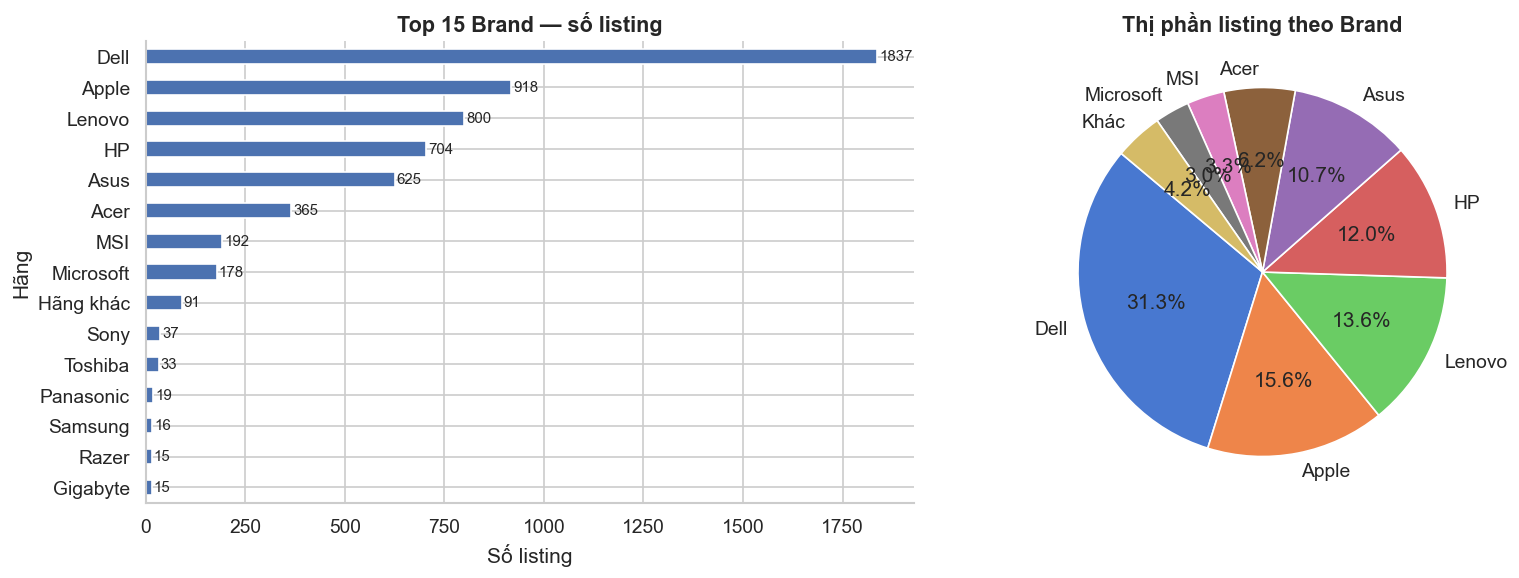

In [43]:
brand_counts = df['Hãng'].value_counts()
print(f"Số brand distinct: {brand_counts.nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top brands bar
top15 = brand_counts.head(15).sort_values()
top15.plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Top 15 Brand — số listing")
axes[0].set_xlabel("Số listing")
for i, v in enumerate(top15.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Pie: top 8 + Other
top8 = brand_counts.head(8)
other = brand_counts.iloc[8:].sum()
pie_data = pd.concat([top8, pd.Series({'Khác': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=sns.color_palette("muted", len(pie_data)), startangle=140)
axes[1].set_title("Thị phần listing theo Brand")

plt.tight_layout()
plt.show()

### Brand Distribution Overview

Phân bố listing theo brand cho thấy sự tập trung rất cao vào một số hãng lớn. Dell chiếm tỷ trọng lớn nhất (31%), vượt xa các brand còn lại. Nhóm tiếp theo gồm Apple (15.6%), Lenovo (13.6%) và HP (12%), tạo thành nhóm dẫn đầu và chiếm phần lớn tổng số listing.

Các hãng như Asus và Acer nằm ở mức trung bình, trong khi các brand còn lại có tỷ trọng khá nhỏ và phân tán. Điều này cho thấy dữ liệu có sự **mất cân bằng rõ rệt theo brand**, phản ánh đúng thực tế thị trường nhưng không đồng đều.

Insight quan trọng là các phân tích và mô hình sau này sẽ bị chi phối mạnh bởi các brand lớn, trong khi các brand nhỏ có thể không đủ dữ liệu để học được pattern ổn định. Vì vậy, khi đánh giá hoặc xây dựng model, cần lưu ý đến yếu tố bias theo brand.

In [83]:
# ── Brand hiếm ─────────────────────────────────────────────────────────────────
RARE_THRESH = 30 # xấp xỉ 0.5%
rare = brand_counts[brand_counts < RARE_THRESH]
print(f"Brand có < {RARE_THRESH} listing: {len(rare)}")
display(rare.to_frame().rename(columns={'Hãng': 'count'}))

Brand có < 30 listing: 8


,count
Hãng,
Panasonic,19
Samsung,16
Gigabyte,15
Razer,15
Huawei,9
Xiaomi,7
LG,4
Honor,1


### Handling Low-frequency Brands

Một số brand có số lượng listing rất thấp (dưới 0.5% dữ liệu khoảng 30), chẳng hạn như Huawei, Xiaomi, LG và Honor. Những nhóm này không đủ dữ liệu để học được các pattern ổn định trong mô hình.

Trong bước phân tích (EDA), các brand này vẫn được giữ nguyên để phản ánh đúng đặc điểm của thị trường. Tuy nhiên, trong bước modeling, nên gộp các brand có tần suất thấp vào một nhóm chung (ví dụ: `Other`) để giảm độ thưa dữ liệu và cải thiện khả năng học của mô hình.

Cách tiếp cận này giúp cân bằng giữa việc giữ insight từ dữ liệu gốc và đảm bảo hiệu quả khi xây dựng mô hình.

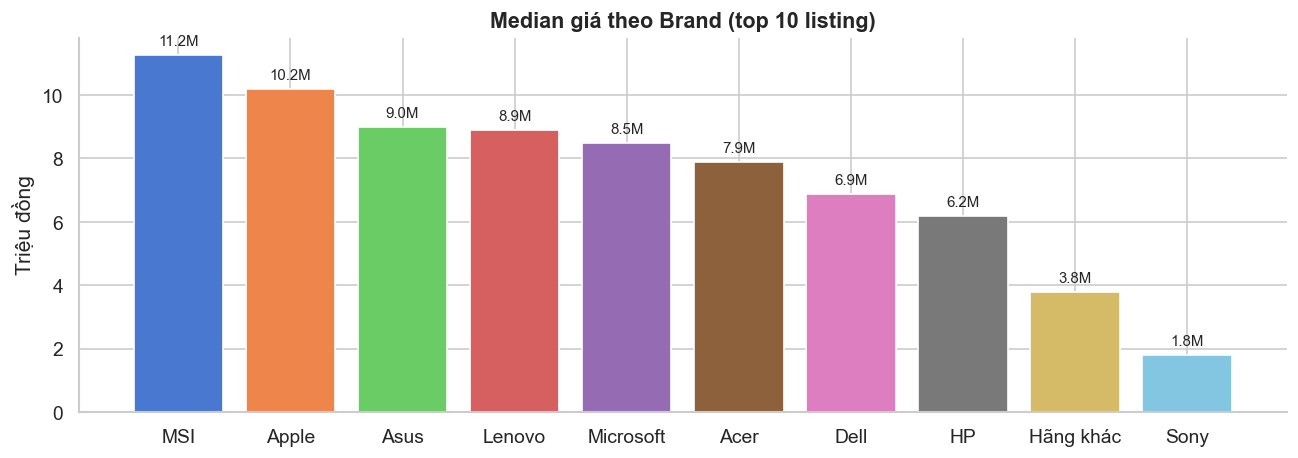

,Median (M),Mean (M),Count
Hãng,,,
MSI,11.2,12.3,192
Apple,10.2,13.7,918
Asus,9.0,11.2,625
Lenovo,8.9,11.3,800
Microsoft,8.5,9.9,178
Acer,7.9,9.7,365
Dell,6.9,8.3,1836
HP,6.2,7.4,704
Hãng khác,3.8,5.0,91


In [45]:
# ── Giá trung bình theo brand (top 10) ──────────────────────────────────────────
top10_brands = brand_counts.head(10).index
price_by_brand = (df[df['Hãng'].isin(top10_brands)]
                  .groupby('Hãng')['_price']
                  .agg(['median', 'mean', 'count'])
                  .sort_values('median', ascending=False))
price_by_brand.columns = ['Median (VNĐ)', 'Mean (VNĐ)', 'Count']

fig, ax = plt.subplots(figsize=(11, 4))
brands_sorted = price_by_brand.index.tolist()
medians_mil   = price_by_brand['Median (VNĐ)'] / 1e6
ax.bar(brands_sorted, medians_mil, color=COLORS[:len(brands_sorted)], edgecolor='white')
ax.set_title("Median giá theo Brand (top 10 listing)")
ax.set_ylabel("Triệu đồng")
ax.set_xlabel("")
for i, v in enumerate(medians_mil):
    ax.text(i, v + 0.3, f"{v:.1f}M", ha='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
display(price_by_brand.assign(**{'Median (M)': price_by_brand['Median (VNĐ)']/1e6,
                                   'Mean (M)':   price_by_brand['Mean (VNĐ)']/1e6})[['Median (M)', 'Mean (M)', 'Count']].round(1))


### Price Distribution by Brand

Giá median theo brand cho thấy sự phân hóa rõ rệt giữa các phân khúc. Các hãng như MSI (11.2M) và Apple (10.2M) nằm ở nhóm giá cao, phản ánh positioning ở phân khúc premium hoặc gaming. Nhóm trung gồm Asus, Lenovo, Microsoft và Acer (khoảng 7.9–9.0M), trong khi Dell và HP nằm ở mức thấp hơn (~6–7M), phù hợp với phân khúc phổ thông và doanh nghiệp.

Đáng chú ý, giá mean luôn cao hơn median ở hầu hết các brand, cho thấy phân phối giá bị lệch phải (right-skewed) do tồn tại một số sản phẩm giá cao kéo trung bình lên.

Insight quan trọng là **brand có ảnh hưởng mạnh đến giá**, không chỉ do cấu hình mà còn do định vị sản phẩm và thị trường mục tiêu. Vì vậy, `brand` là một feature quan trọng cần giữ trong mô hình để giải thích biến động của `price`.

In [84]:
# ── Brand vs spec (median) ─────────────────────────────────────────────────────
spec_by_brand = df.groupby('Hãng').agg({
    '_ram_struct_gb': 'median',
    '_storage_struct_gb': 'median'
}).rename(columns={
    '_ram_struct_gb': 'RAM_median',
    '_storage_struct_gb': 'Storage_median'
}).sort_values('RAM_median', ascending=False)

display(spec_by_brand.head(10))

,RAM_median,Storage_median
Hãng,,
Honor,32.0,1024.0
Gigabyte,16.0,512.0
Apple,16.0,256.0
Xiaomi,16.0,512.0
Razer,16.0,512.0
Lenovo,16.0,500.0
Huawei,16.0,512.0
Microsoft,16.0,256.0
MSI,16.0,512.0


### Brand vs Hardware Configuration

Cấu hình trung vị theo brand cho thấy phần lớn các hãng tập trung ở mức RAM phổ biến là 16GB và storage khoảng 256–512GB, phản ánh cấu hình tiêu chuẩn của laptop trên thị trường hiện tại.

Tuy nhiên, cần lưu ý rằng một số brand có giá trị median cao hơn (ví dụ Honor với 32GB RAM, 1TB storage) nhưng số lượng listing rất thấp, nên không mang tính đại diện và có thể bị ảnh hưởng bởi outlier.

Nhìn chung, sự khác biệt cấu hình giữa các brand không quá lớn, đặc biệt ở nhóm phổ biến, cho thấy giá không chỉ phụ thuộc vào phần cứng mà còn bị chi phối bởi brand và phân khúc sản phẩm.

In [85]:
# ── Missing rate theo brand ────────────────────────────────────────────────────
missing_by_brand = df.groupby('Hãng')[['RAM','Ổ cứng','Bộ vi xử lý']] \
    .apply(lambda x: x.isna().mean()) \
    .sort_values('RAM', ascending=False)

display(missing_by_brand.head(10))

,RAM,Ổ cứng,Bộ vi xử lý
Hãng,,,
LG,0.250000,0.250000,0.000000
Sony,0.135135,0.216216,0.162162
Samsung,0.125000,0.187500,0.000000
Hãng khác,0.120879,0.175824,0.098901
Apple,0.064270,0.092593,0.092593
Asus,0.044800,0.108800,0.051200
HP,0.041193,0.076705,0.025568
Microsoft,0.039326,0.061798,0.061798
Acer,0.035616,0.098630,0.035616


### Data Quality by Brand

Tỷ lệ missing cho thấy chất lượng dữ liệu không đồng đều giữa các brand. Một số hãng như LG, Sony và Samsung có tỷ lệ thiếu thông tin cao hơn, đặc biệt ở RAM và storage.

Tuy nhiên, cần lưu ý rằng các brand này có số lượng listing thấp, nên tỷ lệ missing dễ bị biến động và không mang tính đại diện. Ngược lại, các brand lớn như Dell, HP, Asus có tỷ lệ missing thấp và ổn định hơn, phản ánh dữ liệu đáng tin cậy hơn.

Insight quan trọng là chất lượng dữ liệu phụ thuộc vào brand và quy mô mẫu. Do đó, khi xử lý missing hoặc xây dựng mô hình, cần thận trọng với các brand có ít dữ liệu, vì chúng vừa thiếu thông tin vừa không đủ mẫu để học pattern ổn định.

In [89]:
# ── Price variance theo brand ──────────────────────────────────────────────────
price_stats = df.groupby('Hãng')['_price'].agg(['median','mean','std','count']) \
    .sort_values('median', ascending=False)

display(price_stats.head(10))

,median,mean,std,count
Hãng,,,,
Honor,21666666.0,2.166667e+07,NaN,1
Razer,16800000.0,2.070667e+07,1.965381e+07,15
Gigabyte,15500000.0,1.647533e+07,8.512745e+06,15
Xiaomi,12300000.0,1.138429e+07,2.666970e+06,7
MSI,11250000.0,1.225788e+07,6.295928e+06,192
Huawei,10490000.0,1.014222e+07,4.860043e+06,9
Apple,10200000.0,1.369390e+07,1.122104e+07,918
Asus,8999000.0,1.120438e+07,1.048186e+07,625
Lenovo,8900000.0,1.127108e+07,8.295360e+06,800


### Price Variability by Brand

Thống kê giá theo brand cho thấy sự khác biệt rõ rệt về cả mức giá và độ biến động. Một số brand như MSI và Apple có median cao, phản ánh phân khúc sản phẩm cao cấp hơn. Trong khi đó, các brand như Asus, Lenovo và Microsoft nằm ở mức trung bình.

Tuy nhiên, cần đặc biệt lưu ý rằng nhiều brand có số lượng listing rất thấp (ví dụ Honor, Xiaomi, Huawei), khiến các chỉ số như median, mean và đặc biệt là độ lệch chuẩn (std) không ổn định hoặc không có ý nghĩa đại diện. Trường hợp như Honor (count = 1) thậm chí không thể tính được độ biến động.

Ngoài ra, việc giá trung bình (mean) thường cao hơn median cho thấy phân phối giá bị lệch phải (right-skewed), do tồn tại các sản phẩm giá cao kéo trung bình lên.

Insight quan trọng là chỉ nên tin cậy các thống kê giá ở những brand có số lượng mẫu đủ lớn (như Apple, Dell, Lenovo, Asus). Các brand nhỏ vừa có dữ liệu ít vừa biến động cao, nên có thể gây nhiễu nếu đưa trực tiếp vào mô hình.

In [90]:
# ── Price segmentation ─────────────────────────────────────────────────────────
price_bins = pd.cut(
    df['_price'],
    bins=[0,5e6,10e6,20e6,1e9],
    labels=['low','mid','high','premium']
)

brand_segment = pd.crosstab(
    df['Hãng'],
    price_bins,
    normalize='index'
).sort_values('premium', ascending=False)

display(brand_segment.head(10))

_price,low,mid,high,premium
Hãng,,,,
Honor,0.000000,0.000000,0.000000,1.000000
Gigabyte,0.066667,0.200000,0.466667,0.266667
Apple,0.217865,0.276688,0.276688,0.228758
Lenovo,0.256250,0.297500,0.293750,0.152500
Razer,0.066667,0.133333,0.666667,0.133333
Asus,0.288000,0.272000,0.316800,0.123200
MSI,0.041667,0.380208,0.494792,0.083333
Acer,0.345205,0.260274,0.315068,0.079452
Microsoft,0.202247,0.432584,0.297753,0.067416


### Brand Positioning by Price Segment

Phân bố theo các mức giá cho thấy mỗi brand có định vị thị trường khác nhau. Một số hãng như MSI và Razer tập trung nhiều ở phân khúc high và premium, phản ánh dòng sản phẩm thiên về gaming hoặc hiệu năng cao.

Ngược lại, các brand như Dell, Acer và Asus có tỷ trọng lớn ở phân khúc low và mid, cho thấy sự tập trung vào thị trường phổ thông và đa dạng nhu cầu. Lenovo và Microsoft nằm ở mức cân bằng hơn giữa các phân khúc.

Cần lưu ý rằng một số brand có tỷ lệ premium cao bất thường (ví dụ Honor) nhưng số lượng mẫu rất nhỏ, nên không mang tính đại diện.

Insight quan trọng là `brand` có thể được xem như một proxy cho phân khúc giá, giúp mô hình hiểu rõ hơn về positioning sản phẩm thay vì chỉ dựa vào cấu hình.

### Brand Positioning by Price Segment

Phân bố theo các mức giá cho thấy mỗi brand có định vị thị trường khác nhau. Một số hãng như MSI và Razer tập trung nhiều ở phân khúc high và premium, phản ánh dòng sản phẩm thiên về gaming hoặc hiệu năng cao.

Ngược lại, các brand như Dell, Acer và Asus có tỷ trọng lớn ở phân khúc low và mid, cho thấy sự tập trung vào thị trường phổ thông và đa dạng nhu cầu. Lenovo và Microsoft nằm ở mức cân bằng hơn giữa các phân khúc.

Cần lưu ý rằng một số brand có tỷ lệ premium cao bất thường (ví dụ Honor) nhưng số lượng mẫu rất nhỏ, nên không mang tính đại diện.

Insight quan trọng là `brand` có thể được xem như một proxy cho phân khúc giá, giúp mô hình hiểu rõ hơn về positioning sản phẩm thay vì chỉ dựa vào cấu hình.## 8. Column: `Dòng máy`

Sub-category của brand. Nhiều giá trị distinct, có thể không nhất quán với `Hãng`.


Distinct dòng máy: 458
Missing:           0


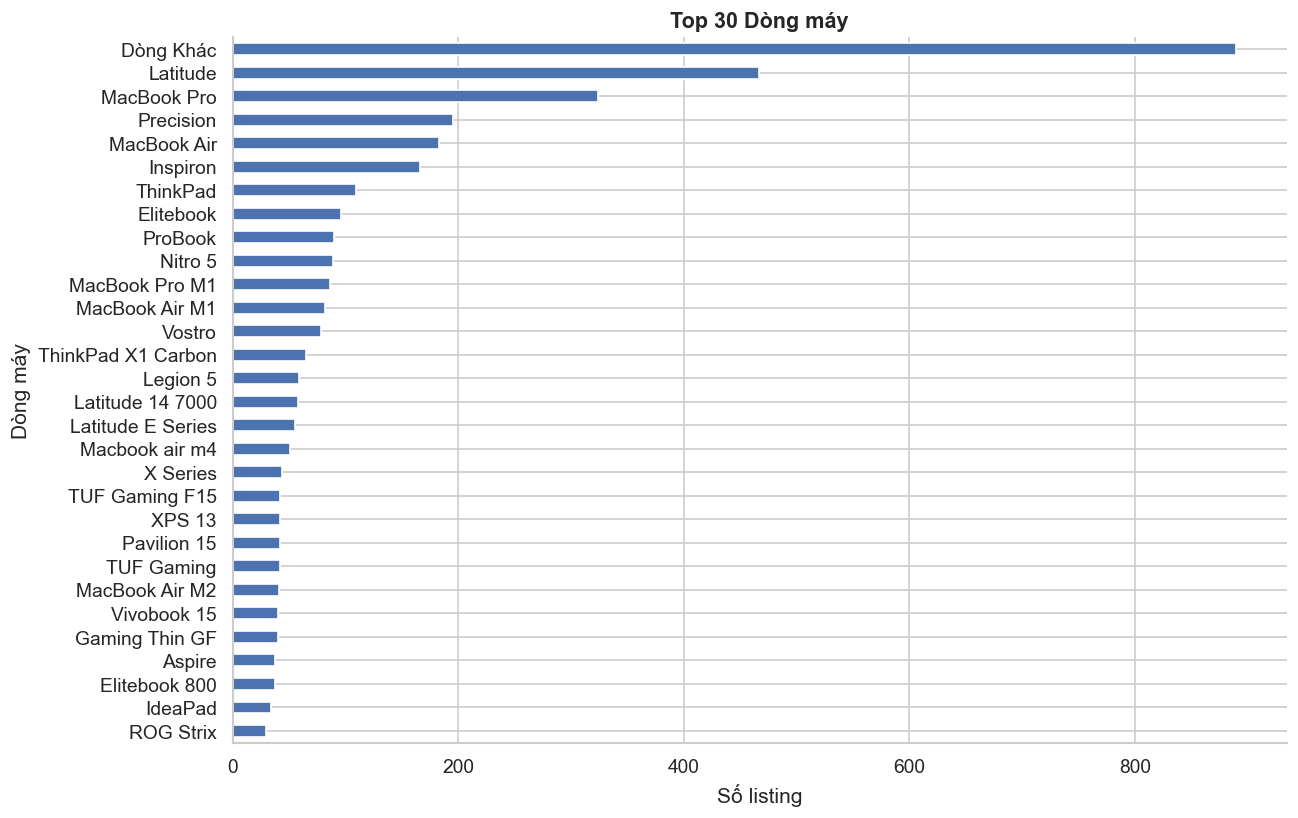

In [46]:
print(f"Distinct dòng máy: {df['Dòng máy'].nunique()}")
print(f"Missing:           {df['Dòng máy'].isna().sum()}")

top30 = df['Dòng máy'].value_counts().head(30)
fig, ax = plt.subplots(figsize=(11, 7))
top30.sort_values().plot(kind='barh', ax=ax, color=ACCENT)
ax.set_title("Top 30 Dòng máy")
ax.set_xlabel("Số listing")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


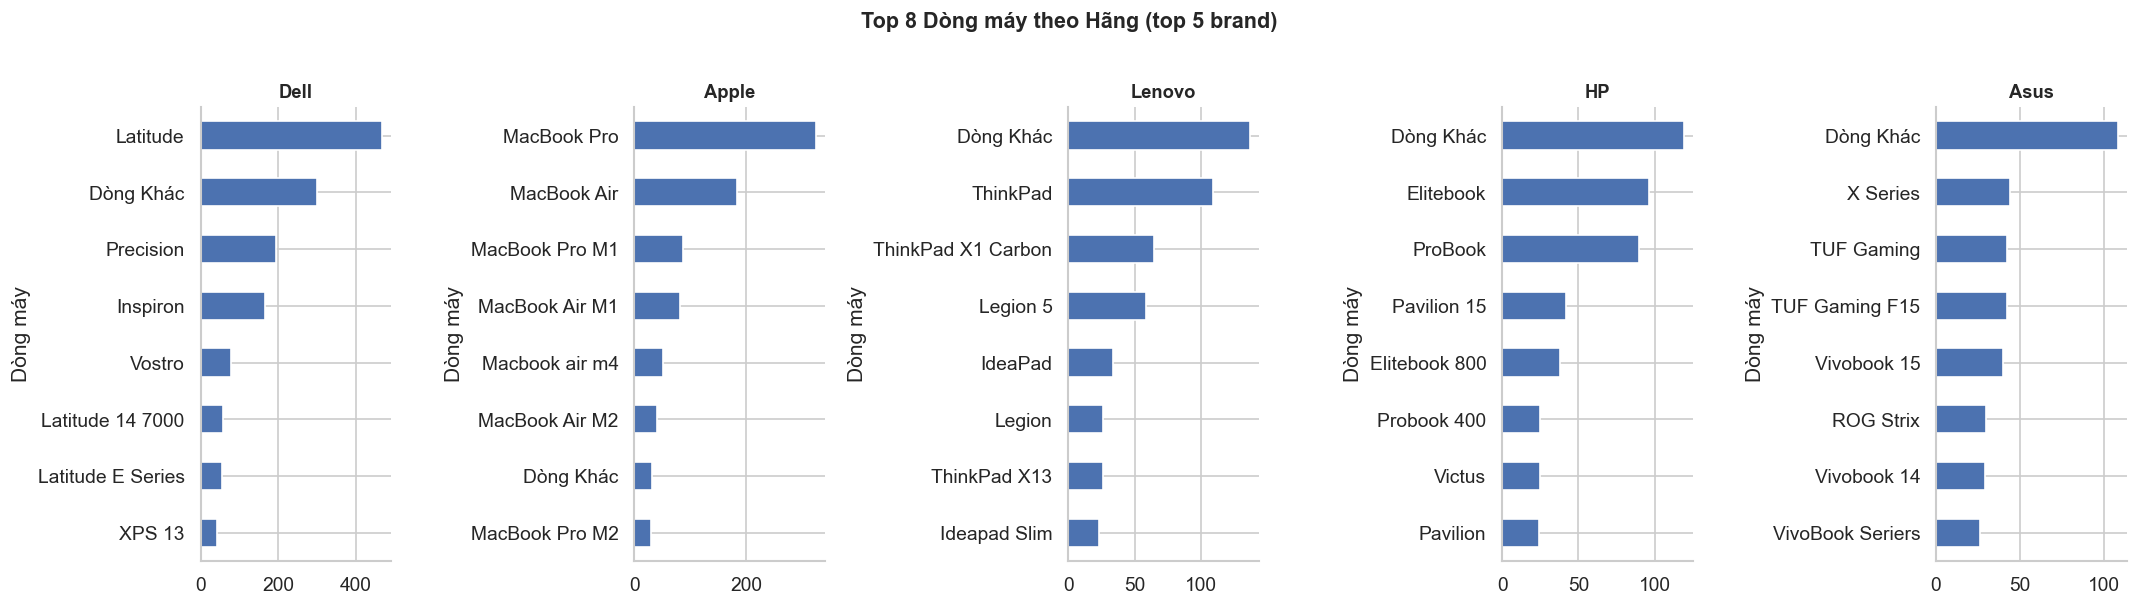

In [47]:
# ── Dòng máy theo từng Hãng (top 5 brand) ──────────────────────────────────────
top5_brands = df['Hãng'].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, brand in zip(axes, top5_brands):
    subset = df[df['Hãng'] == brand]['Dòng máy'].value_counts().head(8).sort_values()
    subset.plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title(brand, fontsize=11)
    ax.set_xlabel("")
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("Top 8 Dòng máy theo Hãng (top 5 brand)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. Column: `Tình trạng`

Quan trọng nhất về domain — ảnh hưởng trực tiếp đến giá. Kiểm tra categories và phân phối giá theo tình trạng.


In [48]:
cond_vc = df['Tình trạng'].value_counts(dropna=False)
print("Phân phối Tình trạng:")
display(cond_vc.to_frame())


Phân phối Tình trạng:


,count
Tình trạng,
Đã sử dụng (chưa sửa chữa),5594
Mới,182
Đã sử dụng (qua sửa chữa),90


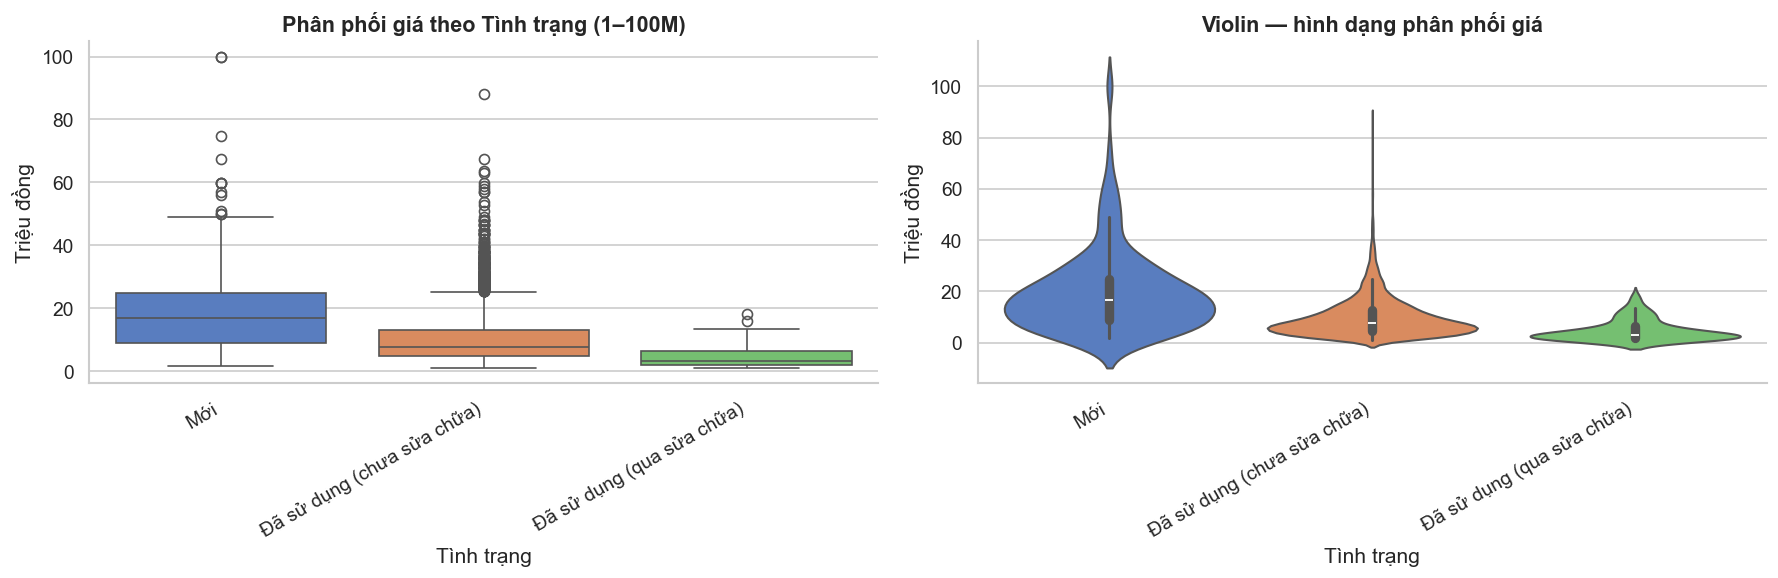

In [49]:
# ── Boxplot giá theo Tình trạng ─────────────────────────────────────────────────
plot_df = df[df['_price'].between(1e6, 100e6)].copy()
plot_df['price_mil'] = plot_df['_price'] / 1e6

order = (plot_df.groupby('Tình trạng')['price_mil']
         .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=plot_df, x='Tình trạng', y='price_mil',
            order=order, palette='muted', ax=axes[0])
axes[0].set_title("Phân phối giá theo Tình trạng (1–100M)")
axes[0].set_ylabel("Triệu đồng")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Violin — thấy rõ multimodal
sns.violinplot(data=plot_df, x='Tình trạng', y='price_mil',
               order=order, palette='muted', inner='box', ax=axes[1])
axes[1].set_title("Violin — hình dạng phân phối giá")
axes[1].set_ylabel("Triệu đồng")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [50]:
# ── Thống kê giá theo Tình trạng ────────────────────────────────────────────────
stats = (df.groupby('Tình trạng')['_price']
         .describe(percentiles=[.25, .5, .75])
         .assign(**{'Median (M)': lambda x: x['50%']/1e6,
                    'Mean (M)':   lambda x: x['mean']/1e6,
                    'P25 (M)':    lambda x: x['25%']/1e6,
                    'P75 (M)':    lambda x: x['75%']/1e6})
         [['count', 'Median (M)', 'Mean (M)', 'P25 (M)', 'P75 (M)']]
         .sort_values('Median (M)', ascending=False)
         .round(2))
display(stats)


,count,Median (M),Mean (M),P25 (M),P75 (M)
Tình trạng,,,,,
Mới,182.0,16.75,19.77,8.90,24.97
Đã sử dụng (chưa sửa chữa),5593.0,7.50,9.70,4.50,12.70
Đã sử dụng (qua sửa chữa),90.0,2.10,3.54,0.86,4.45


In [51]:
# ── Anomaly: 'Mới' nhưng giá < 3 triệu ────────────────────────────────────────
new_cheap = df[
    df['Tình trạng'].str.contains('Mới', na=False, case=False) &
    (df['_price'] < 3_000_000)
]
print(f"Laptop 'Mới' có giá < 3 triệu: {len(new_cheap)} rows")
if len(new_cheap) > 0:
    display(new_cheap[['title', 'Tình trạng', 'price', 'Hãng']].head(10))


Laptop 'Mới' có giá < 3 triệu: 7 rows


,title,Tình trạng,price,Hãng
26,"HP 15-da0056TU i3 8130U, 4GB, SSD 128GB, 15.6"" HD",Mới,2.300.000 đ,HP
766,Dell Latitude E7250 pin 4h,Mới,1.700.000 đ,Dell
1667,LAPTOP DELL I5 - MỚI 100% - GÓP NHANH,Mới,2.300.000 đ,Dell
3076,"Dell Vostro 3468 Core i3-6006U, RAM 4GB, SSD 120GB",Mới,1.800.000 đ,Dell
3298,Asus i3-8145U 8GB/256GB 14 inch fullhd,Mới,2.600.000 đ,Asus
3565,"Dell Inspiron 3467 Core i3-7020U, 4GB, SSD 128GB",Mới,1.900.000 đ,Dell
4695,Bán Macbook 12inch 2015 Ram 8G/512G màu Gold,Mới,2.450.000 đ,Apple


## 10. Column: `Chính sách bảo hành`

Category text phản ánh thời gian bảo hành còn lại — có thể encode thành số tháng.


,count
Chính sách bảo hành,
Bảo hành hãng,3005
3 tháng,897
1 tháng,617
Hết bảo hành,451
Còn bảo hành,387
4-6 tháng,286
7-12 tháng,134
>12 tháng,72
2 tháng,17


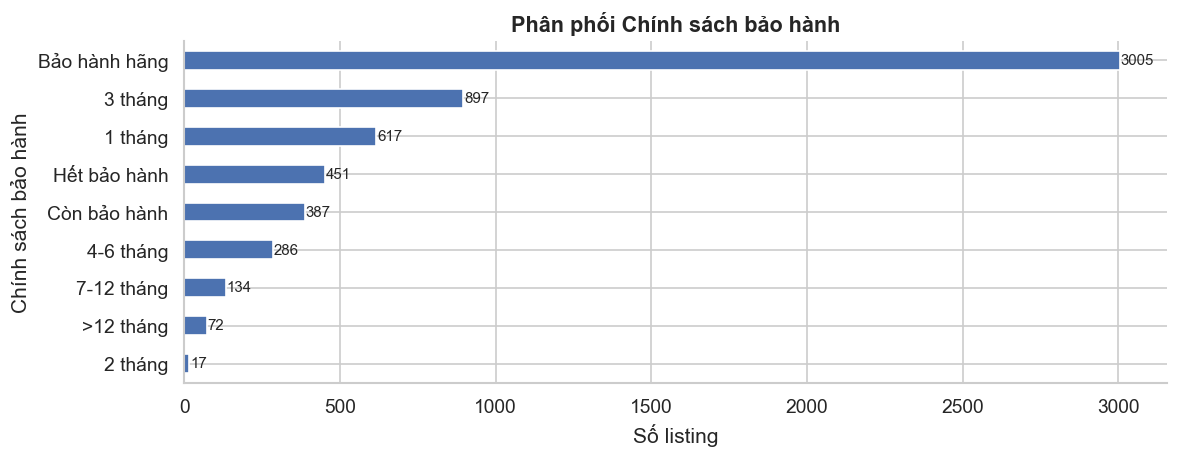

In [52]:
wty_vc = df['Chính sách bảo hành'].value_counts(dropna=False)
display(wty_vc.to_frame())

fig, ax = plt.subplots(figsize=(10, 4))
wty_vc.sort_values().plot(kind='barh', ax=ax, color=ACCENT)
ax.set_title("Phân phối Chính sách bảo hành")
ax.set_xlabel("Số listing")
for i, v in enumerate(wty_vc.sort_values().values):
    ax.text(v + 3, i, str(v), va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [53]:
# ── Mapping → số tháng ──────────────────────────────────────────────────────────
WARRANTY_MAP = {
    'Không bảo hành': 0,
    'Dưới 3 tháng':   1.5,
    '3 - 6 tháng':    4.5,
    '6 - 12 tháng':   9,
    'Trên 12 tháng':  18,   # ước tính
    'Bảo hành chính hãng': 12,
}

def map_warranty(val):
    if pd.isna(val): return np.nan
    # exact match trước
    for k, v in WARRANTY_MAP.items():
        if k.lower() in str(val).lower():
            return v
    nums = re.findall(r'\d+', str(val))
    return np.mean([int(n) for n in nums]) if nums else np.nan

df['warranty_est'] = df['Chính sách bảo hành'].apply(map_warranty)
mapping_result = (df.groupby('Chính sách bảo hành')['warranty_est']
                  .first().sort_values().reset_index())
mapping_result.columns = ['Category gốc', 'Số tháng ước tính']
display(mapping_result)

print(f"\nUnmapped (NaN): {df['warranty_est'].isna().sum()}")
df.drop(columns='warranty_est', inplace=True, errors='ignore')


,Category gốc,Số tháng ước tính
0,1 tháng,1.0
1,2 tháng,2.0
2,3 tháng,3.0
3,4-6 tháng,5.0
4,7-12 tháng,9.5
5,>12 tháng,12.0
6,Bảo hành hãng,NaN
7,Còn bảo hành,NaN
8,Hết bảo hành,NaN



Unmapped (NaN): 3843


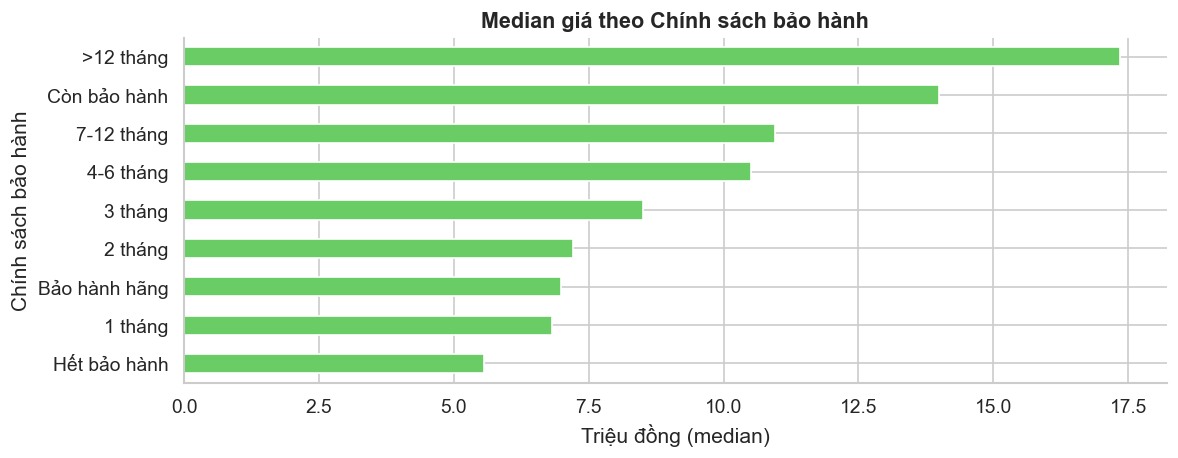

In [54]:
# ── Giá theo nhóm bảo hành ──────────────────────────────────────────────────────
wty_price = (df[df['_price'].between(1e6, 100e6)]
             .assign(price_mil=lambda x: x['_price']/1e6)
             .groupby('Chính sách bảo hành')['price_mil']
             .median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
wty_price.sort_values().plot(kind='barh', ax=ax, color=COLORS[2])
ax.set_title("Median giá theo Chính sách bảo hành")
ax.set_xlabel("Triệu đồng (median)")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## 11. Column: `Kích cỡ màn hình`

Missing ~18%. Giá trị là range text (`"13 - 14.9 inch"`) — cần extract midpoint số.


In [55]:
display(df['Kích cỡ màn hình'].value_counts(dropna=False).to_frame())


,count
Kích cỡ màn hình,
13 - 14.9 inch,2380
15 - 16.9 inch,2110
NaN,1037
11 - 12.9 inch,210
17 - 18.9 inch,103
9 - 10.9 inch,19
19 - 20.9 inch,3
< 9 inch,2
>= 21 inch,2


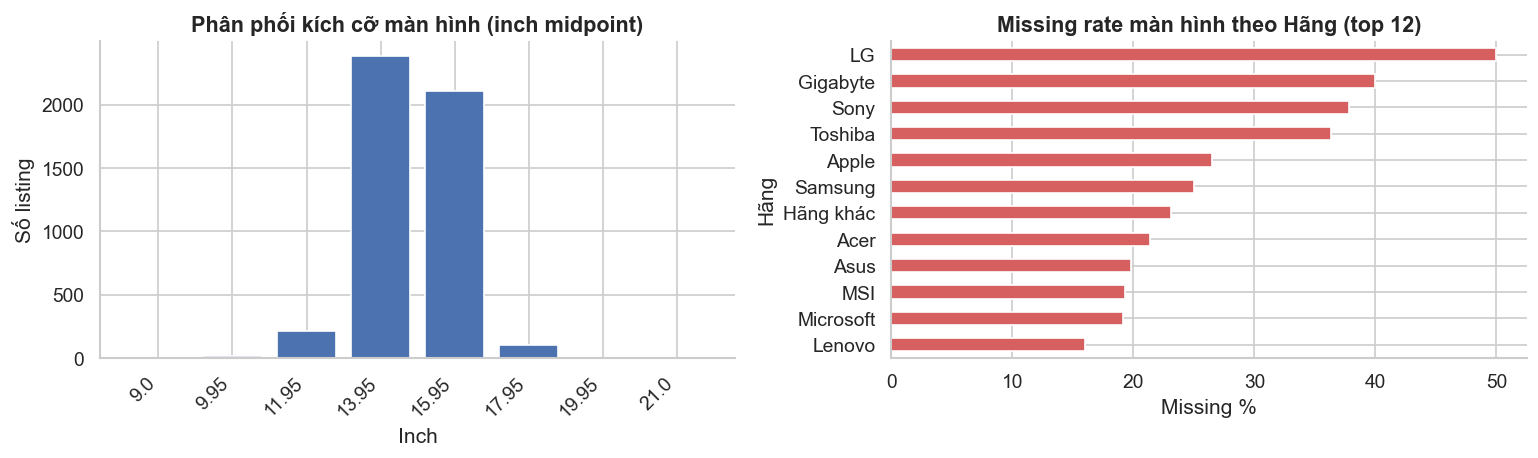

In [56]:
# ── Extract midpoint ────────────────────────────────────────────────────────────
def screen_midpoint(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'[\d\.]+', str(val))
    if len(nums) >= 2: return (float(nums[0]) + float(nums[1])) / 2
    elif len(nums) == 1: return float(nums[0])
    return np.nan

df['screen_mid'] = df['Kích cỡ màn hình'].apply(screen_midpoint)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Phân phối inch
vc_inch = df['screen_mid'].value_counts().sort_index()
axes[0].bar(vc_inch.index.astype(str), vc_inch.values, color=ACCENT, edgecolor='white')
axes[0].set_title("Phân phối kích cỡ màn hình (inch midpoint)")
axes[0].set_xlabel("Inch")
axes[0].set_ylabel("Số listing")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Missing rate theo hãng
miss_screen = (df.groupby('Hãng')['Kích cỡ màn hình']
               .apply(lambda x: x.isna().mean()*100)
               .sort_values(ascending=False).head(12).sort_values())
miss_screen.plot(kind='barh', ax=axes[1], color=COLORS[3])
axes[1].set_title("Missing rate màn hình theo Hãng (top 12)")
axes[1].set_xlabel("Missing %")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


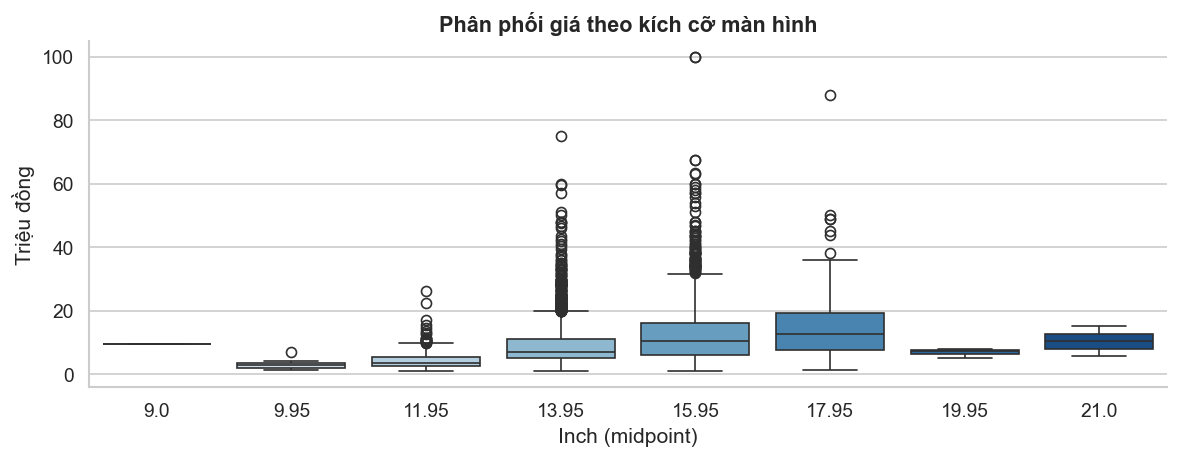

In [57]:
# ── Giá theo kích cỡ màn hình ───────────────────────────────────────────────────
plot_df = (df[df['_price'].between(1e6, 100e6) & df['screen_mid'].notna()]
           .assign(price_mil=lambda x: x['_price']/1e6))

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=plot_df, x='screen_mid', y='price_mil',
            order=sorted(plot_df['screen_mid'].unique()),
            palette='Blues', ax=ax)
ax.set_title("Phân phối giá theo kích cỡ màn hình")
ax.set_xlabel("Inch (midpoint)")
ax.set_ylabel("Triệu đồng")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns='screen_mid', inplace=True, errors='ignore')


## 12. Column: `Bộ vi xử lý`

Text tự do, missing ~4%. Cần chuẩn hóa brand, tier (i3/i5/i7/i9, Ryzen 3/5/7/9), và thế hệ Intel — ba chiều này ảnh hưởng mạnh đến giá.


In [58]:
print(f"Distinct CPU values: {df['Bộ vi xử lý'].nunique()}")
print(f"Missing: {df['Bộ vi xử lý'].isna().sum()}")
print("\nTop 30 giá trị phổ biến:")
display(df['Bộ vi xử lý'].value_counts().head(30).to_frame())


Distinct CPU values: 33
Missing: 249

Top 30 giá trị phổ biến:


,count
Bộ vi xử lý,
Intel Core i5,2327
Intel Core i7,1609
Intel Core i3,376
Ryzen 5,190
Ryzen 7,171
M1,134
Intel Core i9,132
Khác,113
Intel Core Ultra,112


In [59]:
# ── Phân loại CPU Brand ─────────────────────────────────────────────────────────
def cpu_brand(val):
    if pd.isna(val): return 'Missing'
    v = str(val).lower()
    if any(k in v for k in ['intel', 'core i', 'celeron', 'pentium', 'xeon', 'core ultra']): return 'Intel'
    if any(k in v for k in ['amd', 'ryzen', 'athlon']): return 'AMD'
    if any(k in v for k in ['apple', ' m1', ' m2', ' m3', 'm1 ', 'm2 ', 'm3 ']): return 'Apple Silicon'
    return 'Other/Unknown'

df['cpu_brand_t'] = df['Bộ vi xử lý'].apply(cpu_brand)

# ── Phân loại CPU Tier ──────────────────────────────────────────────────────────
def cpu_tier(val):
    if pd.isna(val): return 'Missing'          # FIX: 'Missing' không phải 'Unknown'
    v = str(val).lower()
    if 'core ultra' in v: return 'Core Ultra'
    for tier in ['i9', 'i7', 'i5', 'i3']:
        if tier in v: return tier.upper()
    for tier in ['ryzen 9', 'ryzen 7', 'ryzen 5', 'ryzen 3']:
        if tier in v: return tier.title()
    if 'apple' in v or re.search(r'\bm[123]\b', v): return 'Apple M-series'
    if any(k in v for k in ['celeron', 'pentium', 'athlon']): return 'Budget'
    return 'Other/Unknown'

df['cpu_tier_t'] = df['Bộ vi xử lý'].apply(cpu_tier)

# ── Phân loại Intel Gen ──────────────────────────────────────────────────────────
def intel_gen(val):
    if pd.isna(val): return None
    # iX-YYYYY: first 1–2 digits of model number = gen
    m = re.search(r'i\d[-\s](\d{1,2})\d{3}', str(val), re.IGNORECASE)
    if m: return int(m.group(1))
    # Core Ultra 7 165H style (gen 14+) — report as 14+
    if re.search(r'core ultra', str(val), re.I): return 14
    return None

df['intel_gen_t'] = df['Bộ vi xử lý'].apply(intel_gen)

print("CPU Brand phân phối:")
print(df['cpu_brand_t'].value_counts().to_string())
print("\nCPU Tier phân phối:")
print(df['cpu_tier_t'].value_counts().to_string())
print("\nIntel Gen phân phối (từ cột Bộ vi xử lý):")
print(df['intel_gen_t'].value_counts().sort_index().to_string())

CPU Brand phân phối:
cpu_brand_t
Intel            4662
AMD               469
Other/Unknown     399
Missing           249
Apple Silicon      87

CPU Tier phân phối:
cpu_tier_t
I5                2327
I7                1609
I3                 376
Apple M-series     299
Other/Unknown      269
Missing            249
Ryzen 5            190
Ryzen 7            171
I9                 132
Core Ultra         112
Budget              67
Ryzen 9             50
Ryzen 3             15

Intel Gen phân phối (từ cột Bộ vi xử lý):
intel_gen_t
14.0    112


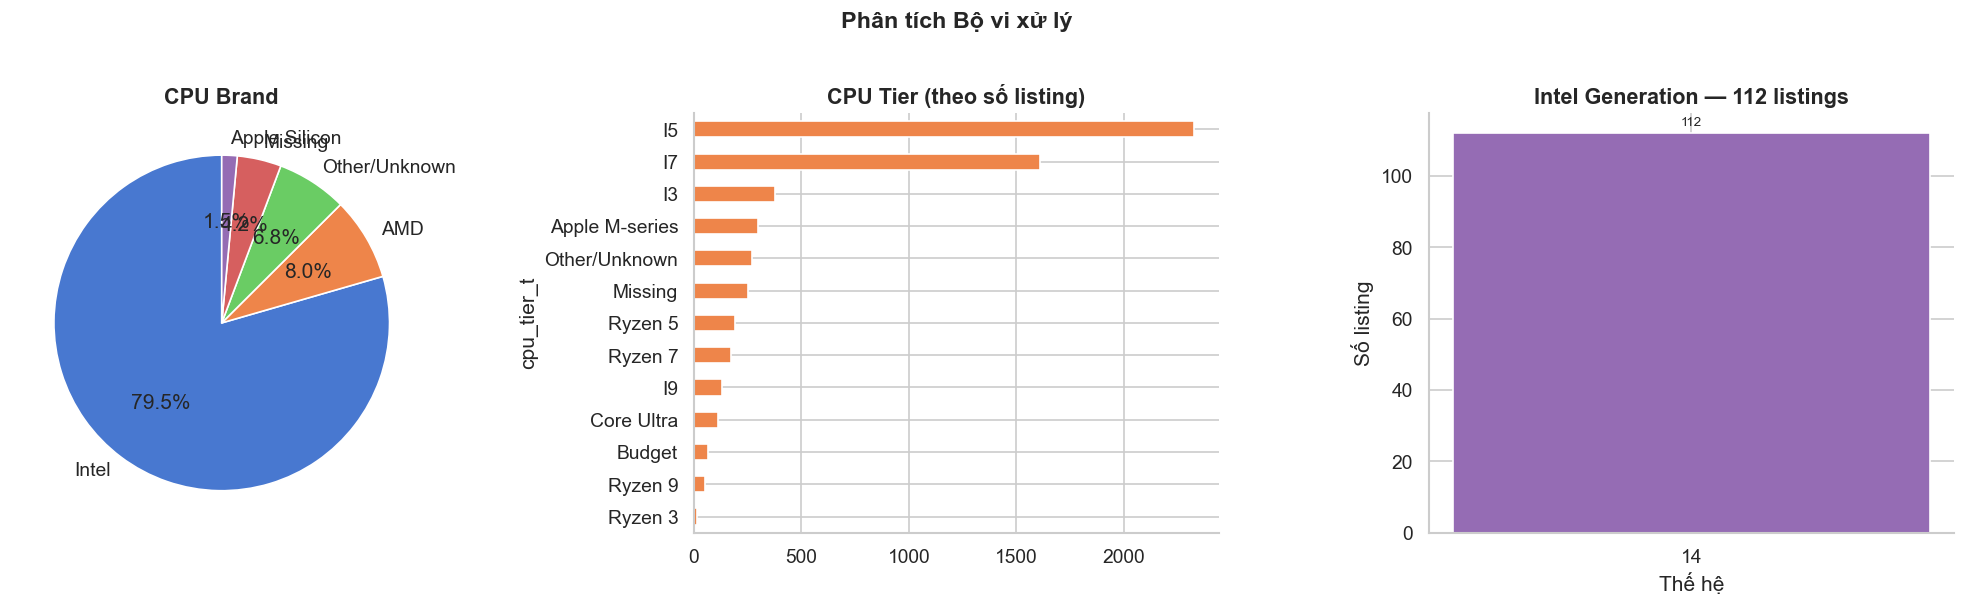

In [60]:
# ── Visualization CPU ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Brand pie
brand_vc = df['cpu_brand_t'].value_counts()
axes[0].pie(brand_vc.values, labels=brand_vc.index, autopct='%1.1f%%',
            colors=sns.color_palette("muted", len(brand_vc)), startangle=90)
axes[0].set_title("CPU Brand")

# Tier bar — FIX: dùng .index (unique values) thay vì .values để reindex đúng
tier_order = ['I9', 'I7', 'Core Ultra', 'I5', 'I3',
              'Ryzen 9', 'Ryzen 7', 'Ryzen 5', 'Ryzen 3',
              'Apple M-series', 'Budget', 'Missing', 'Other/Unknown']
existing_tiers = df['cpu_tier_t'].value_counts().index.tolist()
tier_vc = df['cpu_tier_t'].value_counts().reindex(
    [t for t in tier_order if t in existing_tiers], fill_value=0)
tier_vc.sort_values().plot(kind='barh', ax=axes[1], color=COLORS[1])
axes[1].set_title("CPU Tier (theo số listing)")

# Intel gen histogram — FIX: title không dùng literal {gen_number}
gen_vc = df['intel_gen_t'].dropna().astype(int).value_counts().sort_index()
axes[2].bar(gen_vc.index.astype(str), gen_vc.values, color=COLORS[4], edgecolor='white')
axes[2].set_title(f"Intel Generation — {gen_vc.sum():,} listings")  # FIX: f-string thực
axes[2].set_xlabel("Thế hệ")
axes[2].set_ylabel("Số listing")
for i, v in enumerate(gen_vc.values):
    axes[2].text(i, v + 2, str(v), ha='center', fontsize=8)

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.suptitle("Phân tích Bộ vi xử lý", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

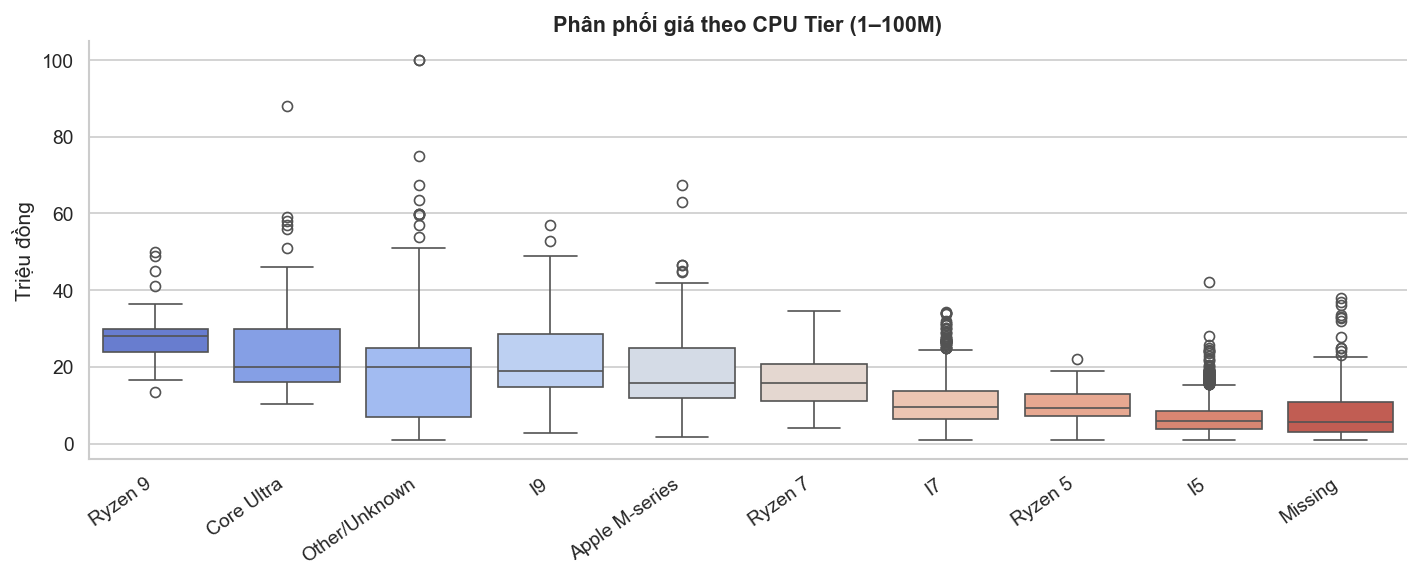

In [61]:
# ── Giá theo CPU Tier ────────────────────────────────────────────────────────────
price_cpu = (df[df['_price'].between(1e6, 100e6)]
             .assign(price_mil=lambda x: x['_price']/1e6))

tier_order_plot = (price_cpu.groupby('cpu_tier_t')['price_mil']
                   .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=price_cpu[price_cpu['cpu_tier_t'].isin(tier_order_plot[:10])],
            x='cpu_tier_t', y='price_mil',
            order=tier_order_plot[:10], palette='coolwarm', ax=ax)
ax.set_title("Phân phối giá theo CPU Tier (1–100M)")
ax.set_ylabel("Triệu đồng")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns=['cpu_brand_t', 'cpu_tier_t', 'intel_gen_t'], inplace=True, errors='ignore')


## 13. Column: `RAM`

Missing ~4%. Text dạng `"8 GB"` — cần extract số GB.


In [62]:
display(df['RAM'].value_counts(dropna=False).to_frame())


,count
RAM,
8 GB,2454
16 GB,2369
4 GB,388
32 GB,316
NaN,239
6 GB,34
2 GB,25
64 GB,16
<1 GB,7


In [63]:
# ── Extract GB ──────────────────────────────────────────────────────────────────
df['ram_gb'] = pd.to_numeric(df['RAM'].str.extract(r'(\d+)')[0], errors='coerce')

# Giá trị bất thường
out_ram = df[df['ram_gb'].notna() & ((df['ram_gb'] < 4) | (df['ram_gb'] > 128))]
print(f"RAM bất thường (< 4 GB hoặc > 128 GB): {len(out_ram)} rows")
if len(out_ram) > 0:
    display(out_ram[['RAM', 'ram_gb', 'title']].head(10))


RAM bất thường (< 4 GB hoặc > 128 GB): 32 rows


,RAM,ram_gb,title
87,<1 GB,1.0,Macbook pro M3 PRO 14' Spaceblack Ram 36/Ssd 512GB
195,<1 GB,1.0,MacBook Pro M5 PRO 16' 24GB/1TB NewSeal
340,<1 GB,1.0,Macbook Pro M5 PRO 14' 24GB/2TB Newseal 20Gpu
551,2 GB,2.0,Asus E502S Intel N3050 15 inch 2GB Đã sử dụng
782,2 GB,2.0,HP Pavilion Intel Core2 Duo T9400
959,2 GB,2.0,Acer Aspire 4730 Core 2 Duo 14 inch
1209,2 GB,2.0,Dư thanh lý laptop hp11 inch
1347,<1 GB,1.0,Macbook Pro M4 MAX 16' 36GB/1TB Đẹp keng
1376,2 GB,2.0,Asus X453MA Pentium N3540
1643,2 GB,2.0,Máy tính xách tay Đa màu


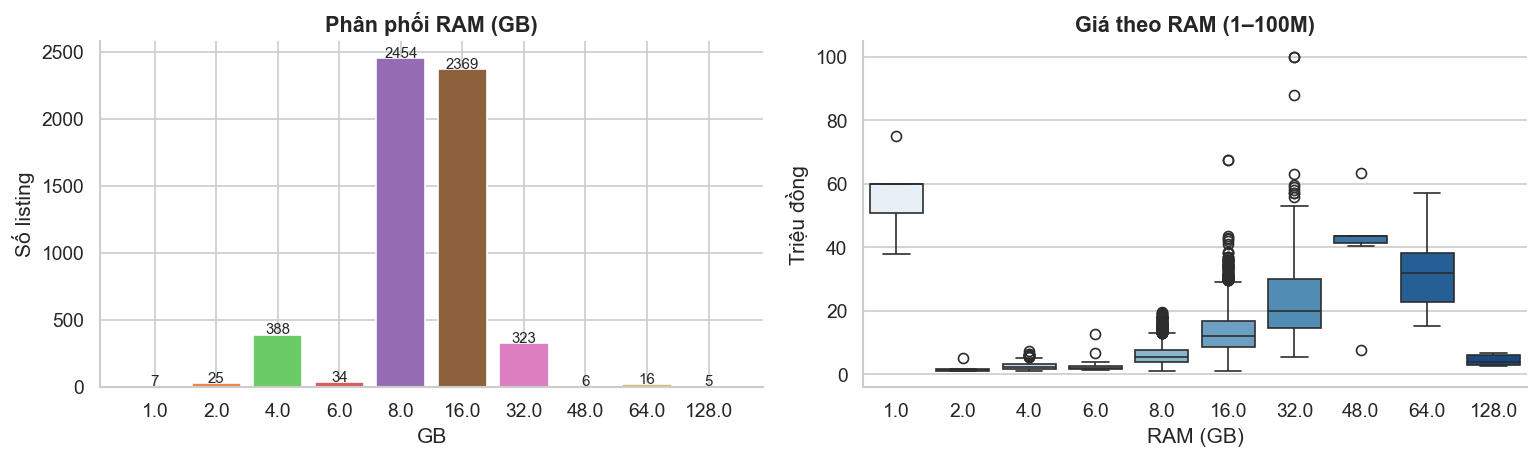

In [64]:
# ── Visualization RAM ───────────────────────────────────────────────────────────
ram_vc = df['ram_gb'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ram_vc.index.astype(str), ram_vc.values,
            color=COLORS[:len(ram_vc)], edgecolor='white')
axes[0].set_title("Phân phối RAM (GB)")
axes[0].set_xlabel("GB")
axes[0].set_ylabel("Số listing")
for i, (x, v) in enumerate(zip(ram_vc.index.astype(str), ram_vc.values)):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Giá theo RAM
price_ram = (df[df['_price'].between(1e6, 100e6) & df['ram_gb'].notna()]
             .assign(price_mil=lambda x: x['_price']/1e6))
ram_order = sorted(price_ram['ram_gb'].unique())
sns.boxplot(data=price_ram, x='ram_gb', y='price_mil',
            order=ram_order, palette='Blues', ax=axes[1])
axes[1].set_title("Giá theo RAM (1–100M)")
axes[1].set_xlabel("RAM (GB)")
axes[1].set_ylabel("Triệu đồng")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns='ram_gb', inplace=True, errors='ignore')


## 14. Column: `Card màn hình`

Missing cao nhất (~24%). Missing **có thể mang nghĩa**: máy dùng integrated GPU, không có dedicated card.  
Phân loại 3 tier: Dedicated → Integrated → Unknown/Missing.


In [65]:
print(f"Distinct GPU values: {df['Card màn hình'].nunique()}")
print("\nTop 30:")
display(df['Card màn hình'].value_counts().head(30).to_frame())


Distinct GPU values: 4

Top 30:


,count
Card màn hình,
Onboard,2565
NVIDIA,1458
Khác,247
AMD,175


In [66]:
# ── Phân loại GPU ──────────────────────────────────────────────────────────────
def gpu_tier(val):
    if pd.isna(val): return 'Missing'
    v = str(val)
    # FIX: RTX 3060/3070/4060... pattern: RTX + (3|4) + 3-digit model
    if re.search(r'RTX\s?[34]\d{3}', v, re.I): return 'Dedicated — High (RTX 30/40)'
    # RTX 20 series + GTX 1660/1650
    if re.search(r'RTX\s?2\d{3}|GTX\s?16[56]0', v, re.I): return 'Dedicated — Mid (RTX 20 / GTX 16)'
    # Other dedicated: GTX 10xx, Quadro, AMD RX
    if re.search(r'GTX|Quadro|GeForce|NVIDIA|Radeon\s?RX|RX\s?\d{3,4}|Radeon\s?Pro', v, re.I): return 'Dedicated — Other/Entry'
    # Integrated Intel
    if re.search(r'Intel|Iris|UHD|HD\s?Graphics|integrated|tích hợp', v, re.I): return 'Integrated — Intel'
    # Integrated AMD Radeon (no RX suffix → integrated)
    if re.search(r'Radeon', v, re.I) and not re.search(r'RX\s?\d', v, re.I): return 'Integrated — AMD Radeon'
    return 'Unclear'

df['gpu_tier'] = df['Card màn hình'].apply(gpu_tier)
gpu_vc = df['gpu_tier'].value_counts()
print(gpu_vc.to_string())

# Spot-check: xem thử các giá trị thực tế trong mỗi tier
for tier in gpu_vc.index[:4]:
    samples = df[df['gpu_tier'] == tier]['Card màn hình'].dropna().value_counts().head(3).index.tolist()
    print(f"  {tier}: {samples}")

gpu_tier
Unclear                    2987
Dedicated — Other/Entry    1458
Missing                    1421
  Unclear: ['Onboard', 'Khác', 'AMD']
  Dedicated — Other/Entry: ['NVIDIA']
  Missing: []


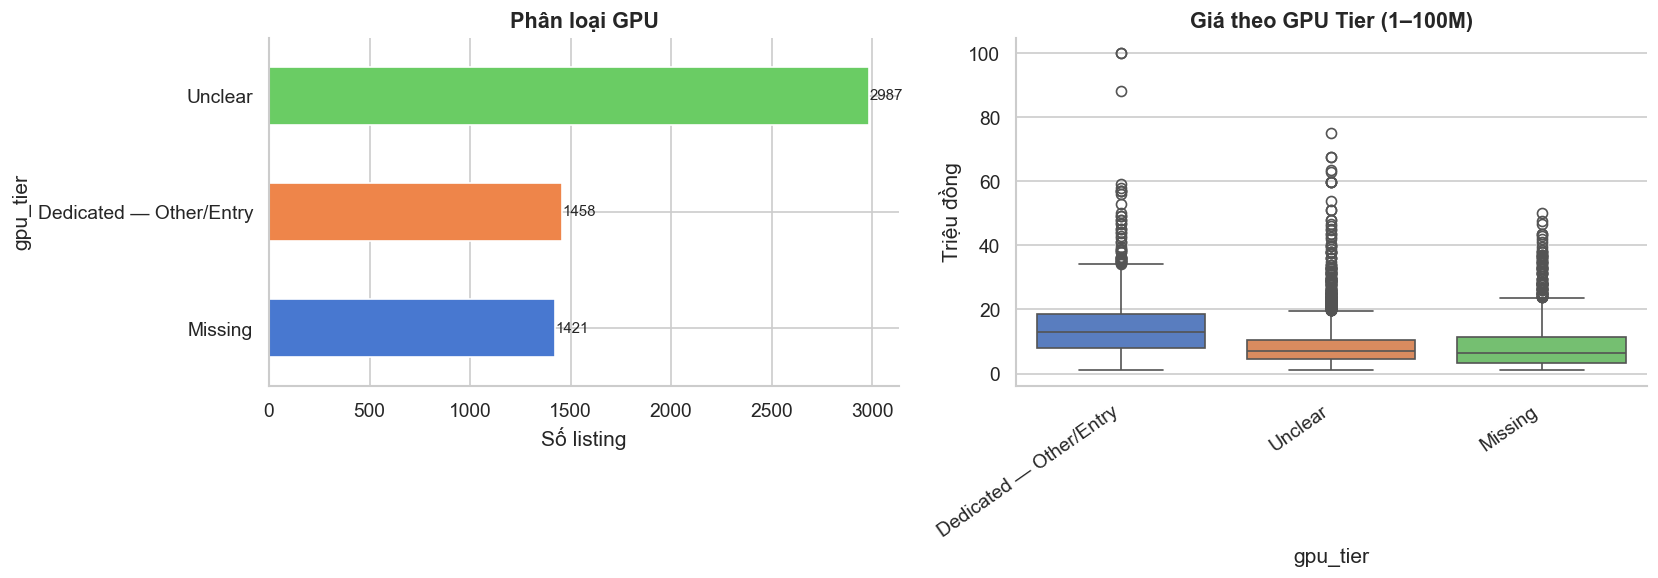

In [67]:
# ── Visualization GPU ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count bar
gpu_vc.sort_values().plot(kind='barh', ax=axes[0],
                          color=sns.color_palette("muted", len(gpu_vc)))
axes[0].set_title("Phân loại GPU")
axes[0].set_xlabel("Số listing")
for i, v in enumerate(gpu_vc.sort_values().values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=9)

# Giá theo GPU tier
price_gpu = (df[df['_price'].between(1e6, 100e6)]
             .assign(price_mil=lambda x: x['_price']/1e6))
order_gpu = (price_gpu.groupby('gpu_tier')['price_mil']
             .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=price_gpu, x='gpu_tier', y='price_mil',
            order=order_gpu, palette='muted', ax=axes[1])
axes[1].set_title("Giá theo GPU Tier (1–100M)")
axes[1].set_ylabel("Triệu đồng")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


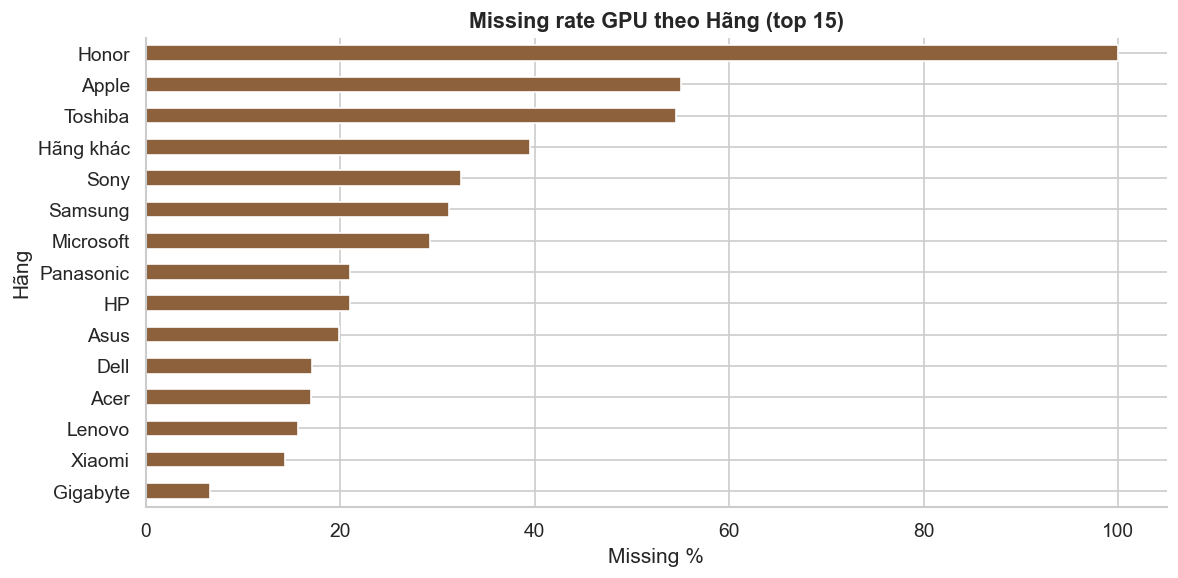


Laptop gaming (title/dòng máy) mà thiếu GPU: 24


,title,Dòng máy,Card màn hình,price
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,Inspiron,NaN,2.900.000 đ
435,Laptop Asus TUF Gaming F15 FX506HC 15.6 inch 16GB,TUF Gaming F15,NaN,11.000.000 đ
667,Máy chơi game ROG Ally Z1 Extreme 1TB 99%,Dòng Khác,NaN,13.000.000 đ
1010,Acer Nitro 5 i5 9300h 16GB Đã dùng,Nitro 5,NaN,5.000.000 đ
1200,⚡ ACER NITRO V 15 - I7-13620H | RTX 4060,Aspire Nitro,NaN,22.200.000 đ
1458,ASUS TUF Gaming FX505GD i5-8300H 16GB,TUF Gaming,NaN,6.850.000 đ
1650,HP Victus Gaming i5-12450H 16GB/512GB,Victus,NaN,12.000.000 đ
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,Gaming G15,NaN,24.000.000 đ


In [68]:
# ── Missing GPU có hệ thống theo Hãng? ──────────────────────────────────────────
gpu_miss_rate = (df.assign(gpu_missing=df['Card màn hình'].isna())
                 .groupby('Hãng')['gpu_missing']
                 .mean()
                 .sort_values(ascending=False)
                 .head(15) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
gpu_miss_rate.sort_values().plot(kind='barh', ax=ax, color=COLORS[5])
ax.set_title("Missing rate GPU theo Hãng (top 15)")
ax.set_xlabel("Missing %")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Gaming laptop mà thiếu GPU?
gaming_pat = r'(ROG|TUF|Gaming|Legion|Predator|Nitro|Katana|Raider|Titan)'
is_gaming = (df['title'].str.contains(gaming_pat, case=False, na=False) |
             df['Dòng máy'].str.contains(gaming_pat, case=False, na=False))
gaming_no_gpu = is_gaming & df['Card màn hình'].isna()
print(f"\nLaptop gaming (title/dòng máy) mà thiếu GPU: {gaming_no_gpu.sum()}")
if gaming_no_gpu.sum() > 0:
    display(df[gaming_no_gpu][['title', 'Dòng máy', 'Card màn hình', 'price']].head(8))

df.drop(columns='gpu_tier', inplace=True, errors='ignore')


## 15. Column: `Ổ cứng` & `Loại ổ cứng`

Hai cột liên quan chặt: dung lượng và loại. Missing lần lượt ~8% và ~12%. Kiểm tra inconsistency và convert về GB.


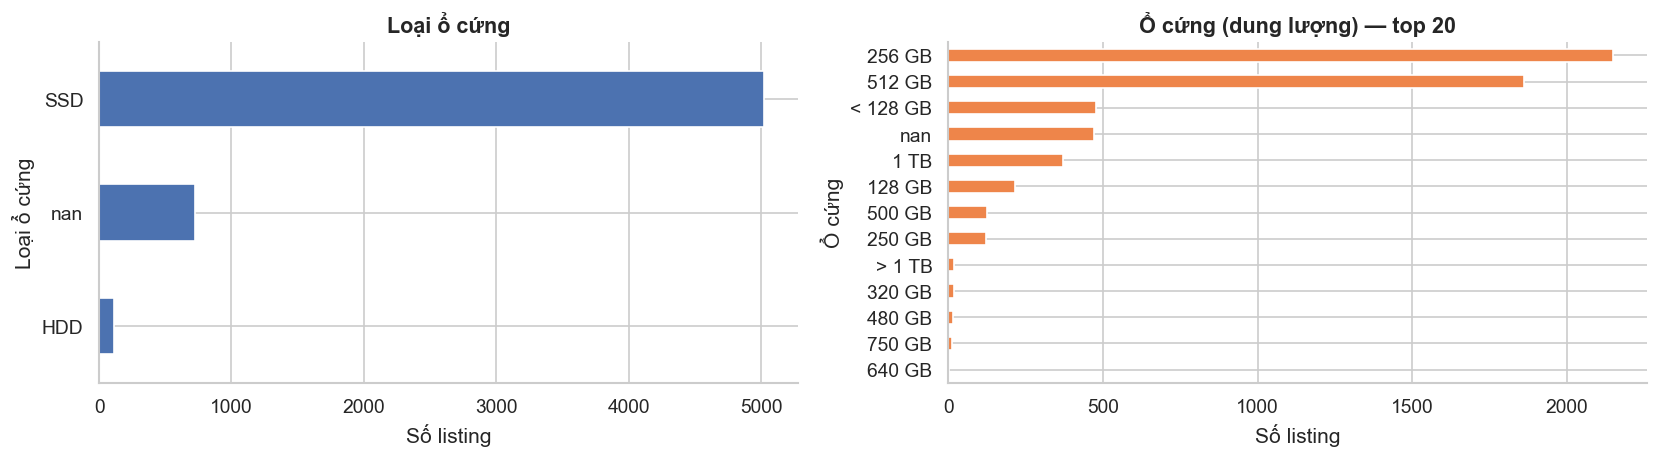

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loại ổ cứng
loai_vc = df['Loại ổ cứng'].value_counts(dropna=False)
loai_vc_plot = loai_vc[:10].sort_values()
loai_vc_plot.plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Loại ổ cứng")
axes[0].set_xlabel("Số listing")

# Ổ cứng (dung lượng)
ocung_vc = df['Ổ cứng'].value_counts(dropna=False).head(20).sort_values()
ocung_vc.plot(kind='barh', ax=axes[1], color=COLORS[1])
axes[1].set_title("Ổ cứng (dung lượng) — top 20")
axes[1].set_xlabel("Số listing")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [70]:
# ── Inconsistency ────────────────────────────────────────────────────────────────
case1 = df['Loại ổ cứng'].notna() & df['Ổ cứng'].isna()
case2 = df['Loại ổ cứng'].isna() & df['Ổ cứng'].notna()
both_missing = df['Loại ổ cứng'].isna() & df['Ổ cứng'].isna()
print(f"Có Loại nhưng không có Dung lượng: {case1.sum()}")
print(f"Có Dung lượng nhưng không có Loại:  {case2.sum()}")
print(f"Cả hai đều missing:                  {both_missing.sum()}")


Có Loại nhưng không có Dung lượng: 128
Có Dung lượng nhưng không có Loại:  384
Cả hai đều missing:                  342


In [71]:
# ── Convert về GB (parse_storage_gb đã định nghĩa ở Setup) ────────────────────
df['storage_gb'] = df['Ổ cứng'].apply(parse_storage_gb)
storage_vc = df['storage_gb'].value_counts().sort_index()
print("Phân phối dung lượng ổ cứng (GB):")
display(storage_vc.to_frame().rename(columns={'storage_gb': 'count'}))

# Giá trị bất thường
out_stor = df[df['storage_gb'].notna() & ((df['storage_gb'] < 32) | (df['storage_gb'] > 4096))]
print(f"\nStorage bất thường (< 32 GB hoặc > 4 TB): {len(out_stor)} rows")
if len(out_stor) > 0:
    display(out_stor[['Ổ cứng', 'storage_gb', 'title']].head(5))

Phân phối dung lượng ổ cứng (GB):


,count
storage_gb,
128.0,695
250.0,122
256.0,2150
320.0,20
480.0,15
500.0,124
512.0,1861
640.0,4
750.0,13



Storage bất thường (< 32 GB hoặc > 4 TB): 0 rows


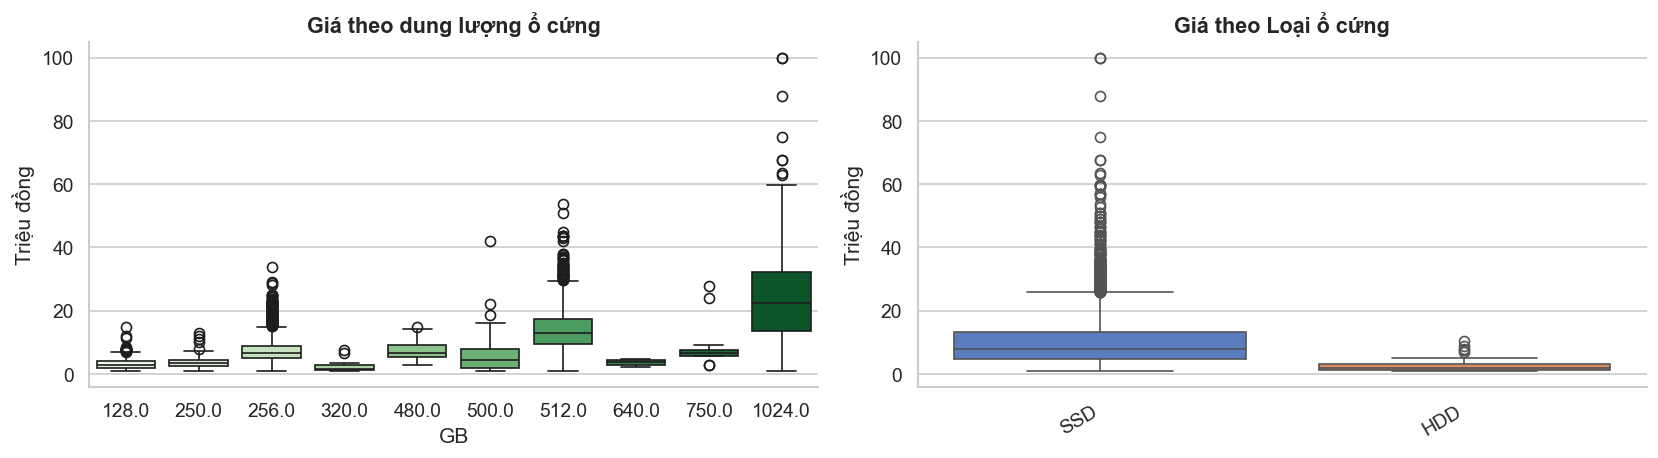

In [72]:
# ── Giá theo storage + loại ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Giá theo GB
price_storage = (df[df['_price'].between(1e6, 100e6) & df['storage_gb'].notna()]
                 .assign(price_mil=lambda x: x['_price']/1e6))
gb_order = sorted(price_storage['storage_gb'].unique())
sns.boxplot(data=price_storage, x='storage_gb', y='price_mil',
            order=gb_order, palette='Greens', ax=axes[0])
axes[0].set_title("Giá theo dung lượng ổ cứng")
axes[0].set_xlabel("GB")
axes[0].set_ylabel("Triệu đồng")

# Giá theo loại ổ cứng
price_ssd = (df[df['_price'].between(1e6, 100e6) & df['Loại ổ cứng'].notna()]
             .assign(price_mil=lambda x: x['_price']/1e6))
ssd_order = (price_ssd.groupby('Loại ổ cứng')['price_mil']
             .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=price_ssd, x='Loại ổ cứng', y='price_mil',
            order=ssd_order, palette='muted', ax=axes[1])
axes[1].set_title("Giá theo Loại ổ cứng")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylabel("Triệu đồng")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

df.drop(columns='storage_gb', inplace=True, errors='ignore')


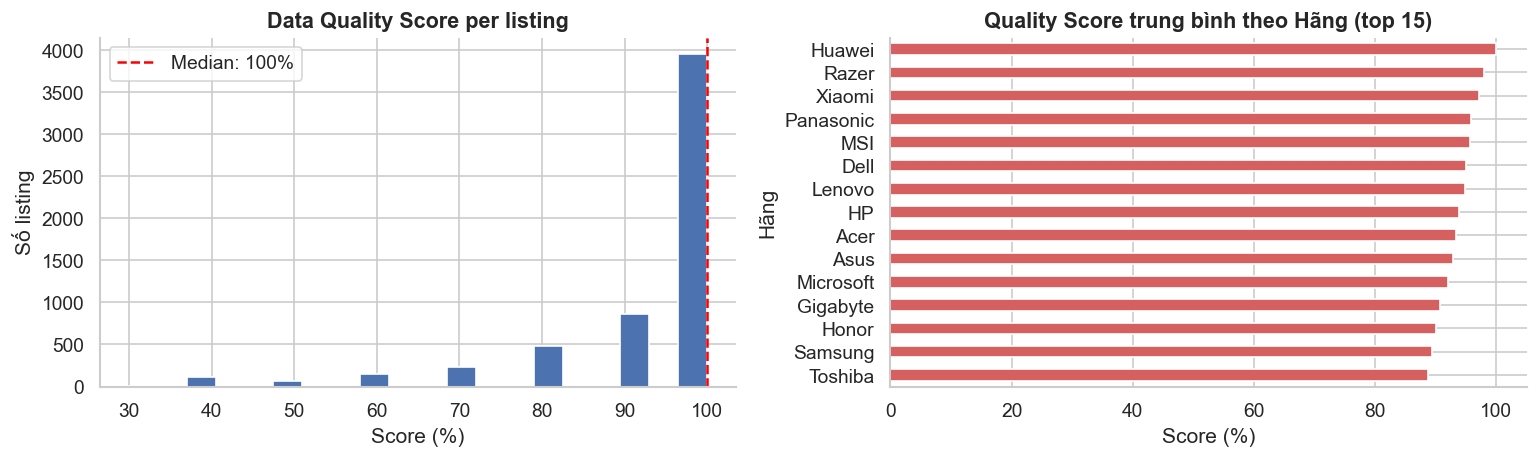

Median quality score: 100.0%
Listing score = 100% (đầy đủ mọi cột): 3,956 (67.4%)
Listing score < 50% (thiếu nhiều): 117 (2.0%)


In [73]:
# ── Data Quality Score per listing ─────────────────────────────────────────────
# Mỗi cột spec có giá trị = 1 điểm; thiếu = 0; scale 0–100%
SCORE_COLS = {
    'price':             'price',          # có giá parse được
    'Hãng':              'Hãng',
    'Tình trạng':        'Tình trạng',
    'Kích cỡ màn hình':  'Kích cỡ màn hình',
    'Bộ vi xử lý':       'Bộ vi xử lý',
    'RAM':               'RAM',
    'Card màn hình':     'Card màn hình',
    'Ổ cứng':            'Ổ cứng',
    'Loại ổ cứng':       'Loại ổ cứng',
    'Xuất xứ':           'Xuất xứ',
}

score_df = pd.DataFrame({k: df[v].notna() for k, v in SCORE_COLS.items()})
score_df['price_valid'] = df['_price'].notna()     # thay thế col price bằng parsed version
score_df = score_df.drop(columns='price')

df['quality_score'] = score_df.mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['quality_score'], bins=20, color=ACCENT, edgecolor='white')
axes[0].axvline(df['quality_score'].median(), color='red', linestyle='--',
                label=f"Median: {df['quality_score'].median():.0f}%")
axes[0].set_title("Data Quality Score per listing")
axes[0].set_xlabel("Score (%)")
axes[0].set_ylabel("Số listing")
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Score theo brand
brand_score = (df.groupby('Hãng')['quality_score'].mean()
               .sort_values(ascending=False).head(15).sort_values())
brand_score.plot(kind='barh', ax=axes[1], color=COLORS[3])
axes[1].set_title("Quality Score trung bình theo Hãng (top 15)")
axes[1].set_xlabel("Score (%)")
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median quality score: {df['quality_score'].median():.1f}%")
print(f"Listing score = 100% (đầy đủ mọi cột): {(df['quality_score'] == 100).sum():,} ({(df['quality_score']==100).mean()*100:.1f}%)")
print(f"Listing score < 50% (thiếu nhiều): {(df['quality_score'] < 50).sum():,} ({(df['quality_score']<50).mean()*100:.1f}%)")
df.drop(columns='quality_score', inplace=True, errors='ignore')

## 16. Column: `Xuất xứ` & `Thông tin sử dụng`

`Xuất xứ` — categorical, kiểm tra cardinality và liên quan đến giá.  
`Thông tin sử dụng` — text tự do, kiểm tra tiềm năng extract.


,count
Xuất xứ,
Đang cập nhật,3536
Mỹ,1101
Việt Nam,556
Nhật Bản,388
Nước khác,114
Trung Quốc,94
Đài Loan,61
Hàn Quốc,13
Thái Lan,2


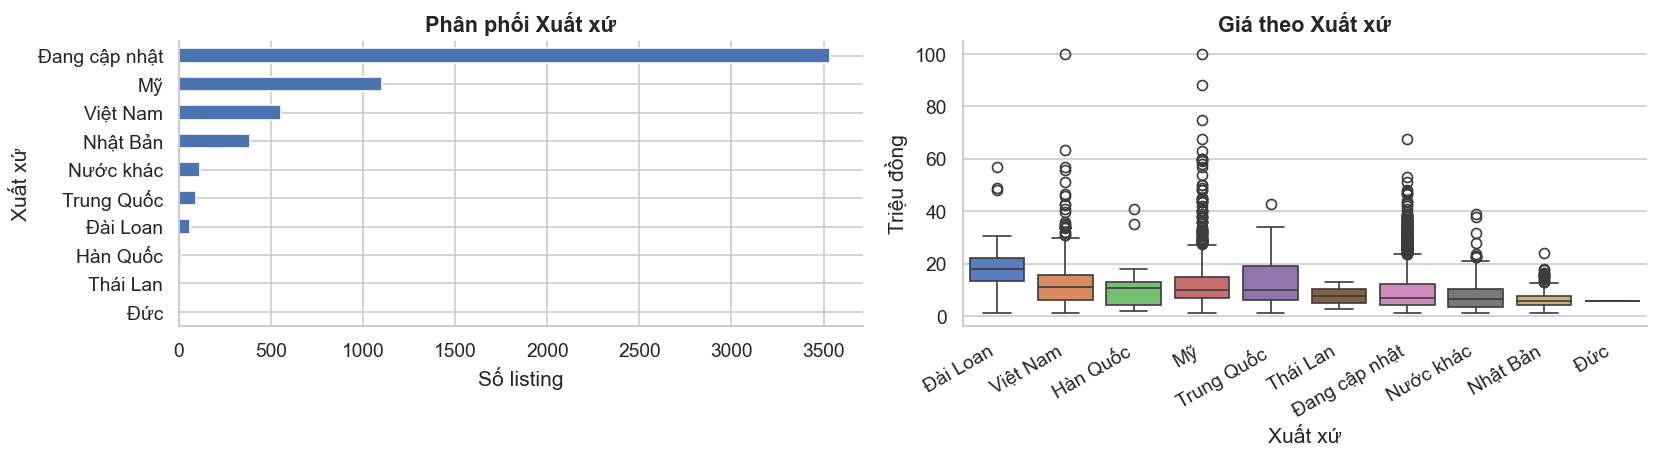

In [74]:
# ── Xuất xứ ─────────────────────────────────────────────────────────────────────
xuat_xu_vc = df['Xuất xứ'].value_counts(dropna=False)
display(xuat_xu_vc.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

xuat_xu_vc.sort_values().plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Phân phối Xuất xứ")
axes[0].set_xlabel("Số listing")

# Giá theo xuất xứ
price_xx = (df[df['_price'].between(1e6, 100e6) & df['Xuất xứ'].notna()]
            .assign(price_mil=lambda x: x['_price']/1e6))
xx_order = (price_xx.groupby('Xuất xứ')['price_mil']
            .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=price_xx, x='Xuất xứ', y='price_mil',
            order=xx_order, palette='muted', ax=axes[1])
axes[1].set_title("Giá theo Xuất xứ")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylabel("Triệu đồng")

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


In [75]:
# ── Thông tin sử dụng ───────────────────────────────────────────────────────────
print("Top 20 giá trị Thông tin sử dụng:")
display(df['Thông tin sử dụng'].value_counts(dropna=False).head(20).to_frame())

# Tiềm năng extract số năm/tháng sử dụng
year_pat  = r'(\d+)\s*(năm|year)'
month_pat = r'(\d+)\s*(tháng|month)'
has_year  = df['Thông tin sử dụng'].str.contains(year_pat,  case=False, na=False)
has_month = df['Thông tin sử dụng'].str.contains(month_pat, case=False, na=False)
print(f"\nMention năm sử dụng: {has_year.sum()} ({has_year.mean()*100:.1f}%)")
print(f"Mention tháng sử dụng: {has_month.sum()} ({has_month.mean()*100:.1f}%)")


Top 20 giá trị Thông tin sử dụng:


,count
Thông tin sử dụng,
In trên bao bì,5866



Mention năm sử dụng: 0 (0.0%)
Mention tháng sử dụng: 0 (0.0%)


## 17. Cross-column Consistency

Kiểm tra mâu thuẫn nội tại giữa các cột — phát hiện errors mà phân tích từng cột riêng không thấy được.


In [76]:
# ── Brand trong Hãng vs title ────────────────────────────────────────────────────
brand_alias = {
    'ASUS': ['asus', 'vivobook', 'zenbook', 'rog', 'tuf'],
    'Dell': ['dell', 'latitude', 'inspiron', 'xps', 'vostro'],
    'HP': ['hp', 'hewlett', 'elitebook', 'probook', 'envy', 'pavilion'],
    'Lenovo': ['lenovo', 'thinkpad', 'ideapad', 'legion', 'yoga'],
    'Acer': ['acer', 'aspire', 'swift', 'nitro', 'predator'],
    'MSI': ['msi', 'stealth', 'modern', 'prestige', 'katana'],
    'Apple': ['apple', 'macbook'],
}

def brand_in_title(row):
    brand = str(row['Hãng']).lower()
    title = str(row['title']).lower()
    aliases = brand_alias.get(row['Hãng'], [brand])
    return any(a in title for a in aliases)

match = df.apply(brand_in_title, axis=1)
no_match = ~match

print(f"Brand khớp với title: {match.sum():,} ({match.mean()*100:.1f}%)")
print(f"Không khớp: {no_match.sum():,} ({no_match.mean()*100:.1f}%)")
print("\nSample không khớp (brand vs title):")
display(df[no_match][['Hãng', 'title']].head(10))


Brand khớp với title: 5,493 (93.6%)
Không khớp: 373 (6.4%)

Sample không khớp (brand vs title):


,Hãng,title
34,Acer,5 Laptop gaming i5 8G/128G SSD BH 12-2026
37,Asus,Gaming Vivobook K3605ZU 12500H RTX 2050 BH Hãng
40,Microsoft,Surface Laptop 7 X plus 16GB ram đẹp vừa bóc tem
59,Hãng khác,Laptop Fujitsu U9311 i5/8gb/256GB
75,Hãng khác,Fujitsu i7/gen9/ram16/ssd256gb siêu bền chạy mượt
98,Hãng khác,Surface Pro 7 Plus i3-1115G4 8GB/128GB /Pin 96%
113,Hãng khác,laptop máy tính bảng Fujitsu i5 Gen 8 8GB
141,Hãng khác,eMachines i5 M520 14 inch 6GB
146,Hãng khác,Lecoo Fighter 7000: i7-13650HX | RTX 5060 | 180Hz
164,Hãng khác,Bán laptop IBM T60 Đen


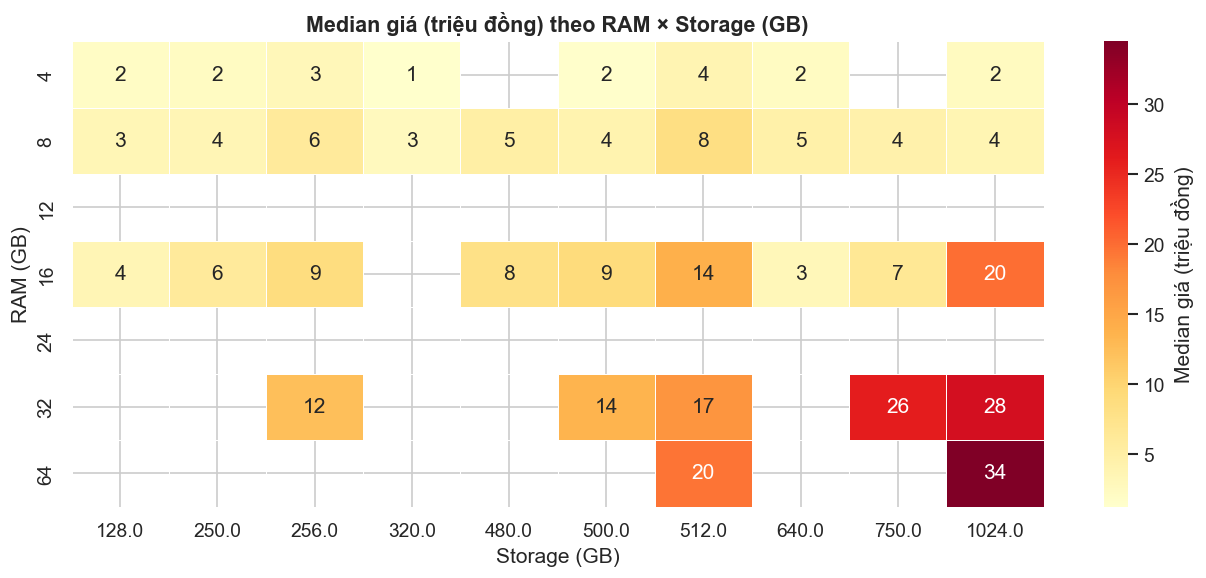

In [77]:
# ── Heatmap tương quan RAM × Storage × Giá ────────────────────────────────────────
df['ram_gb_t']  = pd.to_numeric(df['RAM'].str.extract(r'(\d+)')[0], errors='coerce')
df['stor_gb_t'] = df['Ổ cứng'].apply(parse_storage_gb)

pivot = (df[df['_price'].between(1e6, 100e6) &
            df['ram_gb_t'].notna() &
            df['stor_gb_t'].notna()]
         .assign(price_mil=lambda x: x['_price']/1e6)
         .groupby(['ram_gb_t', 'stor_gb_t'])['price_mil']
         .median()
         .unstack('stor_gb_t')
         .reindex([4, 8, 12, 16, 24, 32, 64])  # RAM rows
         )

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Median giá (triệu đồng)'})
ax.set_title("Median giá (triệu đồng) theo RAM × Storage (GB)")
ax.set_xlabel("Storage (GB)")
ax.set_ylabel("RAM (GB)")
plt.tight_layout()
plt.show()

df.drop(columns=['ram_gb_t', 'stor_gb_t'], inplace=True, errors='ignore')


In [78]:
# ── Laptop gaming thiếu GPU ────────────────────────────────────────────────────────
gaming_pat = r'(ROG|TUF|Gaming|Legion|Predator|Nitro|Katana|Raider|Titan)'
is_gaming = (df['title'].str.contains(gaming_pat, case=False, na=False) |
             df['Dòng máy'].str.contains(gaming_pat, case=False, na=False))
gaming_no_gpu = is_gaming & df['Card màn hình'].isna()

print(f"Laptop gaming (title/dòng máy) mà thiếu GPU: {gaming_no_gpu.sum()}")
if gaming_no_gpu.sum() > 0:
    display(df[gaming_no_gpu][['title', 'Dòng máy', 'Card màn hình', 'price']].head(8))


Laptop gaming (title/dòng máy) mà thiếu GPU: 24


,title,Dòng máy,Card màn hình,price
84,Laptop Dell gaming i7 6700HQ 4gb/120gb VGA 960m,Inspiron,NaN,2.900.000 đ
435,Laptop Asus TUF Gaming F15 FX506HC 15.6 inch 16GB,TUF Gaming F15,NaN,11.000.000 đ
667,Máy chơi game ROG Ally Z1 Extreme 1TB 99%,Dòng Khác,NaN,13.000.000 đ
1010,Acer Nitro 5 i5 9300h 16GB Đã dùng,Nitro 5,NaN,5.000.000 đ
1200,⚡ ACER NITRO V 15 - I7-13620H | RTX 4060,Aspire Nitro,NaN,22.200.000 đ
1458,ASUS TUF Gaming FX505GD i5-8300H 16GB,TUF Gaming,NaN,6.850.000 đ
1650,HP Victus Gaming i5-12450H 16GB/512GB,Victus,NaN,12.000.000 đ
1740,Dell G15 5530 i7 13650hx/32gb/1TB/vga4060 8GB,Gaming G15,NaN,24.000.000 đ


In [79]:
# ── Laptop 'Mới 100%' nhưng giá < 3 triệu ────────────────────────────────────────
new_cheap = df[
    df['Tình trạng'].str.contains('Mới', na=False, case=False) &
    (df['_price'] < 3_000_000)
]
print(f"Laptop 'Mới' giá < 3 triệu: {len(new_cheap)}")
if len(new_cheap) > 0:
    display(new_cheap[['title', 'Tình trạng', 'price', 'Hãng']].head(10))


Laptop 'Mới' giá < 3 triệu: 7


,title,Tình trạng,price,Hãng
26,"HP 15-da0056TU i3 8130U, 4GB, SSD 128GB, 15.6"" HD",Mới,2.300.000 đ,HP
766,Dell Latitude E7250 pin 4h,Mới,1.700.000 đ,Dell
1667,LAPTOP DELL I5 - MỚI 100% - GÓP NHANH,Mới,2.300.000 đ,Dell
3076,"Dell Vostro 3468 Core i3-6006U, RAM 4GB, SSD 120GB",Mới,1.800.000 đ,Dell
3298,Asus i3-8145U 8GB/256GB 14 inch fullhd,Mới,2.600.000 đ,Asus
3565,"Dell Inspiron 3467 Core i3-7020U, 4GB, SSD 128GB",Mới,1.900.000 đ,Dell
4695,Bán Macbook 12inch 2015 Ram 8G/512G màu Gold,Mới,2.450.000 đ,Apple


In [80]:
# ── Ổ cứng inconsistency chi tiết ────────────────────────────────────────────────
case_a = df['Loại ổ cứng'].notna() & df['Ổ cứng'].isna()
case_b = df['Loại ổ cứng'].isna()  & df['Ổ cứng'].notna()
print(f"Có Loại nhưng không có Dung lượng: {case_a.sum()}")
print(f"Có Dung lượng nhưng không có Loại:  {case_b.sum()}")
if case_a.sum() > 0:
    print("\nSample case A:")
    display(df[case_a][['Loại ổ cứng', 'Ổ cứng', 'title']].head(5))
if case_b.sum() > 0:
    print("\nSample case B:")
    display(df[case_b][['Loại ổ cứng', 'Ổ cứng', 'title']].head(5))


Có Loại nhưng không có Dung lượng: 128
Có Dung lượng nhưng không có Loại:  384

Sample case A:


,Loại ổ cứng,Ổ cứng,title
113,SSD,NaN,laptop máy tính bảng Fujitsu i5 Gen 8 8GB
159,SSD,NaN,HP ProBook 4430s i7 6GB SSD Xám
164,HDD,NaN,Bán laptop IBM T60 Đen
199,SSD,NaN,Bán MacBook Pro i5 16GB/SSD Xám tại Hà Đông
204,SSD,NaN,Dell Latitude E6430 i5-3320M 4GB/400GB



Sample case B:


,Loại ổ cứng,Ổ cứng,title
33,NaN,256 GB,MacBook Air M4 13.3 inch (16GB/256GB ) bh 9/2026
39,NaN,256 GB,Dell Inspiron 5480 i5-8265U 16GB/256GB
66,NaN,500 GB,HP ZBook Fury 16 G9 i7-12850HX 16 inch 16GB/500GB
67,NaN,256 GB,Microsoft Surface Laptop 4 i7 15 inch 16GB/256GB
97,NaN,128 GB,"Lenovo ThinkPad X230 Hỏng pin, kênh bàn phím"


## 18. Issues Summary

Tổng hợp các vấn đề được xác nhận bằng số liệu — làm input cho `02a_chotot_cleaning.ipynb`.


In [81]:
# Tính lại số liệu thực tế để fill vào issues
_pv   = df['_price']                     # _price vẫn còn trên df
n_pf  = _pv.isna().sum()
n_plo = (_pv < 1_000_000).sum()
n_phi = (_pv > 150_000_000).sum()

# FIX: tính sẵn biến, tránh f-string lồng phức tạp
cpu_pct = (df['title'].str.contains(r'(i\d[-\s]?\d{4,5}|Ryzen|M[123])',
           case=False, na=False).mean() * 100)
rare_brand_count = (df['Hãng'].value_counts() < 10).sum()
tinhtrang_anomaly = (df['Tình trạng'].str.contains('Mới', na=False) & (_pv < 3e6)).sum()
stor_inconsist = (df['Loại ổ cứng'].isna() & df['Ổ cứng'].notna()).sum()

issues = pd.DataFrame([
    # Prices
    (
     'price',
     'Giá có phân phối lệch mạnh (right-skewed), tập trung ở phân khúc thấp-trung và có một số outlier giá rất cao; có khả năng tồn tại nhiễu do listing lỗi, spam hoặc sản phẩm đặc biệt',
     'Áp dụng log transform khi modeling; kiểm tra và xử lý outlier (capping hoặc filtering); không dùng mean để mô tả'
    ),
    (
     'price_outliers',
     'Tồn tại các giá trị bất thường (quá thấp hoặc quá cao) có thể do lỗi nhập liệu, spam hoặc sản phẩm không cùng phân khúc hoặc rác dựa trên title',
     'Dùng IQR hoặc percentile để detect; xử lý bằng clipping hoặc loại bỏ tùy use case'
    ),
    (
     'price_market_bias',
     'Giá phản ánh thị trường Việt Nam (second-hand, xách tay, thanh lý), không đại diện cho giá retail chính hãng toàn cầu',
     'Không suy rộng kết luận ra thị trường quốc tế; model chỉ phù hợp với bối cảnh local'
    ),

    # Title
    (
     'title',
     'Text tự do, giàu thông tin nhưng không đồng đều; ~91% có brand, ~58% có RAM, ~50% có storage, ~45% có CPU; tuy nhiên chỉ ~12–14% dòng missing có thể recover từ title → thông tin phân bố lệch và mang tính semi-structured',
     'Giữ làm metadata; extract feature có kiểm soát (RAM/Storage/CPU); chỉ dùng để fill missing khi cần, không overwrite structured; xử lý bằng rule-based parsing, tránh regex đơn giản'
    ),
    (
     'title_parsing',
     'Có ambiguity cao khi extract, đặc biệt RAM vs Storage (512GB, 256GB) và GPU VRAM; nhiều pattern dạng 16GB/512GB hoặc text không chuẩn → dễ false positive',
     'Dùng parsing có ngữ cảnh (RAM keyword + valid values); ưu tiên pattern rõ ràng; validate trước khi dùng'
    ),
    (
     'title_recovery',
     'Khả năng fill missing thấp: CPU ~12%, RAM ~13%, Storage ~6% → title không phải nguồn chính để xử lý missing (missing not at random)',
     'Chỉ dùng title như fallback; kết hợp imputation hoặc rule theo nhóm'
    ),
    (
     'title_consistency',
     'Có conflict đáng kể với structured columns (RAM ~188 rows, Storage ~96 rows) → text không đáng tin tuyệt đối',
     'Không dùng title để overwrite dữ liệu có sẵn; chỉ dùng khi structured bị thiếu'
    ),
    (
     'title_structure',
     'Khoảng ~10% title có pattern dạng "X/Y" (8/256, 16/512) → dữ liệu mang tính semi-structured',
     'Khai thác bằng parser riêng để tách RAM/Storage thay vì regex đơn giản'
    ),
    (
     'title_cpu_coverage',
     'Regex CPU chưa cover hết pattern (Core2 Duo, N-series, Intel/AMD generic) → miss một phần dữ liệu',
     'Chấp nhận coverage không hoàn toàn; không rely 100% vào title cho CPU feature'
    ),

    # Brand
    (
     'brand_price_segment',
     'Phân bố giá theo brand không đồng đều; một số brand tập trung ở high/premium (MSI, Razer), trong khi brand khác chủ yếu ở low/mid (Dell, Acer); tuy nhiên các brand nhỏ (Honor, Xiaomi) có phân bố không ổn định do sample ít',
     'Giữ brand làm feature chính; có thể tạo thêm feature segment (low/mid/high/premium); không rely vào distribution của brand nhỏ'
    ),
    (
     'brand_sample_bias',
     'Một số brand có số lượng listing rất thấp nhưng lại có tỷ lệ premium cao bất thường (ví dụ Honor), gây hiểu sai về positioning',
     'Gộp brand tần suất thấp vào "Other" khi modeling; chỉ phân tích sâu các brand có đủ dữ liệu'
    ),
    (
     'price_segment_skew',
     'Phân bố giá theo brand bị lệch và không đồng đều giữa các phân khúc; nhiều brand có sự pha trộn giữa mid và high thay vì phân tách rõ ràng',
     'Không sử dụng hard rule để map brand → segment; để model tự học kết hợp với các feature khác (RAM, CPU, storage)'
    ),
    (
     'brand_as_proxy',
     'Brand đóng vai trò proxy cho phân khúc giá và positioning sản phẩm, nhưng không phản ánh hoàn toàn do còn phụ thuộc vào cấu hình và tình trạng',
     'Giữ brand trong model; kết hợp với spec features để tránh over-reliance vào brand'
    ),


    ('Dòng máy',
     f'{df["Dòng máy"].nunique()} distinct; nhiều variant không nhất quán',
     'Chuẩn hóa; drop nếu quá sparse sau cleaning'),
    ('Tình trạng',
     f'{df["Tình trạng"].nunique()} categories; {tinhtrang_anomaly} anomaly "Mới" giá < 3M',
     'Map → {Mới, Đã dùng, Đã sửa chữa}; flag anomaly'),
    ('Chính sách bảo hành',
     f'{df["Chính sách bảo hành"].nunique()} categories; cần encode số tháng',
     'Map → ước tính tháng; 0=Không bảo hành'),
    ('Kích cỡ màn hình',
     f'Missing {df["Kích cỡ màn hình"].isna().sum()} ({df["Kích cỡ màn hình"].isna().mean()*100:.1f}%); dạng range text',
     'Extract midpoint inch; impute median / từ title'),
    ('Bộ vi xử lý',
     f'Missing {df["Bộ vi xử lý"].isna().sum()} ({df["Bộ vi xử lý"].isna().mean()*100:.1f}%); text tự do; nhiều variant',
     'Extract brand / tier / gen Intel; standardize'),
    ('RAM',
     f'Missing {df["RAM"].isna().sum()} ({df["RAM"].isna().mean()*100:.1f}%); text "X GB"; có thể có outlier',
     'Extract số GB; validate [4, 128]'),
    ('Card màn hình',
     f'Missing {df["Card màn hình"].isna().sum()} ({df["Card màn hình"].isna().mean()*100:.1f}%) — '
     f'nhiều khả năng integrated; gaming laptop thiếu GPU nghi vấn',
     'Phân loại: Dedicated / Integrated / Missing'),
    ('Ổ cứng',
     f'Missing {df["Ổ cứng"].isna().sum()} ({df["Ổ cứng"].isna().mean()*100:.1f}%); mix GB/TB',
     'Convert về GB'),
    ('Loại ổ cứng',
     f'Missing {df["Loại ổ cứng"].isna().sum()} ({df["Loại ổ cứng"].isna().mean()*100:.1f}%); '
     f'inconsistency với Ổ cứng: {stor_inconsist} dòng',
     'Chuẩn hóa SSD/HDD/eMMC; fill từ Ổ cứng nếu có thể'),
    ('Xuất xứ',
     f'{df["Xuất xứ"].nunique()} distinct; missing {df["Xuất xứ"].isna().sum()}',
     'Giữ hoặc drop tùy correlation với giá'),
    ('Thông tin sử dụng',
     f'Text tự do; ít structured; missing {df["Thông tin sử dụng"].isna().sum()}',
     'Giữ làm metadata; ít dùng làm feature'),
    ('url',
     'Identifier duy nhất; không missing',
     'Giữ để dedup; không dùng làm feature'),
], columns=['Column', 'Issue (với số liệu)', 'Proposed Action'])

display(issues)

,Column,Issue (với số liệu),Proposed Action
0,price,"String format ""X.XXX.XXX đ""; parse thất bại: 1 dòng; có ""Thỏa thuận""",Parse → int64; drop không parse được
1,price,"Outlier: 159 dòng < 1M, 0 dòng > 150M",Filter: giữ 1M–150M hoặc ngưỡng IQR
2,title,"Text tự do; ~51% title có CPU pattern, tiềm năng fill spec missing",Giữ làm metadata; regex fill spec missing
3,Hãng,4 brand < 10 listing; tên có thể không chuẩn,"Chuẩn hóa tên; group rare → ""Khác"""
4,Dòng máy,458 distinct; nhiều variant không nhất quán,Chuẩn hóa; drop nếu quá sparse sau cleaning
5,Tình trạng,"3 categories; 7 anomaly ""Mới"" giá < 3M","Map → {Mới, Đã dùng, Đã sửa chữa}; flag anomaly"
6,Chính sách bảo hành,9 categories; cần encode số tháng,Map → ước tính tháng; 0=Không bảo hành
7,Kích cỡ màn hình,Missing 1037 (17.7%); dạng range text,Extract midpoint inch; impute median / từ title
8,Bộ vi xử lý,Missing 249 (4.2%); text tự do; nhiều variant,Extract brand / tier / gen Intel; standardize
9,RAM,"Missing 239 (4.1%); text ""X GB""; có thể có outlier","Extract số GB; validate [4, 128]"


In [82]:
# ── Save + final cleanup ────────────────────────────────────────────────────────
issues.to_csv('../../docs/chotot_issues_list.csv', index=False, encoding='utf-8-sig')
print("Saved: docs/chotot_issues_list.csv")

Saved: docs/chotot_issues_list.csv
